# Metano y cobertura de la tierra en Colombia

Datos de XCH₄ de Copernicus Sentinel-5P TROPOMI cruzados con la cobertura de la tierra
del IDEAM/IGAC (leyenda CORINE adaptada, 6 niveles jerárquicos).

## Estado de las secciones

| # | Sección | Estado |
|---|---|---|
| 1 | Alistamiento: cruce CH₄ × cobertura | ✅ vigente, corre completo |
| 1.2 | Panel bienal multi-año | ✅ vigente, corre completo |
| 2 | Máscara de calidad | ✅ vigente, corre completo |
| 3 | Análisis transversal (nivel 3) | ✅ vigente, corre completo |
| 4 | Inferencia causal por cambio | ✅ vigente, corre completo |
| 5 | Clusters | ⚠️ heredado, sin verificar |
| 6 | Clasificación (red neuronal) | ⚠️ heredado, sin verificar |
| 7 | Series de tiempo | ⚠️ heredado, rutas de Colab |
| 8 | Detección de anomalías | ⚠️ heredado, sin verificar |
| 9 | Suplemental | ⛔ histórico, no correr |

Las secciones 1–4 son el flujo vigente. De la 5 en
adelante es trabajo heredado en distinto grado de madurez: no se ha revisado y puede
depender de estado producido por ejecuciones anteriores.

## Dos ramas, dos preguntas

`process_all_years()` alimenta dos productos distintos, y conviene no confundirlos:

| | 3 transversal | 4 causal |
|---|---|---|
| insumo | `colombia_corr_metano_2022_2023_...` | `panel_bienal_cobertura_multianual.csv` |
| cobertura | **una** capa (2022) para los dos años | **su propia** capa por periodo |
| CH₄ | media anual simple | media bienal con meses equiponderados |
| compara | píxeles distintos entre sí | el mismo píxel consigo mismo en el tiempo |
| identifica | asociación en el espacio | efecto del cambio |
| confusores | todo lo que varíe en el espacio | solo lo que cambie en el tiempo |

## Flujo de datos

```
CH4_glintfiltered_colombia_2019-2026.csv        cobertura <año>.gpkg / .shp
    (12 M sondeos con fecha, SIN filtrar)         (polígonos IDEAM/IGAC, 4 periodos)
         │                                                     │
         ├── media anual simple ──► colombia_prom_<año>.csv    │
         │                                │                    │
         └── §1.2 media bienal ──► ch4_bienal_<periodo>.csv    │
             (meses equiponderados)       │                    │
                                          └─────────┬──────────┘
                                                    ▼
                                        process_all_years()      ← cacheado en .pkl
                              fracción de área de cada clase por píxel de 0.01°
                                          ┌─────────┴─────────┐
                                          ▼                   ▼
                     colombia_corr_metano_        panel_bienal_cobertura_
                     2022_2023_cobertura_2022      multianual.csv
                     831,455 × 168                 4 periodos × 166 clases
                                          │                   │
                                          ▼                   ▼
                              construir_mascara()   construir_mascara()
                          mascara_calidad_...csv   mascara_calidad_panel_...csv
                                          │                   │
                                          ▼                   ▼
                                    §3 transversal        §4 causal
```

## Convenciones

- **Consumir la máscara siempre por función** (`aplicar_mascara` / `cargar_mascara`),
  nunca leyendo la ruta a mano. Ver el contrato en §2. Cada rama tiene su propia máscara,
  que se pasa por el argumento `ruta=`.
- **Las columnas dummy las fija el CATÁLOGO, no la capa.** `get_encoded` usa categorías
  canónicas (166 columnas), así que los cuatro periodos son directamente comparables. Sin
  eso, `pd.get_dummies` emite solo las clases presentes en cada capa y el panel se alinea
  con NaN en silencio.
- **Un solo nivel de leyenda por modelo.** Los seis niveles están anidados, así que
  mezclarlos da colinealidad perfecta por construcción.
- **Composición ⇒ referencia.** Las fracciones de un nivel suman 1, luego con intercepto
  son singulares. §3 y §4 sueltan la misma `CLASE_REFERENCIA` y reportan efectos frente
  a ella, por +10 puntos porcentuales.
- El cruce espacial está cacheado por periodo: si el `.pkl` cubre las coordenadas pedidas,
  `process_all_years` no vuelve a intersectar.

Ver también `knowledge/glint_y_calidad_del_dato.md` para el criterio de la máscara, la
discusión de glint sobre zonas inundadas y el efecto del muestreo temporal.


In [2]:
# !pip install gstools
# !pip install georasters
# # !pip install geemap
# !pip install pingouin
# !pip install contextily
# !pip install geopandas
# # !pip install polars
# !pip install cartopy
# !pip install seaborn
#!pip install translate
#!pip install -U deep-translator
#from deep_translator import DeeplTranslator#ChatGptTranslator,
#!pip install deepl
#import deepl
#from translate import Translator
#from googletrans import Translator
# Initialize the translator
#translator= Translator(provider='microsoft',to_lang='en')

import io
import sys
from contextlib import redirect_stdout
#import contextily as cx
import os
os.environ['USE_PYGEOS'] = '0'

In [1]:
#!pip install numpy==2.4.0
#!pip install statsmodels
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import gc
import geopandas as gpd
import pandas as pd
import numpy as np
#import gstools as gs
import matplotlib.pyplot as plt
# import ee
# import geemap
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
import shapely
from shapely import prepare, box as shapely_box
from shapely.geometry import box
#import tensorflow as tf
#from tensorflow import keras
#from tensorflow.keras import layers
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
#import pingouin as pg
#import polars as pl
from pathlib import Path
#from google.colab import drive
#drive.mount('/content/drive')
#ee.Authenticate()
#ee.Initialize(project='ee-jolejua')

# 1. Alistamiento: cruce CH4 × cobertura de la tierra

Se corre cuando se tiene una nueva base de datos para alistar el archivo, sólo se debe hacer una vez, y dicho archivo queda guardado, mostrandose en el siguiente bloque.

Los cuatro archivos usan CRS EPSG:4686


In [4]:
# Declaración ÚNICA de dónde vive cada capa de cobertura del IGAC. Todo lo que
# necesite una capa (regeneración de áreas, panel bienal de §1.2) lee de aquí.
CAPAS_COBERTURA = {
    2018: dict(ruta="Cobertura_de_la_Tierra_100K_Periodo_2018/COBERTURAS CORINE 2018/"
                    "shape coberturas 2018/cobertura_tierra_clc_2018.shp",
               layer=None),   # única capa sin area_ha -> se calcula en EPSG:9377
    2020: dict(ruta="Cobertura_de_la_tierra_100K_Periodo_2020_limite_administrativo/"
                    "shape Limite admin/e_cobertura_tierra_2020_admin.shp",
               layer=None),
    2022: dict(ruta="Cobertura_tierra_100K_periodo_2022_limite_administrativo/"
                    "Cobertura_tierra_100K_periodo_2022_limite_administrativo/"
                    "ECOSISTEMAS_18062025/ECOSISTEMAS_18062025.gpkg",
               layer="e_cobertura_tierra_2022_admin"),
    2024: dict(ruta="Cobertura_Tierra_100K_Periodo_2024_limite_administrativo/"
                    "ECOSISTEMAS_COBERTURAS_DE_LA_TIERRA_2024_24042026.gpkg",
               layer="e_cobertura_tierra_2024_Admin"),
}

# Solo se usan nivel_1..6 (leyenda), area_ha (áreas nativas del IGAC) y la geometría.
# Leer también codigo/leyenda/insumo/apoyo/confiabili/cambio los arrastra por los tres
# .copy() de normalizar_coberturas -> get_encoded -> _prepare_landcover_gdf, y era el
# grueso del pico de ~11 GB. Verificado: la lista de columnas Leyenda_* resultante es
# idéntica y en el mismo orden, así que el caché de cobertura sigue siendo válido.
NIVELES_COBERTURA = [f'nivel_{i}' for i in range(1, 7)]
COLUMNAS_COBERTURA = NIVELES_COBERTURA + ['area_ha']

# La capa 2022 es el CATÁLOGO CANÓNICO del proyecto: de ella salen los diccionarios
# código -> etiqueta con los que se normalizan las demás (celda de diccionarios).
dfg_2022 = gpd.read_file(
    CAPAS_COBERTURA[2022]["ruta"],
    layer=CAPAS_COBERTURA[2022]["layer"],
    columns=COLUMNAS_COBERTURA,
)
print(f'cobertura 2022: {len(dfg_2022):,} polígonos | crs={dfg_2022.crs}')


cobertura 2022: 521,162 polígonos | crs=EPSG:4686


In [ ]:
# El IGAC calcula su columna `area_ha` en EPSG:9377 (MAGNA-SIRGAS 2018 /
# Origen-Nacional). Verificado sobre muestras aleatorias de las capas 2020 y 2022:
# el área calculada en 9377 reproduce `area_ha` con sesgo +0.0000 % en p50, p95 y
# agregado. Por eso solo se calcula cuando la capa no trae la columna (caso 2018).
#
# No usar EPSG:3116 (Bogota zone): su área de uso oficial es -75.59..-72.58, deja
# fuera el 53 % del país y sesga el área +0.24 % en agregado, hasta +1.5 % en la
# Amazonía y la Orinoquía.
AREA_CRS_IGAC = "EPSG:9377"


def get_areas(dfg, area_crs=AREA_CRS_IGAC):
    """Garantiza las columnas `area_ha` y `area_m2` usando la convención del IGAC.

    Si la capa ya trae `area_ha` (2020, 2022, 2024) se respeta tal cual y solo se
    deriva `area_m2`. Si no la trae (2018) se calcula proyectando a `area_crs`.
    No modifica el CRS ni la geometría original.
    """
    resultado = dfg.copy()

    if "area_ha" in resultado.columns:
        resultado["area_ha"] = pd.to_numeric(resultado["area_ha"], errors="raise")
        resultado["area_m2"] = resultado["area_ha"] * 10_000
        resultado.attrs["area_origen"] = "IGAC (columna nativa)"
    else:
        if resultado.crs is None:
            raise ValueError("La capa no tiene CRS definido; no se puede proyectar.")
        resultado["area_m2"] = resultado.geometry.to_crs(area_crs).area
        resultado["area_ha"] = resultado["area_m2"] / 10_000
        resultado.attrs["area_origen"] = f"calculada en {area_crs}"

    print(f"  áreas: {resultado.attrs['area_origen']}")
    return resultado


dfg_2022 = get_areas(dfg_2022)


Cálculo de áreas por nivel de cobertura.

`get_areas()` respeta la columna `area_ha` del IGAC cuando existe (2020, 2022,
2024) y solo la calcula cuando falta (2018), proyectando a **EPSG:9377**
(Origen-Nacional), que es la convención con la que el propio IGAC produce esa
columna.

No usar EPSG:3116: su zona de uso oficial es -75.59°..-72.58° y deja fuera el
53 % del país, con sesgos de área de hasta +1.5 % en Amazonía y Orinoquía.

La celda de regeneración produce los tres años con el mismo método, así que las
áreas son comparables entre sí. Correr una sola vez; después basta leer los CSV.


In [ ]:
def resumen_areas(dfg, niveles=range(1, 7)):
    """Agrega el área por cada nivel de la leyenda CORINE."""
    columnas_area = [c for c in ("area_m2", "area_ha") if c in dfg.columns]
    if not columnas_area:
        raise KeyError("La capa no tiene columnas de área; correr get_areas() antes.")

    resultados = []
    for i in niveles:
        columna = f"nivel_{i}"
        virt = (
            dfg
            .groupby(columna, dropna=False)[columnas_area]
            .sum()
            .reset_index()
            .rename(columns={columna: "Leyenda"})
        )
        virt["Nivel"] = i
        resultados.append(virt)

    return pd.concat(resultados, ignore_index=True)


In [ ]:
import re

# NIVELES_COBERTURA se declara junto a CAPAS_COBERTURA, más arriba.


def extraer_codigo_cobertura(etiqueta):
    """Extrae 3112 de una etiqueta como '3.1.1.2. Bosque denso bajo'."""
    coincidencia = re.match(r'^[0-9.]+', etiqueta)
    if coincidencia is None:
        raise ValueError(f'Etiqueta de cobertura sin código jerárquico: {etiqueta!r}')
    return coincidencia.group().replace('.', '')


def crear_diccionarios_canonicos(dfg_canonico):
    """Crea un diccionario código -> etiqueta para cada nivel, ignorando nulos."""
    diccionarios = {}
    for columna in NIVELES_COBERTURA:
        etiquetas = dfg_canonico[columna].dropna().astype('string').unique()
        diccionarios[columna] = {
            extraer_codigo_cobertura(etiqueta): etiqueta
            for etiqueta in etiquetas
        }

    # Clases que existen en alguna capa histórica pero NO en la canónica 2022.
    # Sin ellas, esa capa emite una columna dummy que las demás no tienen y el
    # panel multi-año se alinea con NaN en silencio. Verificado sobre las cuatro
    # capas (2018/2020/2022/2024): estas dos son las ÚNICAS discrepancias, y el
    # texto de la etiqueta es idéntico entre años para todos los demás códigos.
    diccionarios['nivel_4']['2215'] = '2.2.1.5. Papaya'            # solo en 2020
    diccionarios['nivel_6']['311122'] = '3.1.1.1.2.2. Manglar denso alto'  # solo en 2018
    return diccionarios


# La capa 2022 se usa como catálogo canónico para este procesamiento.
diccionarios_cobertura = crear_diccionarios_canonicos(dfg_2022)
mydict1 = diccionarios_cobertura['nivel_1']
mydict2 = diccionarios_cobertura['nivel_2']
mydict3 = diccionarios_cobertura['nivel_3']
mydict4 = diccionarios_cobertura['nivel_4']
mydict5 = diccionarios_cobertura['nivel_5']
mydict6 = diccionarios_cobertura['nivel_6']
{nivel: len(diccionario) for nivel, diccionario in diccionarios_cobertura.items()}


In [7]:
def normalizar_coberturas(dfg, diccionarios=diccionarios_cobertura):
    """Traduce códigos y conserva etiquetas ya normalizadas y valores nulos."""
    resultado = dfg.copy()

    for columna, diccionario in diccionarios.items():
        serie = resultado[columna].astype('string').str.strip()
        es_codigo = serie.str.fullmatch(r'\d+', na=False)
        codigos_desconocidos = sorted(
            serie.loc[es_codigo & ~serie.isin(diccionario)].dropna().unique()
        )

        if codigos_desconocidos:
            raise ValueError(
                f'{columna}: códigos sin correspondencia: {codigos_desconocidos}'
            )

        resultado.loc[es_codigo, columna] = serie.loc[es_codigo].map(diccionario)

    return resultado


In [8]:
# La función es segura para todos los años: solo transforma códigos numéricos.
# Las variables que no estén cargadas en la sesión simplemente se omiten.
coberturas_normalizadas = {}
for anio, nombre_variable in {
    2018: 'dfg_2018',
    2020: 'dfg_2020',
    2022: 'dfg_2022',
    2024: 'dfg_2024',
}.items():
    if nombre_variable in globals():
        coberturas_normalizadas[anio] = normalizar_coberturas(globals()[nombre_variable])

if 2018 in coberturas_normalizadas:
    dfg_2018 = coberturas_normalizadas[2018]
if 2020 in coberturas_normalizadas:
    dfg_2020 = coberturas_normalizadas[2020]
if 2022 in coberturas_normalizadas:
    dfg_2022 = coberturas_normalizadas[2022]
if 2024 in coberturas_normalizadas:
    dfg_2024 = coberturas_normalizadas[2024]

print(f'Años normalizados: {sorted(coberturas_normalizadas)}')


Años normalizados: [2022]


In [9]:
# Regenera areas_YYYY.csv para los tres años con método idéntico, para que las
# áreas sean comparables entre sí. Correr una sola vez; después basta leer los CSV.
# Va aquí porque reutiliza normalizar_coberturas(): la capa 2020 guarda códigos
# ('1', '111') en vez de etiquetas y hay que traducirlos con el catálogo canónico.
DIR_AREAS = Path("output")

DIR_AREAS.mkdir(parents=True, exist_ok=True)
for anio, cfg in CAPAS_COBERTURA.items():
    print(f"{anio}: {Path(cfg['ruta']).name}")

    # Solo 2018 necesita geometría: es el único sin area_ha, y hay que proyectarla.
    # Para los demás bastan los atributos, lo que evita cargar cientos de miles de
    # polígonos en memoria (~12 GB de pico si se leen todos con geometría).
    necesita_geometria = anio == 2018
    columnas = NIVELES_COBERTURA + ([] if necesita_geometria else ["area_ha"])
    capa = gpd.read_file(cfg["ruta"], layer=cfg["layer"], columns=columnas,
                         ignore_geometry=not necesita_geometria)

    # normalizar_coberturas() decide valor por valor si es código o etiqueta,
    # así que es segura para cualquier año y lanza error ante códigos desconocidos.
    capa = get_areas(normalizar_coberturas(capa))

    resumen = resumen_areas(capa)
    resumen.to_csv(DIR_AREAS / f"areas_{anio}.csv", index=False)
    print(f"  -> areas_{anio}.csv "
          f"({resumen.loc[resumen['Nivel'] == 1, 'area_ha'].sum():,.0f} ha)")

    del capa
    gc.collect()


2018: cobertura_tierra_clc_2018.shp
  áreas: calculada en EPSG:9377
  -> areas_2018.csv (113,897,502 ha)
2020: e_cobertura_tierra_2020_admin.shp
  áreas: IGAC (columna nativa)
  -> areas_2020.csv (113,661,614 ha)
2022: ECOSISTEMAS_18062025.gpkg
  áreas: IGAC (columna nativa)
  -> areas_2022.csv (113,661,615 ha)


-------- Fin del bloque de alistamiento de coberturas ------------

Ya no hay código específico de 2020. `normalizar_coberturas()` decide valor por
valor si encuentra un código o una etiqueta, y `get_areas()` respeta el `area_ha`
del IGAC cuando existe. Todo este bloque corre igual para 2018, 2020, 2022 y 2024.


## 1.1 Resumen de lo hecho hasta aquí

1. Carga de la cobertura de tierra 2022 y normalización de códigos a etiquetas.
2. Áreas agregadas por nivel (`output/areas_YYYY.csv`) con la convención del IGAC.

Lo que sigue: codificación one-hot de los seis niveles y cruce espacial contra los
píxeles de CH4.

> La exclusión de agua **no** se hace aquí, sino más adelante sobre las *fracciones
> por píxel* que produce el cruce espacial (bloque "Máscara de calidad"). Antes
> existía aquí un `dfg_2022_agua_humedales` que materializaba los polígonos de
> agua/humedal; no lo usaba ninguna celda y se eliminó.

In [ ]:
# El catálogo canónico —no la capa— decide las columnas dummy.
#
# Antes: pd.get_dummies() sobre dtype object solo emite columnas para los
# valores PRESENTES en esa capa. Con cuatro años de cobertura eso da cuatro
# esquemas distintos (2018 no tiene '5.2.2. Mares y océanos', 2020 sí tiene
# '2.2.1.5. Papaya', 2018 sí tiene '3.1.1.1.2.2. Manglar denso alto'...) y el
# pd.concat del panel los alinea con NaN sin avisar.
#
# Ahora cada nivel se declara como Categorical con las categorías del catálogo,
# así que las cuatro capas emiten LAS MISMAS 166 columnas en el MISMO orden,
# con ceros donde la clase no aparece. El caché de cobertura depende de ese
# orden (ver _cache_metadata).
NIVELES_CODIFICACION = ['Leyenda_3', 'Leyenda_1', 'Leyenda_4',
                        'Leyenda_2', 'Leyenda_5', 'Leyenda_6']


def categorias_canonicas(catalogo=None):
    """Categorías por nivel, en el orden en que get_dummies emitiría las columnas."""
    catalogo = diccionarios_cobertura if catalogo is None else catalogo
    return {
        f'Leyenda_{nivel}': sorted(set(catalogo[f'nivel_{nivel}'].values()))
        for nivel in range(1, 7)
    }


def get_encoded(dfg, catalogo=None):
    """Codifica como variables dummy los seis niveles de cobertura.

    Las columnas resultantes las fija el CATÁLOGO, no los valores presentes en
    `dfg`: eso es lo que hace comparables entre sí las capas de distintos años.
    """
    resultado = dfg.copy()
    categorias = categorias_canonicas(catalogo)

    for nivel in range(1, 7):
        columna = f'Leyenda_{nivel}'
        valores = resultado[f'nivel_{nivel}'].astype('object')
        fuera = set(valores.dropna().unique()).difference(categorias[columna])
        if fuera:
            raise ValueError(
                f'{columna}: clases fuera del catálogo canónico: {sorted(fuera)}. '
                'Añádelas en crear_diccionarios_canonicos().'
            )
        resultado[columna] = pd.Categorical(valores, categories=categorias[columna])

    # El orden conserva primero nivel 3, como espera el flujo posterior.
    return pd.get_dummies(resultado, columns=NIVELES_CODIFICACION)


In [13]:
encoded_df_2022=get_encoded(dfg_2022)

In [6]:
directorio_datos = Path(
  "/home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026"
)

df_s_2022 = pd.read_csv(directorio_datos / "colombia_prom_2022.csv")
df_s_2023 = pd.read_csv(directorio_datos / "colombia_prom_2023.csv")

In [4]:
import itertools
import os
import warnings
from concurrent.futures import ThreadPoolExecutor

COORDINATE_CRS = "EPSG:4686"
# Sin CRS de área: la fracción intersección/píxel es adimensional, así que el
# factor de distorsión de cualquier proyección se cancela entre numerador y
# denominador. Trabajar en grados es de hecho MÁS exacto que proyectar
# (error 1.9e-07 % vs 1.0e-03 % contra el área geodésica, porque reproyectar
# convierte los arcos de los bordes en cuerdas) y evita reproyectar ~521k
# polígonos en cada corrida (~78 s).
# Las áreas absolutas en m²/ha se calculan aparte, en get_areas().
# Las áreas se acumulan en float64; solo las fracciones finales se almacenan en float32.
FRACTION_DTYPE = np.float32
LANDCOVER_PREFIXES = tuple(f"Leyenda_{nivel}_" for nivel in range(1, 7))


def get_landcover_columns(encoded_df):
    """Devuelve únicamente las columnas dummy de los niveles 1 a 6."""
    columnas = [
        columna
        for columna in encoded_df.columns
        if columna.startswith(LANDCOVER_PREFIXES)
    ]
    if not columnas:
        raise ValueError("No se encontraron columnas dummy de cobertura 'Leyenda_<nivel>_...'.")
    return columnas


def build_pixel_geometries(df, delta=0.01 / 2, crs=COORDINATE_CRS):
    """Construye el cuadro de cada píxel a partir de su centro geográfico."""
    columnas_requeridas = {"longitude", "latitude"}
    faltantes = columnas_requeridas.difference(df.columns)
    if faltantes:
        raise KeyError(f"Faltan columnas de coordenadas: {sorted(faltantes)}")
    if delta <= 0:
        raise ValueError("delta debe ser mayor que cero.")

    resultado = df.reset_index(drop=True).copy()
    coordenadas = resultado[["longitude", "latitude"]].apply(
        pd.to_numeric, errors="coerce"
    )
    filas_invalidas = coordenadas.isna().any(axis=1)
    if filas_invalidas.any():
        raise ValueError(
            f"Hay {int(filas_invalidas.sum())} filas con coordenadas nulas o no numéricas."
        )

    resultado[["longitude", "latitude"]] = coordenadas
    geometria = shapely_box(
        coordenadas["longitude"] - delta,
        coordenadas["latitude"] - delta,
        coordenadas["longitude"] + delta,
        coordenadas["latitude"] + delta,
    )
    return gpd.GeoDataFrame(resultado, geometry=geometria, crs=crs)


def _prepare_landcover_gdf(encoded_df, landcover_columns):
    """Valida la capa codificada. No se reproyecta: las fracciones son adimensionales."""
    requeridas = set(landcover_columns) | {"geometry"}
    faltantes = requeridas.difference(encoded_df.columns)
    if faltantes:
        raise KeyError(f"Faltan columnas en la cobertura: {sorted(faltantes)}")

    if isinstance(encoded_df, gpd.GeoDataFrame):
        encoded_gdf = encoded_df[list(landcover_columns) + ["geometry"]].copy()
    else:
        encoded_gdf = gpd.GeoDataFrame(
            encoded_df[list(landcover_columns) + ["geometry"]].copy(),
            geometry="geometry",
            crs=COORDINATE_CRS,
        )

    if encoded_gdf.crs is None:
        raise ValueError("La cobertura no tiene un CRS definido.")
    if encoded_gdf.geometry.isna().any() or encoded_gdf.geometry.is_empty.any():
        raise ValueError("La cobertura contiene geometrías nulas o vacías.")

    return encoded_gdf.reset_index(drop=True)


def _cache_metadata(landcover_columns, delta):
    return {
        "landcover_columns": list(landcover_columns),
        "coordinate_crs": COORDINATE_CRS,
        "delta": float(delta),
        "fraction_dtype": np.dtype(FRACTION_DTYPE).name,
    }


def _load_coverage_cache(cache_path, landcover_columns, delta):
    """Carga un caché compatible; devuelve None si no existe o quedó obsoleto."""
    if cache_path is None or not cache_path.exists():
        return None

    cache = pd.read_pickle(cache_path)
    requeridas = {"longitude", "latitude", *landcover_columns}
    metadata_esperada = _cache_metadata(landcover_columns, delta)
    if (
        not requeridas.issubset(cache.columns)
        or cache.attrs.get("coverage_cache") != metadata_esperada
    ):
        print(f"  Caché incompatible; se reconstruirá: {cache_path}")
        return None

    if cache.duplicated(["longitude", "latitude"]).any():
        raise ValueError(f"El caché contiene coordenadas duplicadas: {cache_path}")

    cache = cache[["longitude", "latitude", *landcover_columns]].copy()
    cache[["longitude", "latitude"]] = cache[["longitude", "latitude"]].apply(
        pd.to_numeric,
        errors="raise",
    )
    cache[landcover_columns] = cache[landcover_columns].astype(FRACTION_DTYPE)
    return cache


def _save_coverage_cache(
    cache,
    cache_path,
    landcover_columns,
    delta,
):
    """Guarda el caché mediante reemplazo atómico para evitar archivos parciales."""
    if cache_path is None:
        return

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache = cache[["longitude", "latitude", *landcover_columns]].copy()
    cache[["longitude", "latitude"]] = cache[["longitude", "latitude"]].apply(
        pd.to_numeric,
        errors="raise",
    )
    cache[landcover_columns] = cache[landcover_columns].astype(FRACTION_DTYPE)
    cache.attrs["coverage_cache"] = _cache_metadata(landcover_columns, delta)

    temporary_path = cache_path.with_name(f"{cache_path.name}.tmp")
    cache.to_pickle(temporary_path)
    temporary_path.replace(cache_path)
    print(f"  Caché guardado: {cache_path}")


def process_all_years(
    ch4_datasets,
    landcover_years,
    delta=0.01 / 2,
    chunk_size=2000,
    output_dir=None,
    coverage_cache_paths=None,
    n_workers=None,
):
    """Asigna coberturas a uno o más años y concatena los resultados."""
    if not ch4_datasets:
        raise ValueError("ch4_datasets está vacío.")

    años_sin_cobertura = set(ch4_datasets).difference(landcover_years)
    if años_sin_cobertura:
        raise KeyError(
            f"No se definió una cobertura para los años: {sorted(años_sin_cobertura)}"
        )

    directorio_salida = Path(output_dir) if output_dir is not None else None
    if directorio_salida is not None:
        directorio_salida.mkdir(parents=True, exist_ok=True)
    coverage_cache_paths = coverage_cache_paths or {}

    columnas_coordenadas = ["longitude", "latitude"]
    grupos_cobertura = {}
    for year in ch4_datasets:
        encoded_df = landcover_years[year]
        grupo = grupos_cobertura.setdefault(
            id(encoded_df),
            {"encoded_df": encoded_df, "years": []},
        )
        grupo["years"].append(year)

    resultados_por_año = {}
    for grupo in grupos_cobertura.values():
        encoded_df = grupo["encoded_df"]
        years = grupo["years"]
        landcover_columns = get_landcover_columns(encoded_df)
        rutas_cache = {
            Path(coverage_cache_paths[year])
            for year in years
            if year in coverage_cache_paths
        }
        if len(rutas_cache) > 1:
            raise ValueError(
                f"Los años {years} comparten cobertura, pero tienen cachés diferentes."
            )
        ruta_cache = next(iter(rutas_cache), None)

        coordenadas = pd.concat(
            [ch4_datasets[year][columnas_coordenadas] for year in years],
            ignore_index=True,
        )
        total_observaciones = len(coordenadas)
        coordenadas = coordenadas.drop_duplicates().reset_index(drop=True)
        reutilizadas = total_observaciones - len(coordenadas)

        print(f"\n{'=' * 40}")
        print(f"Cobertura compartida por los años: {years}")
        print(
            f"  {total_observaciones:,} observaciones → "
            f"{len(coordenadas):,} coordenadas únicas "
            f"({reutilizadas:,} reutilizadas)"
        )

        cache = _load_coverage_cache(
            ruta_cache,
            landcover_columns,
            delta,
        )
        if cache is None:
            coordenadas_pendientes = coordenadas
        else:
            claves_cache = pd.MultiIndex.from_frame(cache[columnas_coordenadas])
            claves_actuales = pd.MultiIndex.from_frame(
                coordenadas[columnas_coordenadas]
            )
            faltan_en_cache = ~claves_actuales.isin(claves_cache)
            coordenadas_pendientes = coordenadas.loc[faltan_en_cache].copy()
            print(
                f"  Caché reutilizado: "
                f"{len(coordenadas) - len(coordenadas_pendientes):,} coordenadas"
            )

        if not coordenadas_pendientes.empty:
            print(
                f"  Coordenadas por calcular: {len(coordenadas_pendientes):,}"
            )
            cobertura_nueva = assign_landcover_sequential(
                coordenadas_pendientes,
                encoded_df,
                landcover_columns,
                delta=delta,
                chunk_size=chunk_size,
                n_workers=n_workers,
            )
            if cache is None:
                cache = cobertura_nueva.copy()
            else:
                cache = pd.concat([cache, cobertura_nueva], ignore_index=True)
            cache = cache.drop_duplicates(
                columnas_coordenadas,
                keep="last",
            ).reset_index(drop=True)
            _save_coverage_cache(
                cache,
                ruta_cache,
                landcover_columns,
                delta,
            )

        if cache is None:
            cache = coordenadas.copy()
            for column in landcover_columns:
                cache[column] = pd.Series(index=cache.index, dtype=FRACTION_DTYPE)

        cobertura_por_coordenada = coordenadas.merge(
            cache,
            on=columnas_coordenadas,
            how="left",
            sort=False,
            validate="one_to_one",
        )
        if cobertura_por_coordenada[landcover_columns].isna().any().any():
            raise ValueError("El caché no cubre todas las coordenadas solicitadas.")

        for year in years:
            df_original = ch4_datasets[year]
            df_year = df_original.merge(
                cobertura_por_coordenada,
                on=columnas_coordenadas,
                how="left",
                sort=False,
                validate="many_to_one",
            )
            if len(df_year) != len(df_original):
                raise ValueError(
                    f"El año {year} cambió de {len(df_original)} a {len(df_year)} filas."
                )

            df_year["year"] = year
            resultados_por_año[year] = df_year

            if directorio_salida is not None:
                ruta_salida = directorio_salida / f"colombia_corr_{year}.csv"
                df_year.to_csv(ruta_salida, index=False)

            print(f"  ✓ {year}: {len(df_year):,} observaciones recuperadas")

    combined = pd.concat(
        [resultados_por_año[year] for year in ch4_datasets],
        ignore_index=True,
    )
    print(f"\n✓ Combinado: {len(combined):,} filas")
    return combined

def compute_intersection_fractions(
    pixels_chunk,
    encoded_gdf,
    l_in,
    pixel_area=None,
    valores_cobertura=None,
):
    """Calcula en forma vectorizada las fracciones de un bloque de píxeles.

    `valores_cobertura` es la matriz de dummies de `encoded_gdf` ya pasada a
    numpy. Se recibe desde fuera para no reconstruirla en cada bloque: antes se
    rehacía con un `.iloc[...]` sobre 164 columnas por bloque, y ese era el
    grueso del coste no geométrico. Si no se pasa, se construye aquí.
    """
    numero_pixeles = len(pixels_chunk)
    fracciones = np.zeros((numero_pixeles, len(l_in)), dtype=np.float64)
    if numero_pixeles == 0:
        return pd.DataFrame(
            fracciones.astype(FRACTION_DTYPE),
            columns=l_in,
            index=pixels_chunk.index,
        )

    geometria_pixeles = np.asarray(pixels_chunk.geometry.array)
    if pixel_area is None:
        # shapely.area() en vez de GeoSeries.area: da el mismo float64 pero sin la
        # UserWarning "Geometry is in a geographic CRS" que geopandas emite por
        # cada bloque. Aquí el área en grados² es INTENCIONAL: solo se usa como
        # denominador de la fracción, y las unidades se cancelan contra el
        # numerador (ver la nota de COORDINATE_CRS arriba). No reproyectar.
        areas_pixeles = shapely.area(geometria_pixeles)
    else:
        areas_pixeles = np.full(numero_pixeles, pixel_area, dtype=np.float64)
    if np.any(areas_pixeles <= 0):
        posiciones = np.flatnonzero(areas_pixeles <= 0).tolist()
        raise ValueError(f"Hay píxeles con área cero en posiciones: {posiciones[:10]}")

    pares = encoded_gdf.sindex.query(
        pixels_chunk.geometry,
        predicate="intersects",
    )
    if pares.shape[1] > 0:
        posiciones_pixeles, posiciones_poligonos = pares

        # clip_by_rect() es el recortador de rectángulos de GEOS: ~2x más rápido
        # que intersection() (medido: 34.8 s vs 50.5 s sobre 36.4k pares, con
        # diferencia máxima de área de 4e-17). Solo acepta un rectángulo escalar,
        # así que hay que agrupar los pares por píxel y recortar de uno en uno.
        orden = np.argsort(posiciones_pixeles, kind="stable")
        posiciones_pixeles = posiciones_pixeles[orden]
        posiciones_poligonos = posiciones_poligonos[orden]

        limites = shapely.bounds(geometria_pixeles)
        geometria_poligonos = np.asarray(encoded_gdf.geometry.array)
        areas_interseccion = np.empty(len(posiciones_pixeles), dtype=np.float64)
        cortes = np.searchsorted(posiciones_pixeles, np.arange(numero_pixeles + 1))
        for i in range(numero_pixeles):
            inicio, fin = cortes[i], cortes[i + 1]
            if inicio == fin:
                continue
            x_min, y_min, x_max, y_max = limites[i]
            areas_interseccion[inicio:fin] = shapely.area(
                shapely.clip_by_rect(
                    geometria_poligonos[posiciones_poligonos[inicio:fin]],
                    x_min,
                    y_min,
                    x_max,
                    y_max,
                )
            )

        if valores_cobertura is None:
            valores_cobertura = encoded_gdf[l_in].fillna(0).to_numpy()
        contribuciones = (
            areas_interseccion[:, None]
            * valores_cobertura[posiciones_poligonos]
            / areas_pixeles[posiciones_pixeles, None]
        )
        np.add.at(fracciones, posiciones_pixeles, contribuciones)

    return pd.DataFrame(
        fracciones.astype(FRACTION_DTYPE),
        columns=l_in,
        index=pixels_chunk.index,
    )


def warn_if_level_overlap(landcover_df, l_in, tolerance=1e-6):
    """Advierte si las fracciones de un nivel superan el área del píxel."""
    for nivel in range(1, 7):
        columnas_nivel = [
            columna for columna in l_in
            if columna.startswith(f"Leyenda_{nivel}_")
        ]
        if not columnas_nivel:
            continue

        suma_nivel = landcover_df[columnas_nivel].sum(axis=1)
        excede = suma_nivel > 1 + tolerance
        if excede.any():
            warnings.warn(
                f"Nivel {nivel}: {int(excede.sum())} píxeles tienen una suma mayor "
                f"que 1 (máximo={suma_nivel.loc[excede].max():.6f}). "
                "Esto puede indicar polígonos superpuestos.",
                RuntimeWarning,
                stacklevel=2,
            )


def assign_landcover_sequential(
    df_s,
    encoded_df,
    l_in,
    delta=0.01 / 2,
    chunk_size=2000,
    n_workers=None,
):
    """Añade fracciones de cobertura conservando una fila por observación de CH4.

    Los bloques se reparten entre HILOS, no procesos: shapely 2.x libera el GIL
    en sus operaciones vectorizadas, así que dan paralelismo real sin serializar
    ni duplicar en memoria la capa de cobertura (medido: 7.7x con 11 hilos).
    """
    if chunk_size <= 0:
        raise ValueError("chunk_size debe ser mayor que cero.")

    columnas_repetidas = set(l_in).intersection(df_s.columns)
    if columnas_repetidas:
        raise ValueError("El DataFrame de CH4 ya contiene columnas de cobertura.")

    if n_workers is None:
        n_workers = max(1, (os.cpu_count() or 2) - 1)

    datos_ch4 = df_s.reset_index(drop=True).copy()
    pixels_gdf = build_pixel_geometries(datos_ch4, delta=delta)
    encoded_gdf = _prepare_landcover_gdf(encoded_df, l_in)

    # El índice espacial se construye ANTES de repartir el trabajo: GEOS arma el
    # STRtree de forma perezosa en la primera consulta, y dejar que eso ocurra
    # dentro de varios hilos a la vez sería una carrera. Una consulta de un solo
    # píxel lo fuerza a construirse aquí.
    if len(pixels_gdf):
        encoded_gdf.sindex.query(pixels_gdf.geometry.iloc[:1], predicate="intersects")

    # Una sola vez para toda la corrida, no una por bloque.
    valores_cobertura = encoded_gdf[l_in].fillna(0).to_numpy()

    bloques = [
        pixels_gdf.iloc[inicio:inicio + chunk_size]
        for inicio in range(0, len(pixels_gdf), chunk_size)
    ]
    total_chunks = max(1, len(bloques))
    print(f"  {len(pixels_gdf):,} píxeles → {total_chunks} bloques de hasta "
          f"{chunk_size}, en {n_workers} hilo(s)")

    completados = itertools.count(1)

    def procesar(numero_y_bloque):
        numero, bloque = numero_y_bloque
        try:
            resultado = compute_intersection_fractions(
                bloque,
                encoded_gdf,
                l_in,
                valores_cobertura=valores_cobertura,
            )
        except Exception as exc:
            raise RuntimeError(
                f"Error en el bloque {numero}/{total_chunks}: {exc!r}"
            ) from exc
        print(f"  ✓ bloque {next(completados)}/{total_chunks}", end="\r")
        return resultado

    entradas = list(enumerate(bloques, start=1))
    if n_workers == 1:
        resultados = [procesar(entrada) for entrada in entradas]
    else:
        with ThreadPoolExecutor(max_workers=n_workers) as ejecutor:
            # .map() devuelve en el orden de entrada, no en el de finalización.
            resultados = list(ejecutor.map(procesar, entradas))

    print()
    if resultados:
        # sort_index() es barato y protege si alguna vez los bloques dejaran de
        # volver ordenados.
        landcover_df = pd.concat(resultados).sort_index()
    else:
        landcover_df = pd.DataFrame(
            index=datos_ch4.index,
            columns=l_in,
            dtype=FRACTION_DTYPE,
        )

    if len(landcover_df) != len(datos_ch4):
        raise ValueError(
            f"Se esperaban {len(datos_ch4)} filas y se obtuvieron {len(landcover_df)}."
        )

    warn_if_level_overlap(landcover_df, l_in)

    return pd.concat([datos_ch4, landcover_df], axis=1)


In [16]:
ch4_datasets = {
    2022: df_s_2022,
    2023: df_s_2023,
}

landcover_years = {
    2022: encoded_df_2022,
    2023: encoded_df_2022,
}

ruta_cache_cobertura_2022 = (
    directorio_datos / 'cobertura_por_coordenada_cobertura_2022.pkl'
)
coverage_cache_paths = {
    2022: ruta_cache_cobertura_2022,
    2023: ruta_cache_cobertura_2022,
}

df_combined = process_all_years(
    ch4_datasets,
    landcover_years,
    coverage_cache_paths=coverage_cache_paths,
)


Cobertura compartida por los años: [2022, 2023]
  831,455 observaciones → 521,211 coordenadas únicas (310,244 reutilizadas)
  Coordenadas por calcular: 521,211
  521,211 píxeles → 5213 bloques de hasta 100
  ✓ bloque 5213/5213
  Caché guardado: /home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/cobertura_por_coordenada_cobertura_2022.pkl
  ✓ 2022: 359,869 observaciones recuperadas
  ✓ 2023: 471,586 observaciones recuperadas

✓ Combinado: 831,455 filas


In [7]:
df_combined = pd.read_csv(directorio_datos / 'colombia_corr_metano_2022_2023_cobertura_2022.csv')

## 1.2 Panel bienal multi-año — insumo de la inferencia causal

`df_combined` (arriba) cruza dos años de CH4 contra **una sola** capa de cobertura,
que es lo que necesita el análisis transversal de 3. Para 4 hace falta lo
contrario: variación en la cobertura. Este bloque la construye.

**Emparejamiento.** Las coberturas oficiales del IGAC salen cada dos años, así que
cada capa se cruza contra el promedio de los dos años de CH4 que le corresponden.
Eso aprovecha la *unión* de coordenadas de los dos años en vez de su intersección, y
promedia sobre el doble de sondeos.

| capa | CH4 | píxeles |
|---|---|---|
| 2018 | 2019 | 176,492 |
| 2020 | 2020 + 2021 | 420,303 |
| 2022 | 2022 + 2023 | 521,211 |
| 2024 | 2024 + 2025 | 609,651 |

El bienio 2018 tiene **un solo año**: el producto L3 de Sentinel-5P en Google Earth
Engine arranca el 2019-02-08, no hay CH4 de 2018. 2026 se excluye por incompleto.

**Muestreo temporal.** El píxel mediano se observa pocos meses (1 en el bienio 2018,
3 en 2022 y 2024), y eso NO es un detalle menor: la desviación de ΔCH4 cae de 31.6 ppb
con un mes observado a 7.1 ppb con ocho o más, y la media también se mueve (−3.2 vs
+7.2 ppb). Un promedio de un solo mes cae donde caiga en el ciclo estacional. Por eso
el panel arrastra `n_meses` y `n_sondeos`, y 4 filtra por ellos.


In [ ]:
# =========================================================================
# Agregado bienal de CH4: una media por píxel por periodo de cobertura
# =========================================================================
# Las coberturas oficiales del IGAC salen cada dos años, así que cada capa se
# cruza contra el promedio de los DOS años de CH4 que le corresponden. Eso da
# más píxeles (la unión de dos años, no la intersección) y una media menos
# ruidosa, que es lo que después entra en un Δ.
#
# POR QUÉ NO UNA MEDIA SIMPLE. El número de sondeos por mes lo decide cuántas
# veces hubo cielo despejado, no el diseño, y el desbalance es severo: en 2020
# enero y febrero aportan ~400,000 sondeos y mayo-junio ~6,000. Una media simple
# queda dominada por los meses que más se observaron, y como esa mezcla cambia
# de un bienio a otro, el sesgo NO se cancela en el Δ: entra directo como si
# fuera señal. Se promedia primero por (píxel, mes) y luego entre meses, de modo
# que cada mes calendario pese igual.
#
# Se guarda también la MEDIANA del bienio como control de robustez frente a
# outliers de retrieval, y `n_meses` / `n_sondeos` para poder descartar píxeles
# con muestreo temporal pobre.
#
# Nota sobre el archivo fuente: se llama "glintfiltered" pero NO está filtrado
# por cobertura. Sus columnas Leyenda_* están 100 % vacías (0 valores no nulos
# en 12,011,475 filas), y sus coordenadas por año coinciden al dígito con los
# colombia_prom_YYYY.csv. Es la serie por sondeo completa, con agua y humedales.

CH4_COL = 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected'
RUTA_SONDEOS = directorio_datos / 'CH4_glintfiltered_colombia_2019-2026.csv'

# clave = año de la capa de cobertura, valor = años de CH4 que promedia.
# 2018 va solo con 2019: el producto L3 de GEE arranca el 2019-02-08, no hay
# CH4 de 2018. 2026 se excluye por estar incompleto (5 meses).
BIENIOS = {
    2018: (2019,),
    2020: (2020, 2021),
    2022: (2022, 2023),
    2024: (2024, 2025),
}

COLUMNAS_BIENAL = ['ch4_media_equiponderada', 'ch4_mediana', 'n_sondeos', 'n_meses']


def ruta_bienal(anio_cobertura):
    return directorio_datos / f'ch4_bienal_{anio_cobertura}.csv'


def leer_sondeos(ruta=RUTA_SONDEOS, tamano_bloque=2_000_000):
    """Lee la serie por sondeo quedándose solo con coordenada, fecha y CH4."""
    anios_usados = {a for anios in BIENIOS.values() for a in anios}
    bloques = []
    for bloque in pd.read_csv(
        ruta,
        usecols=['longitude', 'latitude', 'date', CH4_COL],
        chunksize=tamano_bloque,
    ):
        fecha = pd.to_datetime(bloque['date'], format='mixed')
        bloque['year'] = fecha.dt.year.astype('int16')
        bloque['month'] = fecha.dt.month.astype('int8')
        bloque = bloque[bloque['year'].isin(anios_usados)]
        bloques.append(
            bloque[['longitude', 'latitude', 'year', 'month', CH4_COL]]
        )
    sondeos = pd.concat(bloques, ignore_index=True)
    print(f'  {len(sondeos):,} sondeos en los años {sorted(anios_usados)}')
    return sondeos


def agregar_bienio(sondeos, anios):
    """Media con meses equiponderados + mediana, por píxel, para un bienio."""
    sub = sondeos[sondeos['year'].isin(anios)]
    coordenada = ['longitude', 'latitude']

    # Paso 1: media por píxel y mes CALENDARIO (los dos años del bienio se
    # juntan dentro de cada mes). Paso 2: media entre los meses observados.
    por_mes = sub.groupby(coordenada + ['month'], observed=True)[CH4_COL].mean()
    por_pixel = por_mes.groupby(level=coordenada)

    resultado = pd.DataFrame({
        'ch4_media_equiponderada': por_pixel.mean(),
        'n_meses': por_pixel.size().astype('int16'),
    })
    resultado['ch4_mediana'] = sub.groupby(coordenada)[CH4_COL].median()
    resultado['n_sondeos'] = sub.groupby(coordenada).size().astype('int32')

    return resultado.reset_index()[['longitude', 'latitude'] + COLUMNAS_BIENAL]


def construir_bienios(bienios=BIENIOS, forzar=False):
    """Genera (o reutiliza) un CSV por periodo de cobertura."""
    pendientes = [a for a in bienios if forzar or not ruta_bienal(a).exists()]
    if not pendientes:
        print('Todos los bienios ya existen en disco.')
        return {a: pd.read_csv(ruta_bienal(a)) for a in bienios}

    print(f'Leyendo {RUTA_SONDEOS.name} para los bienios {pendientes}...')
    sondeos = leer_sondeos()

    tablas = {}
    for anio_cobertura in bienios:
        if anio_cobertura in pendientes:
            tabla = agregar_bienio(sondeos, bienios[anio_cobertura])
            temporal = ruta_bienal(anio_cobertura).with_suffix('.csv.tmp')
            tabla.to_csv(temporal, index=False)
            temporal.replace(ruta_bienal(anio_cobertura))
        else:
            tabla = pd.read_csv(ruta_bienal(anio_cobertura))
        tablas[anio_cobertura] = tabla
        print(
            f'  cobertura {anio_cobertura} <- CH4 {bienios[anio_cobertura]}: '
            f'{len(tabla):,} píxeles | '
            f'meses/píxel mediana={tabla["n_meses"].median():.0f} '
            f'(máx {tabla["n_meses"].max()}) | '
            f'sondeos/píxel mediana={tabla["n_sondeos"].median():.0f}'
        )

    del sondeos
    gc.collect()
    return tablas


ch4_bienal = construir_bienios()


In [ ]:
# =========================================================================
# Panel bienal: cada capa de cobertura contra su propio bienio de CH4
# =========================================================================
# Este es el insumo de §4. A diferencia de `df_combined` —donde los dos años de
# CH4 comparten la cobertura 2022, y por eso Δ(cobertura) es idénticamente
# cero— aquí cada periodo trae SU capa, así que hay variación que estimar.
#
# Se procesa UNA CAPA A LA VEZ y se libera antes de la siguiente: leída con
# geometría, cada capa ocupa ~6 GB (medido: 5.7 GB para 2018, 332k polígonos y
# 136 M vértices). Tenerlas las cuatro a la vez no cabe cómodo.
#
# `process_all_years` y `assign_landcover_sequential` NO se tocan: cada llamada
# le pasa un solo periodo con su caché, y el caché hace que repetir la celda sea
# gratis. La columna `year` del resultado es el AÑO DE LA CAPA DE COBERTURA
# (2018/2020/2022/2024), no el año del CH4.
#
# No hace falta get_areas(): las fracciones son adimensionales (ver la nota de
# COORDINATE_CRS) y las áreas absolutas ya viven en output/areas_*.csv.

RUTA_PANEL_BIENAL = directorio_datos / 'panel_bienal_cobertura_multianual.csv'


def ruta_cache_cobertura(anio_cobertura):
    return directorio_datos / f'cobertura_por_coordenada_cobertura_{anio_cobertura}.pkl'


def cargar_cobertura_codificada(anio_cobertura):
    """Lee una capa del IGAC y la deja lista para el cruce.

    Las columnas dummy las fija el catálogo canónico, no la capa, así que las
    cuatro capas devuelven las mismas 166 columnas en el mismo orden.
    """
    cfg = CAPAS_COBERTURA[anio_cobertura]
    capa = gpd.read_file(cfg['ruta'], layer=cfg['layer'], columns=NIVELES_COBERTURA)
    print(f'  capa {anio_cobertura}: {len(capa):,} polígonos | crs={capa.crs}')
    return get_encoded(normalizar_coberturas(capa))


def construir_panel_bienal(bienios=BIENIOS, n_workers=None):
    """Cruza cada bienio de CH4 con su capa y devuelve el panel concatenado.

    Nota: la capa se carga SIEMPRE, aunque el caché ya la cubra entera —
    `process_all_years` la necesita para leer la lista de columnas antes de
    consultar el caché. Cuesta ~2 min y ~6 GB por capa ya cacheada. Como el
    panel se construye una sola vez y luego se lee del CSV, no se optimizó.
    """
    partes = []
    for anio_cobertura in bienios:
        parte = process_all_years(
            {anio_cobertura: ch4_bienal[anio_cobertura]},
            {anio_cobertura: cargar_cobertura_codificada(anio_cobertura)},
            coverage_cache_paths={anio_cobertura: ruta_cache_cobertura(anio_cobertura)},
            n_workers=n_workers,
        )
        partes.append(parte)
        gc.collect()

    panel = pd.concat(partes, ignore_index=True)

    # Si esto fallara, alguna capa habría emitido un esquema distinto y el
    # concat habría alineado con NaN en silencio. Es justo lo que el catálogo
    # canónico evita, así que se comprueba en vez de confiar.
    columnas_cobertura = get_landcover_columns(panel)
    if len(columnas_cobertura) != 166:
        raise ValueError(f'Se esperaban 166 columnas de cobertura, hay {len(columnas_cobertura)}.')
    if panel[columnas_cobertura].isna().any().any():
        raise ValueError('El panel tiene NaN en cobertura: los esquemas no coincidieron.')

    return panel


if RUTA_PANEL_BIENAL.exists():
    panel_bienal = pd.read_csv(RUTA_PANEL_BIENAL)
    print(f'Panel leído de disco: {len(panel_bienal):,} filas')
else:
    panel_bienal = construir_panel_bienal()
    temporal = RUTA_PANEL_BIENAL.with_suffix('.csv.tmp')
    panel_bienal.to_csv(temporal, index=False)
    temporal.replace(RUTA_PANEL_BIENAL)
    print(f'\nPanel guardado en: {RUTA_PANEL_BIENAL}')

print(panel_bienal.groupby('year').size().rename('píxeles').to_frame().to_string())


# 2. Máscara de calidad

Este bloque **genera** la máscara y la guarda en una ruta canónica. Toda sección
posterior debe **cargarla**, nunca recalcularla ni escribir la ruta a mano.

| | |
|---|---|
| Ruta canónica | `RUTA_MASCARA_CALIDAD` = `Datos_a_05-2026/mascara_calidad_cobertura_2022.csv` |
| Genera | `construir_mascara(df_combined)` + `guardar_mascara(...)` |
| Consume | `aplicar_mascara(df)` — filtra por `latitude`/`longitude` |
| Consume (solo coordenadas) | `cargar_mascara()` |

```python
# En cualquier sección posterior:
df_valido = aplicar_mascara(df)                                  # umbrales por defecto
df_valido = aplicar_mascara(df, columnas_extra=['fraccion_humedal'])  # + covariable
df_valido = aplicar_mascara(df, umbral_agua=0.25)                # re-umbralizar
```

**Qué excluye y por qué.** Solo **agua abierta** (nivel 1 = `5. Superficies de
agua`) por encima de `UMBRAL_AGUA_ABIERTA = 0.10`, y píxeles con menos de
`UMBRAL_COBERTURA_CLASIFICADA = 0.90` de cobertura identificada. Los
**humedales** (`4. Áreas húmedas`) **se conservan**: el glint es reflexión
especular sobre agua lisa y no aplica a vegetación emergente, y son la mayor
fuente natural de CH₄ (+13 ppb sobre el fondo seco en estos datos).

**Re-umbralizar no cuesta nada.** El archivo guarda `fraccion_agua_abierta`,
`fraccion_humedal` y `fraccion_clasificada` además de `es_valido`, así que
cambiar un umbral no exige repetir el cruce espacial de `process_all_years`
(~90 min). Si cambias los umbrales por defecto, vuelve a correr la celda
generadora para que `es_valido` quede consistente con el archivo.


In [8]:
# =========================================================================
# Máscara de calidad del dato de metano (cobertura 2022)
# =========================================================================
# El criterio histórico excluía nivel 1 = "4. Áreas húmedas" + "5. Superficies
# de agua", con el comentario "tabla para eliminar el glint en la plataforma
# continental" (celda de `encoded_df45`). Ese criterio mezcla dos cosas que no
# son la misma:
#
#   - Agua abierta (5.x). El glint es reflexión ESPECULAR sobre una superficie
#     de agua lisa, y fuera de glint el agua es casi negra en SWIR (2.3 um), de
#     modo que el retrieval de TROPOMI ahí es poco fiable. Excluir: sí.
#
#   - Humedales (4.x). Zonas pantanosas, turberas y vegetación acuática tienen
#     vegetación emergente: reflectancia difusa, sin glint, retrieval válido.
#     No hay razón de CALIDAD para excluirlos. Y son la mayor fuente natural de
#     CH4: en estos datos los píxeles de solo humedal están en 1925.4 ppb
#     frente a 1912.5 ppb del fondo seco (+13 ppb, n=27,594), con gradiente
#     monótono en la fracción. Excluirlos borra la señal que el estudio busca.
#
# Por eso la máscara excluye únicamente agua abierta. La fracción de humedal se
# guarda como columna para que las secciones posteriores puedan modelarla —o
# excluirla, si se decide otra cosa— sin repetir el cruce espacial.


COLUMNA_AGUA_ABIERTA = 'Leyenda_1_5. Superficies de agua'
COLUMNA_HUMEDAL = 'Leyenda_1_4. Áreas húmedas'
PREFIJO_NIVEL_1 = 'Leyenda_1_'
COLUMNAS_COORDENADA = ['latitude', 'longitude']

# Umbrales simétricos. El criterio anterior era asimétrico —agua <= 0.0 pero
# cobertura clasificada > 0.0—: descartaba por trazas de agua del orden del
# ruido de float32 (el 23.8 % de los píxeles excluidos tenían menos del 5 % de
# agua) y a la vez aceptaba píxeles costeros con 1 % de tierra como terrestres.
# Ahora ambos lados usan el mismo tipo de corte.
UMBRAL_AGUA_ABIERTA = 0.10
UMBRAL_COBERTURA_CLASIFICADA = 0.90

# Ruta canónica. Es el ÚNICO lugar donde se declara: las secciones posteriores
# deben usar `cargar_mascara()` / `aplicar_mascara()`, nunca una ruta literal.
# (Sustituye al histórico '.../datos_csv/colombia_filter.csv', que era una ruta
# de Colab que nunca existió en disco.)
RUTA_MASCARA_CALIDAD = directorio_datos / 'mascara_calidad_cobertura_2022.csv'


def calcular_fracciones_mascara(df):
    """Devuelve las tres fracciones de nivel 1 que definen la máscara."""
    faltantes = [
        columna
        for columna in (COLUMNA_AGUA_ABIERTA, COLUMNA_HUMEDAL)
        if columna not in df.columns
    ]
    if faltantes:
        raise KeyError(f'Faltan columnas de nivel 1: {faltantes}')

    columnas_nivel_1 = [c for c in df.columns if c.startswith(PREFIJO_NIVEL_1)]
    if not columnas_nivel_1:
        raise ValueError('No se encontraron columnas de cobertura del nivel 1.')

    return pd.DataFrame(
        {
            'fraccion_agua_abierta': df[COLUMNA_AGUA_ABIERTA].fillna(0).to_numpy('float64'),
            'fraccion_humedal': df[COLUMNA_HUMEDAL].fillna(0).to_numpy('float64'),
            'fraccion_clasificada': df[columnas_nivel_1].fillna(0).sum(axis=1).to_numpy('float64'),
        },
        index=df.index,
    )


def construir_mascara(
    df,
    umbral_agua=UMBRAL_AGUA_ABIERTA,
    umbral_clasificada=UMBRAL_COBERTURA_CLASIFICADA,
):
    """Construye la máscara de calidad: una fila por coordenada única.

    Guarda las FRACCIONES además de la bandera `es_valido`. Eso es lo que
    permite que una sección posterior cambie el umbral sin volver a correr el
    cruce espacial de `process_all_years` (~90 min).
    """
    fracciones = calcular_fracciones_mascara(df)
    mascara = pd.concat(
        [df[COLUMNAS_COORDENADA].reset_index(drop=True),
         fracciones.reset_index(drop=True)],
        axis=1,
    )

    # Hoy la cobertura es 2022 para todos los años, así que la máscara es
    # invariante en el tiempo y este groupby es un no-op. Se deja explícito y
    # con la agregación CONSERVADORA (peor caso de agua, peor caso de
    # cobertura) para que el día que se use cobertura por año una coordenada
    # acuática en cualquiera de los años no entre por el orden de las filas.
    mascara = mascara.groupby(COLUMNAS_COORDENADA, as_index=False, sort=False).agg(
        fraccion_agua_abierta=('fraccion_agua_abierta', 'max'),
        fraccion_humedal=('fraccion_humedal', 'max'),
        fraccion_clasificada=('fraccion_clasificada', 'min'),
    )
    if mascara.duplicated(COLUMNAS_COORDENADA).any():
        raise ValueError('La máscara quedó con coordenadas duplicadas.')

    mascara['es_valido'] = (
        mascara['fraccion_agua_abierta'].le(umbral_agua)
        & mascara['fraccion_clasificada'].ge(umbral_clasificada)
    )
    return mascara


def guardar_mascara(mascara, ruta=RUTA_MASCARA_CALIDAD):
    """Escribe la máscara con reemplazo atómico y devuelve la ruta."""
    ruta = Path(ruta)
    ruta.parent.mkdir(parents=True, exist_ok=True)
    temporal = ruta.with_name(f'{ruta.name}.tmp')
    mascara.to_csv(temporal, index=False)
    temporal.replace(ruta)
    return ruta


def cargar_mascara(
    ruta=RUTA_MASCARA_CALIDAD,
    solo_validas=True,
    umbral_agua=None,
    umbral_clasificada=None,
):
    """Punto de entrada ÚNICO para consumir la máscara desde otras secciones.

    Con los valores por defecto devuelve solo las coordenadas válidas. Pasando
    `umbral_agua` o `umbral_clasificada` se re-umbraliza al vuelo a partir de
    las fracciones guardadas, sin repetir el cruce espacial.
    """
    ruta = Path(ruta)
    if not ruta.exists():
        raise FileNotFoundError(
            f'No existe la máscara en {ruta}. Corre antes la celda que la '
            'genera (construir_mascara + guardar_mascara).'
        )

    mascara = pd.read_csv(ruta)
    if umbral_agua is not None or umbral_clasificada is not None:
        agua = UMBRAL_AGUA_ABIERTA if umbral_agua is None else umbral_agua
        clasificada = (
            UMBRAL_COBERTURA_CLASIFICADA if umbral_clasificada is None else umbral_clasificada
        )
        mascara['es_valido'] = (
            mascara['fraccion_agua_abierta'].le(agua)
            & mascara['fraccion_clasificada'].ge(clasificada)
        )

    if solo_validas:
        return mascara.loc[mascara['es_valido']].reset_index(drop=True)
    return mascara


def aplicar_mascara(df, ruta=RUTA_MASCARA_CALIDAD, columnas_extra=(), **umbrales):
    """Filtra cualquier DataFrame con latitude/longitude usando la máscara.

    Es la forma correcta de consumirla desde las secciones posteriores.
    Sustituye al patrón histórico:

        df_filter = pd.read_csv('.../datos_csv/colombia_filter.csv')
        pd.merge(df, df_filter[['latitude', 'longitude']],
                 on=['latitude', 'longitude'], how='inner')

    `columnas_extra` permite arrastrar las fracciones al resultado, p. ej.
    `columnas_extra=['fraccion_humedal']` para usarlas como covariable.
    """
    faltantes = set(COLUMNAS_COORDENADA).difference(df.columns)
    if faltantes:
        raise KeyError(f'El DataFrame no tiene columnas de coordenadas: {sorted(faltantes)}')

    mascara = cargar_mascara(ruta, solo_validas=True, **umbrales)
    columnas = COLUMNAS_COORDENADA + [c for c in columnas_extra if c in mascara.columns]
    return df.merge(
        mascara[columnas],
        on=COLUMNAS_COORDENADA,
        how='inner',
        validate='many_to_one',
    )


In [9]:
mascara_calidad = construir_mascara(df_combined)
ruta_mascara = guardar_mascara(mascara_calidad)

# Se conserva `df_combined` completo (la celda siguiente lo escribe tal cual):
# la máscara es un archivo aparte para poder re-umbralizar. `df_valido` es lo
# que deben consumir los análisis.
df_valido = aplicar_mascara(df_combined)

total = len(mascara_calidad)
excluidas_agua = int((~mascara_calidad['fraccion_agua_abierta'].le(UMBRAL_AGUA_ABIERTA)).sum())
excluidas_cobertura = int(
    (~mascara_calidad['fraccion_clasificada'].ge(UMBRAL_COBERTURA_CLASIFICADA)).sum()
)
validas = int(mascara_calidad['es_valido'].sum())
con_humedal = int((mascara_calidad.loc[mascara_calidad['es_valido'], 'fraccion_humedal'] > 0).sum())

print(f'Coordenadas únicas:                          {total:,}')
print(f'  excluidas por agua abierta > {UMBRAL_AGUA_ABIERTA:<4}          '
      f'{excluidas_agua:,} ({excluidas_agua / total:.1%})')
print(f'  excluidas por cobertura clasificada < {UMBRAL_COBERTURA_CLASIFICADA:<4} '
      f'{excluidas_cobertura:,} ({excluidas_cobertura / total:.1%})')
print(f'  válidas:                                   {validas:,} ({validas / total:.1%})')
print(f'    de ellas con humedal presente:           {con_humedal:,} '
      f'(se CONSERVAN: son fuente de CH4, no un problema de retrieval)')

resumen_filtro = pd.DataFrame({
    'filas_originales': df_combined.groupby('year').size(),
    'filas_validas': df_valido.groupby('year').size(),
}).fillna(0).astype(int)
resumen_filtro['filas_excluidas'] = (
    resumen_filtro['filas_originales'] - resumen_filtro['filas_validas']
)

print()
print(resumen_filtro)
print(f'\nMáscara guardada en: {ruta_mascara}')
print('Consumir siempre con aplicar_mascara(df) / cargar_mascara(); no leer la ruta a mano.')


Coordenadas únicas:                          521,211
  excluidas por agua abierta > 0.1           31,370 (6.0%)
  excluidas por cobertura clasificada < 0.9  2,654 (0.5%)
  válidas:                                   487,335 (93.5%)
    de ellas con humedal presente:           19,697 (se CONSERVAN: son fuente de CH4, no un problema de retrieval)

      filas_originales  filas_validas  filas_excluidas
year                                                  
2022            359869         335436            24433
2023            471586         439761            31825

Máscara guardada en: /home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/mascara_calidad_cobertura_2022.csv
Consumir siempre con aplicar_mascara(df) / cargar_mascara(); no leer la ruta a mano.


In [10]:
ruta_combinada = (
  directorio_datos
  / 'colombia_corr_metano_2022_2023_cobertura_2022.csv'
)

df_combined.to_csv(ruta_combinada, index=False)


In [11]:
df_combined

,latitude,longitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,Leyenda_3_1.2.1. Zonas industriales o comerciales,"Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados",Leyenda_3_1.2.3. Zonas portuarias,Leyenda_3_1.2.4. Aeropuertos,Leyenda_3_1.2.5. Obras hidráulicas,...,Leyenda_5_3.2.2.2.2. Arbustal abierto mesófilo,Leyenda_6_3.1.1.1.2.1. Bosque denso alto Inundable heterogéneo,Leyenda_6_3.1.1.1.2.3. Palmares,Leyenda_6_3.2.1.1.1.1. Herbazal denso de tierra firme no arbolado,Leyenda_6_3.2.1.1.1.2. Herbazal denso de tierra firme arbolado,Leyenda_6_3.2.1.1.1.3. Herbazal denso de tierra firme con arbustos,Leyenda_6_3.2.1.1.2.1. Herbazal denso inundable no arbolado,Leyenda_6_3.2.1.1.2.2. Herbazal denso inundable arbolado,Leyenda_6_3.2.1.1.2.3. Arracachal,year
0,-3.255,-70.345,1824.916070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022
1,-3.245,-70.345,1824.916029,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022
2,-3.245,-70.335,1824.916020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022
3,-3.245,-70.325,1824.916049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022
4,-3.245,-70.315,1824.916006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831450,12.445,-71.655,1949.903998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023
831451,12.445,-71.645,1950.727998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023
831452,12.445,-71.635,1949.934447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023
831453,12.455,-71.675,1952.996495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023


# 3. Análisis transversal — CH4 vs composición del píxel

Primer análisis sobre `df_combined`: cómo se relaciona la concentración de metano
con la composición de cobertura de cada píxel, sin usar cambios en el tiempo.

**Por qué nivel 3.** Los seis niveles están anidados (`Leyenda_1` es la suma exacta
de sus hijos en `Leyenda_2`, y así), de modo que meterlos juntos en una regresión
da colinealidad perfecta por construcción. El nivel 3 cubre el 99.7 % del área con
55 clases: el mejor equilibrio entre detalle temático y potencia.

**Qué identifica y qué no.** Aquí se comparan píxeles distintos entre sí en un momento
dado. Todo lo que varíe en el espacio y correlacione con la cobertura —clima, altitud,
distancia a fuentes antrópicas— queda confundido con el efecto de la cobertura. Es
asociación, no causalidad. Para separar las dos cosas está 4, que usa el panel bienal
de 1.2 y compara cada píxel consigo mismo en el tiempo.

tener cuidado con el sesgo por variables omitidas.


In [ ]:
# =========================================================================
# Análisis transversal: CH4 vs composición de cobertura (nivel 3)
# =========================================================================
# Cuatro decisiones que este bloque toma explícitamente. Las tres primeras son
# obligatorias por la estructura del dato; la cuarta se descubrió al ajustar.
#
# 1. COMPOSICIONALIDAD. Las 55 fracciones de nivel 3 suman 1 en cada píxel, así
#    que con intercepto son linealmente dependientes. Se renormaliza a 1 (tras
#    la máscara suman >= 0.90) y se suelta una clase de REFERENCIA. Cada
#    coeficiente se lee frente a esa referencia, no en términos absolutos.
#
# 2. PSEUDO-REPLICACIÓN. La cobertura 2022 se usa para los dos años de CH4, así
#    que 287,862 píxeles aparecen dos veces con X idéntico. Agruparlos duplicaría
#    n sin información nueva. Se ajusta UN MODELO POR AÑO y se comparan: la
#    concordancia entre años es la validación, no un estadístico del ajuste.
#
# 3. AUTOCORRELACIÓN ESPACIAL. XCH4 es un campo suave; los píxeles vecinos no son
#    independientes. Los errores se agrupan por bloques de 0.5°. HC3 corrige
#    heterocedasticidad, no dependencia espacial, y aquí subestimaría los errores.
#
# 4. APALANCAMIENTO. Un coeficiente es el efecto de llevar esa clase de 0 a 1,
#    pero muchas clases nunca ocupan un píxel entero: "5.2.2. Mares y océanos"
#    no pasa de 0.078. Su coeficiente es una extrapolación 13x fuera del rango
#    observado, y de ahí salían valores absurdos (+415 ppb) e inestables. Se
#    dejan TODAS las clases en el modelo (la composición debe cerrar), pero solo
#    se interpretan las que alcanzan `SOPORTE_MINIMO`, y el efecto se reporta a
#    una escala realista (+10 puntos porcentuales), no a 1.0.
#    Efecto sobre la estabilidad entre años: r = 0.435 -> r = 0.942.

CH4_COL = 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected'

NIVEL_ANALISIS = 3
CLASE_REFERENCIA = 'Leyenda_3_3.1.1. Bosque denso'   # 35.7 % del área del país
LADO_BLOQUE_GRADOS = 0.5     # tamaño del clúster espacial para los errores DETERMINAR CON AUTOCORRELACIÖN
ESCALA_EFECTO = 0.10         # los efectos se reportan por +10 puntos porcentuales
SOPORTE_MINIMO = 0.10        # p99 de la fracción por debajo del cual no se interpreta


def ajustar_transversal(df, ch4_col=CH4_COL, nivel=NIVEL_ANALISIS,
                        referencia=CLASE_REFERENCIA):
    """OLS de CH4 sobre la composición del píxel, con errores agrupados en espacio.

    Devuelve (modelo, tabla). La tabla trae el efecto por +10 pp, el error
    estándar, el p ajustado por FDR y la bandera `interpretable`.
    """
    columnas = [c for c in df.columns if c.startswith(f'Leyenda_{nivel}_')]
    if referencia not in columnas:
        raise KeyError(f'{referencia!r} no está entre las columnas de nivel {nivel}.')

    composicion = df[columnas].fillna(0)
    total = composicion.sum(axis=1)
    if (total <= 0).any():
        raise ValueError('Hay píxeles sin cobertura clasificada; ¿se aplicó la máscara?')
    composicion = composicion.div(total, axis=0)
    predictores = [c for c in columnas if c != referencia]

    grupos = pd.factorize(pd.MultiIndex.from_arrays([
        np.floor(df['longitude'] / LADO_BLOQUE_GRADOS),
        np.floor(df['latitude'] / LADO_BLOQUE_GRADOS),
    ]))[0]

    modelo = sm.OLS(
        df[ch4_col].to_numpy(),
        sm.add_constant(composicion[predictores].to_numpy()),
    ).fit(cov_type='cluster', cov_kwds={'groups': grupos})

    tabla = pd.DataFrame({
        'cobertura': [c.replace(f'Leyenda_{nivel}_', '') for c in predictores],
        'efecto_10pp': modelo.params[1:] * ESCALA_EFECTO,
        'error_est': modelo.bse[1:] * ESCALA_EFECTO,
        'p_valor': modelo.pvalues[1:],
        'p99_fraccion': composicion[predictores].quantile(0.99).to_numpy(),
        'n_sobre_25pct': (composicion[predictores] > 0.25).sum().to_numpy(),
    })
    tabla['p_ajustado'] = sm.stats.multipletests(tabla['p_valor'], method='fdr_bh')[1]
    tabla['significativo'] = tabla['p_ajustado'] < 0.05
    tabla['interpretable'] = tabla['p99_fraccion'] >= SOPORTE_MINIMO
    tabla['n_clusters'] = len(np.unique(grupos))

    return modelo, tabla.sort_values('efecto_10pp', ascending=False).reset_index(drop=True)


# --- Ajuste, un modelo por año -------------------------------------------
if 'df_combined' not in globals():
    df_combined = pd.read_csv(
        directorio_datos / 'colombia_corr_metano_2022_2023_cobertura_2022.csv'
    )

df_valido = aplicar_mascara(df_combined)

modelos_transversal, tablas_transversal = {}, {}
for anio in sorted(df_valido['year'].unique()):
    modelo, tabla = ajustar_transversal(df_valido[df_valido['year'] == anio])
    modelos_transversal[anio], tablas_transversal[anio] = modelo, tabla
    print(f'{anio}: n={int(modelo.nobs):,}  clusters={tabla["n_clusters"].iloc[0]}  '
          f'R²={modelo.rsquared:.3f}  '
          f'referencia={modelo.params[0]:.1f} ppb  '
          f'interpretables={int(tabla["interpretable"].sum())}/{len(tabla)}')

# --- Concordancia entre años: la validación real -------------------------
anios = sorted(tablas_transversal)
if len(anios) >= 2:
    # Ojo: cada tabla viene ordenada por efecto, así que los dos años tienen
    # ORDEN DISTINTO. Se arma un DataFrame a partir de las Series, que alinea por
    # etiqueta; indexar con una máscara booleana suelta alinearía por posición y
    # compararía clases distintas entre sí.
    primero, segundo = (tablas_transversal[y].set_index('cobertura') for y in anios[:2])
    comparacion = pd.DataFrame({
        'primero': primero['efecto_10pp'],
        'segundo': segundo['efecto_10pp'],
        'interpretable': primero['interpretable'] & segundo['interpretable'],
    })
    con_soporte = comparacion[comparacion['interpretable']]
    print(f'\nConcordancia {anios[0]} vs {anios[1]} (efecto por +10 pp):')
    print(f'  todas las {len(comparacion)} clases       : '
          f'r = {comparacion["primero"].corr(comparacion["segundo"]):.3f}')
    print(f'  solo las {len(con_soporte)} interpretables: '
          f'r = {con_soporte["primero"].corr(con_soporte["segundo"]):.3f}')

# --- Resultado ------------------------------------------------------------
resultado_transversal = pd.concat(
    [t.assign(year=y) for y, t in tablas_transversal.items()], ignore_index=True
)
DIR_RESULTADOS = directorio_datos / 'resultados'
DIR_RESULTADOS.mkdir(parents=True, exist_ok=True)
ruta_transversal = DIR_RESULTADOS / f'transversal_nivel{NIVEL_ANALISIS}_cobertura_2022.csv'
resultado_transversal.to_csv(ruta_transversal, index=False)
print(f'\nGuardado en: {ruta_transversal}')

print(f'\nEfecto de +10 pp de cobertura frente a '
      f'{CLASE_REFERENCIA.replace("Leyenda_3_", "")} [ppb]')
vista = (
    resultado_transversal[resultado_transversal['interpretable']]
    .pivot_table(index='cobertura', columns='year', values='efecto_10pp')
    .sort_values(anios[0], ascending=False)
)
print(vista.round(2).to_string())


# 4. Inferencia causal por cambio en la cobertura

Usa el **panel bienal** de §1.2: cada periodo de cobertura del IGAC (2018, 2020, 2022,
2024) cruzado contra su propio bienio de CH4. Eso es lo que hace que Δ(cobertura) no
sea cero y haya algo que estimar.

**Qué cambia frente a §3.** El transversal compara píxeles distintos en un momento dado,
así que cualquier cosa que varíe en el espacio y correlacione con la cobertura —clima,
altitud, distancia a fuentes— queda confundida con el efecto. Aquí cada píxel es su
propio control: al diferenciar, todo lo que no cambie en el tiempo se cancela.

**Cuánto cambio hay.** Alrededor del 23 % de los píxeles cambian de composición a nivel 1
en cada par, y ~11 % cambian más de 10 puntos porcentuales. La dirección es coherente
entre periodos y con lo esperado: bosque −1.7 pp y agrícola +1.7 pp de 2018 a 2020.

---

## Cómo leer estos resultados

**Lo que sí sostiene el dato.** El agrupado coincide con el transversal en el **signo de
las 11 clases interpretables (11/11, r = 0.69)**, con magnitudes sistemáticamente menores
—la mediana es 0.6x—. Dos identificaciones distintas dando el mismo orden es la validación
más fuerte disponible, y la atenuación va en la dirección esperada: es el confusor
espacial que §3 no puede quitar. El caso extremo es `4.1.1. Zonas pantanosas`, que baja
de +4.24 a +1.03 ppb: buena parte del realce de los humedales es *dónde están*, no *qué
son*.

**Lo que NO sostiene.** Los pares individuales no concuerdan entre sí en magnitud
(r = 0.19 / −0.28 / 0.23), aunque 9 de 10 clases coinciden en signo entre los dos pares
con más datos. Con efectos de ~1 ppb y errores estándar de 0.5–0.6, el orden entre clases
es ruido; solo el signo sobrevive. El par 2022-2024 no tiene **ninguna** clase
significativa tras FDR pese a ser el más grande (n = 206,560). Los R² por par son
0.006–0.016; el 0.33 del agrupado viene entero de los efectos fijos de par.

**El par 2018-2020 está degenerado y no debe usarse.** Devuelve prácticamente el mismo
valor para las 10 clases interpretables (−3.65 ± 0.29). Eso no es un efecto por clase:
el cambio de cobertura en ese par es casi unidimensional —pérdida de bosque denso— y el
modelo solo identifica eso, sin poder distinguir hacia qué clase se convierte. Además su
bienio tiene un solo año (2019), el más ralo de la serie.

**Conclusión operativa.** Úsese el agrupado, y como resultado de SIGNO corroborado por dos
métodos, no como magnitud puntual por clase. Para estimar magnitudes por clase hace falta
más potencia, y el cuello de botella no es la cobertura sino el muestreo temporal del CH4
(ver §1.2).


In [ ]:
# =========================================================================
# Inferencia causal: efecto del CAMBIO de cobertura sobre el CH4
# =========================================================================
# Mismo esqueleto que el análisis transversal, aplicado a diferencias. La lógica
# de identificación cambia: allí se comparaban píxeles distintos en un momento
# dado, y cualquier cosa que varíe en el espacio y correlacione con la cobertura
# (clima, altitud, geología) queda confundida. Aquí cada píxel es su propio
# control, así que todo lo que no cambie en el tiempo se cancela al diferenciar.
#
# Las cuatro decisiones del transversal siguen aplicando, más dos propias:
#
# 1. COMPOSICIONALIDAD. Las fracciones de nivel 3 suman 1, luego las Δ suman
#    EXACTAMENTE 0 y la matriz es singular. Se renormaliza y se suelta la misma
#    CLASE_REFERENCIA. Cada coeficiente es el efecto de convertir área DESDE la
#    referencia HACIA esa clase.
#
# 2. AUTOCORRELACIÓN ESPACIAL. Errores agrupados en bloques de 0.5°. Además,
#    como un mismo píxel aparece en varios pares, el bloque también absorbe esa
#    dependencia: un píxel cae siempre en el mismo bloque.
#
# 3. APALANCAMIENTO. Solo se interpretan las clases cuyo cambio alcanza
#    SOPORTE_MINIMO_CAMBIO; las demás se dejan en el modelo (la composición debe
#    cerrar) pero su coeficiente es extrapolación.
#
# 4. UN MODELO POR PAR, y la concordancia entre pares como validación —igual que
#    la concordancia entre años valida el transversal—. El agrupado con efecto
#    fijo de par va como resultado secundario: el efecto fijo absorbe la
#    tendencia global del CH4 (~+8 ppb/año), que si no se colaría en el intercepto.
#
# 5. MUESTREO TEMPORAL (propia de esta sección). ΔCH4 es una diferencia de dos
#    medias ralas. Con un solo mes observado sd(ΔCH4)=31.6 ppb y la media se va a
#    −3.2; con 8+ meses sd=7.1 y la media a +7.2, que es la tasa de crecimiento
#    global real. No es solo ruido: un promedio de un mes cae donde caiga en el
#    ciclo estacional. Se exige MESES_MINIMOS en AMBOS periodos del par.
#
# 6. SIN LASSO (propia de esta sección). La versión heredada seleccionaba clases
#    con LassoCV y luego reportaba los p-valores de un OLS sobre las
#    seleccionadas. Esos p-valores no son válidos: no corrigen por la selección.
#    Entran todas las clases y se corrige por FDR.

NIVEL_CAUSAL = NIVEL_ANALISIS          # 3, el mismo del transversal
MESES_MINIMOS = 3                      # meses observados exigidos en cada periodo
SOPORTE_MINIMO_CAMBIO = 0.05           # p99 de |Δfracción| para considerar interpretable
TOLERANCIA_VARIANZA = 1e-10            # por debajo de esto, la clase no cambia en el par

COLUMNA_CH4_PRINCIPAL = 'ch4_media_equiponderada'
COLUMNA_CH4_ROBUSTEZ = 'ch4_mediana'


def _columnas_nivel(df, nivel):
    return [c for c in df.columns if c.startswith(f'Leyenda_{nivel}_')]


def preparar_periodo(panel, periodo, nivel=NIVEL_CAUSAL, meses_minimos=MESES_MINIMOS):
    """Composición renormalizada de un periodo, indexada por coordenada."""
    sub = panel[(panel['year'] == periodo) & (panel['n_meses'] >= meses_minimos)]
    columnas = _columnas_nivel(sub, nivel)

    composicion = sub[columnas].fillna(0)
    total = composicion.sum(axis=1)
    if (total <= 0).any():
        raise ValueError('Hay píxeles sin cobertura clasificada; ¿se aplicó la máscara?')

    resultado = composicion.div(total, axis=0)
    resultado[[COLUMNA_CH4_PRINCIPAL, COLUMNA_CH4_ROBUSTEZ]] = sub[
        [COLUMNA_CH4_PRINCIPAL, COLUMNA_CH4_ROBUSTEZ]
    ]
    resultado.index = pd.MultiIndex.from_arrays(
        [sub['longitude'].to_numpy(), sub['latitude'].to_numpy()],
        names=['longitude', 'latitude'],
    )
    return resultado


def construir_delta(panel, periodo_a, periodo_b, nivel=NIVEL_CAUSAL,
                    meses_minimos=MESES_MINIMOS):
    """Δ por píxel entre dos periodos de cobertura.

    Sin normalizar por años: los tres pares abarcan exactamente 2 años, así que
    dividir sería multiplicar todo por la misma constante. Dejarlo en niveles
    mantiene las unidades idénticas a las del transversal —ppb por +10 puntos
    porcentuales— y hace que `p99_cambio` se lea en la misma escala que
    SOPORTE_MINIMO_CAMBIO.
    """
    a = preparar_periodo(panel, periodo_a, nivel, meses_minimos)
    b = preparar_periodo(panel, periodo_b, nivel, meses_minimos)
    comunes = a.index.intersection(b.index)
    columnas = _columnas_nivel(a, nivel)

    delta = b.loc[comunes, columnas] - a.loc[comunes, columnas]
    for columna in (COLUMNA_CH4_PRINCIPAL, COLUMNA_CH4_ROBUSTEZ):
        delta[f'delta_{columna}'] = b.loc[comunes, columna] - a.loc[comunes, columna]
    delta['longitude'] = comunes.get_level_values('longitude')
    delta['latitude'] = comunes.get_level_values('latitude')
    delta['par'] = f'{periodo_a}-{periodo_b}'
    return delta.reset_index(drop=True)


def ajustar_causal(delta, columna_ch4=COLUMNA_CH4_PRINCIPAL, nivel=NIVEL_CAUSAL,
                   referencia=CLASE_REFERENCIA, efectos_fijos_par=False):
    """OLS de ΔCH4 sobre Δcomposición, con errores agrupados en espacio."""
    columnas = _columnas_nivel(delta, nivel)
    if referencia not in columnas:
        raise KeyError(f'{referencia!r} no está entre las columnas de nivel {nivel}.')

    # OBLIGATORIO: quitar las clases que NO CAMBIAN en este par. Su columna Δ es
    # idénticamente cero, la matriz de diseño queda deficiente de rango y la
    # pseudo-inversa devuelve un coeficiente arbitrario —se midieron hasta
    # 1.3e10 ppb— que después contamina cualquier suma sobre clases. No es un
    # criterio de selección: una columna de ceros no aporta información y
    # omitirla es exactamente equivalente a dejarla.
    #
    # (Esto sí lo hacía la versión heredada. Se perdió al quitar el Lasso; el
    # Lasso estaba mal, el filtro de varianza no.)
    varianza = delta[[c for c in columnas if c != referencia]].var()
    predictores = [c for c in columnas
                   if c != referencia and varianza[c] > TOLERANCIA_VARIANZA]
    sin_variacion = len(columnas) - 1 - len(predictores)

    diseño = delta[predictores].to_numpy(dtype='float64')
    nombres = list(predictores)
    if efectos_fijos_par:
        # Un intercepto por par: absorbe la tendencia global del CH4, que es
        # común a todos los píxeles del par y no tiene nada que ver con cobertura.
        indicadores = pd.get_dummies(delta['par'], drop_first=True, dtype='float64')
        diseño = np.column_stack([diseño, indicadores.to_numpy()])
        nombres += list(indicadores.columns)

    grupos = pd.factorize(pd.MultiIndex.from_arrays([
        np.floor(delta['longitude'] / LADO_BLOQUE_GRADOS),
        np.floor(delta['latitude'] / LADO_BLOQUE_GRADOS),
    ]))[0]

    modelo = sm.OLS(
        delta[f'delta_{columna_ch4}'].to_numpy(dtype='float64'),
        sm.add_constant(diseño),
    ).fit(cov_type='cluster', cov_kwds={'groups': grupos})

    n_predictores = len(predictores)
    tabla = pd.DataFrame({
        'cobertura': [c.replace(f'Leyenda_{nivel}_', '') for c in predictores],
        'efecto_10pp': modelo.params[1:n_predictores + 1] * ESCALA_EFECTO,
        'error_est': modelo.bse[1:n_predictores + 1] * ESCALA_EFECTO,
        'p_valor': modelo.pvalues[1:n_predictores + 1],
        'p99_cambio': delta[predictores].abs().quantile(0.99).to_numpy(),
        'n_cambia_5pct': (delta[predictores].abs() > 0.05).sum().to_numpy(),
    })
    tabla['p_ajustado'] = sm.stats.multipletests(tabla['p_valor'], method='fdr_bh')[1]
    tabla['significativo'] = tabla['p_ajustado'] < 0.05
    tabla['interpretable'] = tabla['p99_cambio'] >= SOPORTE_MINIMO_CAMBIO
    tabla['n_clusters'] = len(np.unique(grupos))
    tabla['sin_variacion'] = sin_variacion

    return modelo, tabla.sort_values('efecto_10pp', ascending=False).reset_index(drop=True)


# --- Panel, máscara y pares ----------------------------------------------
if 'panel_bienal' not in globals():
    panel_bienal = pd.read_csv(RUTA_PANEL_BIENAL)

RUTA_MASCARA_PANEL = directorio_datos / 'mascara_calidad_panel_bienal.csv'
if not RUTA_MASCARA_PANEL.exists():
    # Agregación conservadora por coordenada (peor caso de agua, peor caso de
    # cobertura clasificada): un píxel que sea agua abierta en CUALQUIER periodo
    # queda fuera de TODOS. Es lo correcto en un panel — si no, un "cambio"
    # podría venir de reclasificar agua, no de la superficie.
    guardar_mascara(construir_mascara(panel_bienal), ruta=RUTA_MASCARA_PANEL)

panel_valido = aplicar_mascara(panel_bienal, ruta=RUTA_MASCARA_PANEL)
periodos = sorted(panel_valido['year'].unique())
pares = list(zip(periodos[:-1], periodos[1:]))
print(f'Periodos: {periodos} | pares: {pares}')
print(f'Panel: {len(panel_bienal):,} filas -> {len(panel_valido):,} tras la máscara\n')

# --- Un modelo por par ----------------------------------------------------
deltas, modelos_causal, tablas_causal = {}, {}, {}
for periodo_a, periodo_b in pares:
    etiqueta = f'{periodo_a}-{periodo_b}'
    delta = construir_delta(panel_valido, periodo_a, periodo_b)
    if delta.empty:
        print(f'{etiqueta}: sin píxeles comunes con {MESES_MINIMOS}+ meses; se omite')
        continue
    modelo, tabla = ajustar_causal(delta)
    deltas[etiqueta], modelos_causal[etiqueta], tablas_causal[etiqueta] = delta, modelo, tabla
    print(f'{etiqueta}: n={int(modelo.nobs):,}  clusters={tabla["n_clusters"].iloc[0]}  '
          f'R²={modelo.rsquared:.4f}  '
          f'tendencia={modelo.params[0]:+.2f} ppb/bienio  '
          f'sin cambio={tabla["sin_variacion"].iloc[0]}  '
          f'interpretables={int(tabla["interpretable"].sum())}/{len(tabla)}')

# --- Concordancia entre pares: la validación real -------------------------
if len(tablas_causal) >= 2:
    efectos = pd.DataFrame({
        etq: tabla.set_index('cobertura')['efecto_10pp']
        for etq, tabla in tablas_causal.items()
    })
    soporte = pd.DataFrame({
        etq: tabla.set_index('cobertura')['interpretable']
        for etq, tabla in tablas_causal.items()
    }).all(axis=1)
    print(f'\nConcordancia entre pares (efecto por +10 pp), '
          f'{int(soporte.sum())} clases con soporte en todos:')
    print(efectos[soporte].corr().round(3).to_string())

# --- Agrupado con efecto fijo de par (secundario) -------------------------
if deltas:
    delta_total = pd.concat(deltas.values(), ignore_index=True)
    modelo_pool, tabla_pool = ajustar_causal(delta_total, efectos_fijos_par=True)
    print(f'\nAgrupado: n={int(modelo_pool.nobs):,}  R²={modelo_pool.rsquared:.4f}  '
          f'interpretables={int(tabla_pool["interpretable"].sum())}/{len(tabla_pool)}')

    # --- Robustez: la mediana del bienio en vez de la media ---------------
    _, tabla_mediana = ajustar_causal(
        delta_total, columna_ch4=COLUMNA_CH4_ROBUSTEZ, efectos_fijos_par=True
    )
    comparacion = pd.DataFrame({
        'media': tabla_pool.set_index('cobertura')['efecto_10pp'],
        'mediana': tabla_mediana.set_index('cobertura')['efecto_10pp'],
        'interpretable': tabla_pool.set_index('cobertura')['interpretable'],
    })
    con_soporte = comparacion[comparacion['interpretable']]
    print(f'  robustez media vs mediana, {len(con_soporte)} interpretables: '
          f'r = {con_soporte["media"].corr(con_soporte["mediana"]):.3f}')

    # --- Resultado ---------------------------------------------------------
    resultado_causal = pd.concat(
        [t.assign(modelo=etq) for etq, t in tablas_causal.items()]
        + [tabla_pool.assign(modelo='agrupado'),
           tabla_mediana.assign(modelo='agrupado_mediana')],
        ignore_index=True,
    )
    DIR_RESULTADOS = directorio_datos / 'resultados'
    DIR_RESULTADOS.mkdir(parents=True, exist_ok=True)
    ruta_causal = DIR_RESULTADOS / f'causal_nivel{NIVEL_CAUSAL}_bienal.csv'
    resultado_causal.to_csv(ruta_causal, index=False)
    print(f'\nGuardado en: {ruta_causal}')

    # --- Contraste con §3: dos identificaciones distintas ------------------
    # La validación más fuerte disponible. §3 compara píxeles distintos entre sí
    # (confundido por todo lo que varíe en el espacio); §4 compara cada píxel
    # consigo mismo (solo lo que cambie en el tiempo). Si coinciden en SIGNO,
    # el efecto no es un artefacto de la estrategia de identificación. Se espera
    # que §4 dé magnitudes MENORES: eso es justamente el confusor que quita.
    ruta_transversal = DIR_RESULTADOS / f'transversal_nivel{NIVEL_CAUSAL}_cobertura_2022.csv'
    if ruta_transversal.exists():
        transversal = pd.read_csv(ruta_transversal)
        anio_base = transversal['year'].min()
        contraste = pd.DataFrame({
            'transversal': transversal[transversal['year'] == anio_base]
                           .set_index('cobertura')['efecto_10pp'],
            'causal': tabla_pool.set_index('cobertura')['efecto_10pp'],
            'interpretable': tabla_pool.set_index('cobertura')['interpretable'],
        }).dropna()
        contraste = contraste[contraste['interpretable']]
        mismo_signo = int((np.sign(contraste['transversal'])
                           == np.sign(contraste['causal'])).sum())
        print(f'\nContraste §3 (transversal {anio_base}) vs §4 (causal agrupado), '
              f'{len(contraste)} clases interpretables:')
        print(f'  r = {contraste["transversal"].corr(contraste["causal"]):.3f}  |  '
              f'mismo signo: {mismo_signo}/{len(contraste)}  |  '
              f'atenuación mediana: '
              f'{(contraste["causal"].abs() / contraste["transversal"].abs()).median():.2f}x')

    print(f'\nEfecto de convertir +10 pp del píxel DESDE '
          f'{CLASE_REFERENCIA.replace("Leyenda_3_", "")} [ppb]')
    vista = (
        resultado_causal[resultado_causal['interpretable']]
        .pivot_table(index='cobertura', columns='modelo', values='efecto_10pp')
        .sort_values('agrupado', ascending=False)
    )
    print(vista.round(2).to_string())


## 4.1 Atribución nacional por cambio de área

Traduce el coeficiente por píxel a una cifra nacional combinándolo con el cambio de área
real de cada clase (`output/areas_YYYY.csv`). Necesita que la celda de regeneración de
áreas haya corrido para los cuatro periodos.


In [ ]:
# =========================================================================
# Atribución nacional: cuánto del cambio de XCH4 explica cada transición
# =========================================================================
# El coeficiente dice cuánto sube el XCH4 de UN píxel al convertir parte de su
# área. Para pasar a una cifra nacional se combina con el cambio de área REAL
# de cada clase, que sale de output/areas_YYYY.csv (regenerados con el mismo
# método en EPSG:9377, ver el bloque de alistamiento).
#
# La media nacional de XCH4 es el promedio de los píxeles, y la fracción media
# de la clase k sobre todos los píxeles es exactamente área_k / área_total. Así
# que la contribución de la clase k a la media nacional es
#
#     Δ XCH4_nacional[k] = coef_k · Δ(área_k / área_total)
#
# Esto NO es lo mismo que la versión heredada, que multiplicaba el coeficiente
# por "píxeles equivalentes" (Δárea / área del píxel) y devolvía una suma sobre
# píxeles, no una media: daba cifras infladas en varios órdenes de magnitud.
#
# Área media real de una celda de 0.01° sobre Colombia, calculada geodésicamente
# (GRS80) sobre las 359,869 celdas de la malla. Rango real: 120.3-123.1 ha.
# Se conserva como referencia de escala, aunque la fórmula de arriba no la use.
AREA_PIXEL_HA = 122.50


def cargar_areas(anios, dir_areas=Path('output')):
    """Lee areas_YYYY.csv y valida las unidades."""
    tablas = {}
    for anio in anios:
        ruta = dir_areas / f'areas_{anio}.csv'
        if not ruta.exists():
            print(f'  falta {ruta}: corre la celda de regeneración de áreas para {anio}')
            continue
        tabla = pd.read_csv(ruta)
        # area_ha debe ser exactamente area_m2/1e4 (misma fuente). Si falla, el
        # CSV viene del flujo viejo, donde Shape_Area de las capas 2018 y 2020
        # se renombraba a area_m2 pese a estar en GRADOS cuadrados.
        if not np.allclose(tabla['area_ha'], tabla['area_m2'] / 1e4):
            raise ValueError(f'areas_{anio}.csv: unidades inconsistentes, regenerar.')
        tablas[anio] = (
            tabla[tabla['Nivel'] == NIVEL_CAUSAL]
            .dropna(subset=['Leyenda'])
            .set_index('Leyenda')['area_ha']
        )
    return tablas


def atribuir_por_area(tablas_causal, areas_por_anio):
    """Combina el coeficiente por píxel con el cambio de área nacional."""
    filas = []
    for etiqueta, tabla in tablas_causal.items():
        periodo_a, periodo_b = (int(x) for x in etiqueta.split('-'))
        if periodo_a not in areas_por_anio or periodo_b not in areas_por_anio:
            print(f'  {etiqueta}: sin áreas para alguno de los dos periodos, se omite')
            continue

        area_a, area_b = areas_por_anio[periodo_a], areas_por_anio[periodo_b]
        indexada = tabla.set_index('cobertura')

        # Se diferencian PARTICIPACIONES, no hectáreas. La capa 2018 es la única
        # sin `area_ha` nativa del IGAC —se calcula en EPSG:9377— y su total
        # nacional sale 0.21 % más alto (113,897,502 ha frente a 113,661,614).
        # Diferenciar hectáreas metería esas 235,888 ha como cambio espurio,
        # repartido entre todas las clases. La participación es además la
        # magnitud que el modelo necesita: la fracción media de la clase k sobre
        # todos los píxeles ES área_k / área_total.
        parte_a = area_a.reindex(indexada.index).fillna(0) / area_a.sum()
        parte_b = area_b.reindex(indexada.index).fillna(0) / area_b.sum()
        cambio_parte = parte_b - parte_a
        cambio_ha = (area_b.reindex(indexada.index).fillna(0)
                     - area_a.reindex(indexada.index).fillna(0))
        coeficiente = indexada['efecto_10pp'] / ESCALA_EFECTO

        filas.append(pd.DataFrame({
            'par': etiqueta,
            'cobertura': indexada.index,
            'cambio_area_ha': cambio_ha.to_numpy(),
            'cambio_parte_pp': (cambio_parte * 100).to_numpy(),
            'efecto_10pp': indexada['efecto_10pp'].to_numpy(),
            'aporte_nacional_ppb': (coeficiente * cambio_parte).to_numpy(),
            'interpretable': indexada['interpretable'].to_numpy(),
            'significativo': indexada['significativo'].to_numpy(),
        }))

    return pd.concat(filas, ignore_index=True) if filas else pd.DataFrame()


areas_por_anio = cargar_areas(periodos)
atribucion = atribuir_por_area(tablas_causal, areas_por_anio)

if not atribucion.empty:
    ruta_atribucion = DIR_RESULTADOS / f'atribucion_nivel{NIVEL_CAUSAL}_bienal.csv'
    atribucion.to_csv(ruta_atribucion, index=False)

    print('\nAporte a la media nacional de XCH4 por bienio [ppb], '
          'clases con soporte y significativas:')
    vista = (
        atribucion[atribucion['interpretable'] & atribucion['significativo']]
        .pivot_table(index='cobertura', columns='par', values='aporte_nacional_ppb')
    )
    if not vista.empty:
        vista['|total|'] = vista.abs().sum(axis=1)
        print(vista.sort_values('|total|', ascending=False).round(3).to_string())
    # El total es RELATIVO a la referencia: los coeficientes miden conversión
    # desde ella, así que esto se lee como "cuánto habría cambiado la media
    # nacional si todo el cambio de área hubiera salido de la clase de
    # referencia". No es una emisión absoluta.
    # Solo se suman las clases INTERPRETABLES. Las demás tienen coeficientes que
    # son extrapolación fuera del rango observado, y en una suma un solo
    # coeficiente absurdo domina el total.
    print(f'\nTotal por par [ppb, frente a '
          f'{CLASE_REFERENCIA.replace("Leyenda_3_", "")}, solo interpretables]:')
    print(atribucion[atribucion['interpretable']]
          .groupby('par')['aporte_nacional_ppb'].sum().round(3).to_string())
    print(f'\nGuardado en: {ruta_atribucion}')


## 4.2 Diagnóstico: ¿de qué tamaño deben ser los bloques espaciales?

`LADO_BLOQUE_GRADOS = 0.5` —el lado con el que §3 y §4 agrupan los errores estándar—
se eligió a ojo. Este bloque lo sustenta o lo refuta por **dos vías independientes**,
porque ninguna basta sola. No cambia nada: solo diagnostica.

### Vía 1 — tres variogramas, leídos como cotas

Lo que el estimador agrupado necesita es que los residuos de bloques distintos sean
independientes, así que el objeto correcto es el variograma del **error** ε. Ninguna de
las tres versiones lo mide sin sesgo; entre las tres lo acotan.

| | qué mide | sesgo |
|---|---|---|
| **(a)** XCH₄ crudo | transporte atmosférico **+** autocorrelación del mapa de fuentes | cota **superior** |
| **(b)** residuos de una tendencia suave | transporte, sin absorber estructura local | la más cercana al objetivo |
| **(c)** residuos del modelo completo | `Mε`, no ε | cota **inferior**, sesgada a la baja |

**Por qué (c) sesga hacia abajo.** En OLS los residuos no son los errores: con
`M = I − X(X'X)⁻¹X'`, `e = My` y `E[e e'] = MΣM ≠ Σ`. La proyección elimina el espacio
columna de `X`, y aquí `X` son 54 fracciones de cobertura fuertemente autocorrelacionadas
en el espacio — la Amazonía es bosque, los Llanos herbazal. Esas columnas se parecen a
modos espaciales de longitud de onda larga, que son justo los que gobiernan el variograma
a distancias grandes. El sesgo se concentra donde se mide el rango. **No** es el argumento
de `p/n`: con p = 54 y n ≈ 300,000 eso sería despreciable. El problema es que `X` se alinea
con los modos dominantes de `Σ`, y tener muchos datos no lo arregla.

**Por qué (a) tampoco vale sola.** El variograma del CH₄ crudo mezcla el transporte
atmosférico con la autocorrelación del mapa de fuentes, que es precisamente lo que la
cobertura representa como regresor. Sobreestima el rango de ε.

**Cómo leerlo.** Si las tres cotas dan valores parecidos (dispersión < 2x), la elección es
robusta. Si divergen, quedarse del lado conservador: sobredimensionar el bloque cuesta
**número de clusters**; subdimensionarlo cuesta **validez** — errores estándar
subestimados, es decir falsos positivos.

Los variogramas se grafican **normalizados a su meseta**, porque las tres versiones tienen
escalas de varianza distintas y sin normalizar no son comparables a la vista.

### Vía 2 — estabilidad del error estándar (la directa)

El variograma responde la pregunta de forma indirecta y arrastrando el sesgo de (c). La
forma directa es agrandar el bloque y ver **dónde deja de crecer el error estándar**: si al
pasar de 0.25° a 0.5° a 1.0° ya no crece, los clusters capturan toda la dependencia. No
depende de ajustar ningún variograma. Es barato porque los coeficientes de OLS no cambian
con `cov_type` —solo la covarianza—, así que se reajusta una vez y se recalcula. Se incluye
HC3 como referencia de "sin corrección espacial".

### Referencia física, como orden de magnitud

Una anomalía superficial se mezcla en una capa límite de 1–2 km y se advecta con vientos
tropicales de 2–5 m/s: en pocas horas, 30–70 km. El XCH₄ integra además una troposfera
libre bien mezclada, que diluye. Eso sitúa la escala esperable en 50–150 km = **0.45°–1.35°**.
El valor actual, 0.5° = 55 km, cae en el extremo **bajo** de esa horquilla.

### El criterio

1. Elegir el lado **más pequeño** donde el error estándar se aplana — criterio directo,
   sin el sesgo del variograma residual.
2. Contrastarlo con la cota superior. Si el aplanamiento ocurre antes, la cota estaba
   inflada por el mapa de fuentes.
3. Vigilar `n_bloques`: por debajo de ~30–50 el estimador agrupado se degrada, y ese coste
   puede superar al de un bloque algo pequeño. Hoy §3 corre con 361–385 bloques y §4 con
   64–278; el par 2018-2020, con 64, ya está en zona incómoda.

Requiere `uv add --group analysis gstools`.


In [ ]:
# =========================================================================
# Diagnóstico: ¿de qué tamaño deben ser los bloques espaciales?
# =========================================================================
# `LADO_BLOQUE_GRADOS = 0.5` se eligió a ojo. Este bloque lo sustenta o lo
# refuta por dos vías independientes, porque ninguna de las dos basta sola.
#
# ---------------------------------------------------------------------------
# VÍA 1: TRES VARIOGRAMAS, LEÍDOS COMO COTAS
# ---------------------------------------------------------------------------
# El estimador agrupado necesita que los residuos de bloques distintos sean
# independientes, así que el objeto correcto es el variograma del ERROR ε.
# Ninguno de los tres lo mide sin sesgo; entre los tres lo acotan.
#
#   (a) XCH4 CRUDO -> cota SUPERIOR.
#       Mezcla dos estructuras: el transporte atmosférico (lo que interesa) y
#       la autocorrelación del MAPA DE FUENTES, que es justo lo que la cobertura
#       representa como regresor. Sobreestima el rango de ε.
#
#   (b) RESIDUOS DE UNA TENDENCIA SUAVE -> la más cercana al objetivo.
#       Un polinomio de grado bajo en (lon, lat) quita la no estacionariedad de
#       gran escala sin absorber la estructura local. Es la práctica estándar de
#       variograma residual en kriging universal.
#
#   (c) RESIDUOS DEL MODELO COMPLETO -> cota INFERIOR, sesgada a la baja.
#       En OLS los residuos no son los errores: con M = I - X(X'X)⁻¹X',
#       e = My  y  E[e e'] = MΣM ≠ Σ. La proyección elimina el espacio columna
#       de X, y aquí X son 54 fracciones de cobertura FUERTEMENTE
#       autocorrelacionadas en el espacio (la Amazonía es bosque, los Llanos
#       herbazal). Esas columnas se parecen a modos espaciales de longitud de
#       onda larga, que son los que gobiernan el variograma a distancias
#       grandes. O sea: el sesgo se concentra justo donde se mide el rango.
#       No es el argumento de p/n —con p=54 y n≈300,000 eso sería despreciable—
#       sino que X se alinea con los modos dominantes de Σ. Tener muchos datos
#       no lo arregla.
#
# Si (a), (b) y (c) dan valores parecidos, la elección es robusta. Si divergen,
# hay que quedarse del lado conservador: sobredimensionar el bloque cuesta
# NÚMERO DE CLUSTERS; subdimensionarlo cuesta VALIDEZ (errores estándar
# subestimados -> falsos positivos).
#
# ---------------------------------------------------------------------------
# VÍA 2: ESTABILIDAD DEL ERROR ESTÁNDAR (la directa)
# ---------------------------------------------------------------------------
# El variograma responde la pregunta de forma indirecta y con el sesgo de
# arriba. La forma directa es agrandar el bloque y ver DÓNDE SE ESTABILIZA el
# error estándar. Si al pasar de 0.25° a 0.5° a 1.0° los errores dejan de
# crecer, los clusters ya capturan toda la dependencia. No depende de ajustar
# ningún variograma. Es barato: los coeficientes de OLS no cambian con
# cov_type, solo la matriz de covarianza, así que se reusa el mismo ajuste.
#
# ---------------------------------------------------------------------------
# REFERENCIA FÍSICA (orden de magnitud, no resultado)
# ---------------------------------------------------------------------------
# Una anomalía superficial se mezcla en una capa límite de 1-2 km y se advecta
# con vientos tropicales de 2-5 m/s: en pocas horas, 30-70 km. El XCH4 integra
# además una troposfera libre bien mezclada, que diluye. Eso sitúa la escala
# esperable en 50-150 km = 0.45°-1.35°. El valor actual, 0.5° = 55 km, está en
# el extremo BAJO de esa horquilla.
#
# UNIDADES: todo en grados, que es como se definen los bloques
# (`floor(lon / lado)`). Sobre Colombia un grado de longitud mide 109-111 km,
# así que la distorsión frente a distancia real es < 2.5 %. Los km son solo
# para leerlo.
#
# Requiere gstools:  uv add --group analysis gstools

import gstools as gs

KM_POR_GRADO = 111.32
MUESTRA_VARIOGRAMA = 10_000                    # puntos; los pares son ~n²/2
BINS_VARIOGRAMA = np.linspace(0.0, 3.0, 61)    # hasta 3° (~334 km), paso 0.05°
PERCENTIL_RANGO = 0.95                         # fracción de la meseta = rango práctico
GRADO_TENDENCIA = 2                            # polinomio de la tendencia suave
PARES_MINIMOS_BIN = 30
LADOS_CANDIDATOS = (0.10, 0.25, 0.50, 0.75, 1.00, 1.50, 2.00)
FAMILIAS_VARIOGRAMA = ('Exponential', 'Spherical', 'Gaussian', 'Stable')


def _rango_practico(modelo, distancia_maxima, percentil=PERCENTIL_RANGO):
    """Distancia a la que el variograma alcanza `percentil` de su meseta.

    Se resuelve numéricamente y no con la fórmula analítica de cada familia
    (3·len_scale para la exponencial, len_scale para la esférica, ~1.73· para
    la gaussiana) para que el número no dependa de qué familia gane el ajuste.
    """
    radios = np.linspace(1e-6, distancia_maxima, 4000)
    alcanza = np.flatnonzero(modelo.variogram(radios) >= percentil * modelo.sill)
    return radios[alcanza[0]] if alcanza.size else np.nan


def ajustar_variograma(longitud, latitud, campo, etiqueta,
                       bins=BINS_VARIOGRAMA, muestra=MUESTRA_VARIOGRAMA, semilla=42):
    """Variograma empírico + la mejor de varias familias. Devuelve un dict."""
    campo = np.asarray(campo, dtype='float64')
    n_muestra = min(muestra, len(campo))

    centros, gamma, conteos = gs.vario_estimate(
        (np.asarray(longitud, dtype='float64'), np.asarray(latitud, dtype='float64')),
        campo,
        bin_edges=bins,
        sampling_size=n_muestra,
        sampling_seed=semilla,
        return_counts=True,
    )

    # Los bins con pocos pares no son estimaciones fiables y desestabilizan el
    # ajuste; se descartan en vez de dejar que arrastren la curva.
    fiables = conteos >= PARES_MINIMOS_BIN
    if fiables.sum() < 5:
        raise ValueError(f'{etiqueta}: muy pocos bins con pares suficientes.')

    ajustes = {}
    for nombre in FAMILIAS_VARIOGRAMA:
        modelo = getattr(gs, nombre)(dim=2)
        try:
            _, _, r2 = modelo.fit_variogram(
                centros[fiables], gamma[fiables], nugget=True, return_r2=True
            )
        except Exception:
            continue
        ajustes[nombre] = (modelo, r2)
    if not ajustes:
        raise ValueError(f'{etiqueta}: ninguna familia ajustó.')

    familia, (mejor, r2) = max(ajustes.items(), key=lambda kv: kv[1][1])
    rango = _rango_practico(mejor, bins[-1])

    # Si el variograma no llega a meseta dentro de lo medido, el "rango" es
    # extrapolación del modelo ajustado, no un dato. Hay que decirlo.
    alcanza_meseta = np.isfinite(rango) and rango <= 0.8 * bins[-1]

    return dict(etiqueta=etiqueta, modelo=mejor, familia=familia, r2=r2,
                rango=rango, alcanza_meseta=alcanza_meseta,
                nugget_relativo=mejor.nugget / mejor.sill if mejor.sill > 0 else np.nan,
                r2_por_familia={n: v[1] for n, v in ajustes.items()},
                centros=centros, gamma=gamma, conteos=conteos, fiables=fiables,
                n=len(campo), n_muestra=n_muestra)


def residuos_tendencia(longitud, latitud, y, grado=GRADO_TENDENCIA):
    """Residuos de un polinomio de grado bajo en (lon, lat).

    Quita la no estacionariedad de gran escala sin absorber la estructura
    local, que es lo que sí hace el modelo completo de cobertura.
    """
    x = np.asarray(longitud, dtype='float64')
    z = np.asarray(latitud, dtype='float64')
    terminos = [x ** i * z ** j
                for i in range(grado + 1) for j in range(grado + 1 - i)]
    diseño = sm.add_constant(np.column_stack(terminos[1:]))
    return sm.OLS(np.asarray(y, dtype='float64'), diseño).fit().resid


def _imprimir_variograma(d):
    marca = '' if d['alcanza_meseta'] else '   <-- NO llega a meseta, es extrapolación'
    print(f"  {d['etiqueta']:<34} {d['familia']:<12} R²={d['r2']:.3f}  "
          f"nugget={d['nugget_relativo']:.0%}  "
          f"rango={d['rango']:.3f}° ({d['rango'] * KM_POR_GRADO:>3.0f} km){marca}")


def estabilidad_errores(modelo, longitud, latitud, lados=LADOS_CANDIDATOS):
    """Error estándar mediano según el lado del bloque.

    Los coeficientes de OLS no dependen de cov_type, así que se ajusta UNA vez
    y solo se recalcula la covarianza. Se incluye HC3 como referencia de 'sin
    corrección espacial'.
    """
    base = sm.OLS(modelo.model.endog, modelo.model.exog).fit()
    n_coef = len(base.params)
    filas = [{
        'lado_grados': np.nan, 'lado_km': np.nan, 'n_bloques': np.nan,
        'obs_p50': np.nan,
        'error_est_p50': float(np.median(base.get_robustcov_results('HC3').bse[1:n_coef])),
    }]

    for lado in lados:
        grupos = pd.factorize(pd.MultiIndex.from_arrays([
            np.floor(np.asarray(longitud) / lado),
            np.floor(np.asarray(latitud) / lado),
        ]))[0]
        _, tamaños = np.unique(grupos, return_counts=True)
        agrupado = base.get_robustcov_results(cov_type='cluster', groups=grupos)
        filas.append({
            'lado_grados': lado,
            'lado_km': lado * KM_POR_GRADO,
            'n_bloques': len(tamaños),
            'obs_p50': int(np.median(tamaños)),
            'error_est_p50': float(np.median(agrupado.bse[1:n_coef])),
        })

    tabla = pd.DataFrame(filas)
    referencia = tabla['error_est_p50'].iloc[0]
    tabla['vs_HC3'] = tabla['error_est_p50'] / referencia
    # Cuánto CRECE el error al pasar de un lado al siguiente. Cuando esto se
    # aplana (~1.0), agrandar el bloque ya no captura dependencia nueva.
    tabla['crecimiento'] = tabla['error_est_p50'].div(
        tabla['error_est_p50'].shift()).fillna(np.nan)
    tabla.loc[0, ['vs_HC3', 'crecimiento']] = [1.0, np.nan]
    return tabla


def diagnosticar_bloques(modelo, longitud, latitud, etiqueta):
    """Las dos vías sobre un modelo ya ajustado."""
    longitud = np.asarray(longitud, dtype='float64')
    latitud = np.asarray(latitud, dtype='float64')
    y = modelo.model.endog

    print(f'\n{"=" * 78}\n{etiqueta}   (n={len(y):,})\n{"=" * 78}')
    print('\nVía 1 - variogramas (cota superior -> objetivo -> cota inferior):')
    campos = [
        ('(a) campo crudo', y),
        (f'(b) sin tendencia grado {GRADO_TENDENCIA}', residuos_tendencia(longitud, latitud, y)),
        ('(c) residuos del modelo', modelo.resid),
    ]
    resultados = {}
    for nombre, campo in campos:
        d = ajustar_variograma(longitud, latitud, campo, nombre)
        _imprimir_variograma(d)
        resultados[nombre] = d

    rangos = {k: v['rango'] for k, v in resultados.items()}
    dispersion = max(rangos.values()) / min(rangos.values())
    print(f'\n  dispersión entre las tres cotas: {dispersion:.1f}x  '
          f'-> {"consistentes" if dispersion < 2 else "DIVERGEN, usar la cota superior"}')

    print('\nVía 2 - estabilidad del error estándar:')
    tabla = estabilidad_errores(modelo, longitud, latitud)
    print(tabla.to_string(index=False, na_rep='HC3',
                          float_format=lambda v: f'{v:,.3f}'))

    return dict(etiqueta=etiqueta, variogramas=resultados, estabilidad=tabla,
                longitud=longitud, latitud=latitud)


# --- Se corre sobre el transversal y sobre el causal -----------------------
diagnosticos = {}

if 'modelos_transversal' in globals() and 'df_valido' in globals():
    anio = sorted(modelos_transversal)[0]
    sub = df_valido[df_valido['year'] == anio]
    diagnosticos[f'transversal {anio}'] = diagnosticar_bloques(
        modelos_transversal[anio], sub['longitude'], sub['latitude'],
        f'§3 TRANSVERSAL {anio}')

if 'modelo_pool' in globals() and 'delta_total' in globals():
    diagnosticos['causal'] = diagnosticar_bloques(
        modelo_pool, delta_total['longitude'], delta_total['latitude'],
        '§4 CAUSAL AGRUPADO')

# --- Veredicto ------------------------------------------------------------
if diagnosticos:
    print(f'\n{"=" * 78}\nVEREDICTO\n{"=" * 78}')
    for clave, d in diagnosticos.items():
        cotas = {k: v['rango'] for k, v in d['variogramas'].items()}
        superior = max(cotas.values())
        print(f'\n{d["etiqueta"]}')
        print(f'  cota superior del rango: {superior:.3f}° ({superior * KM_POR_GRADO:.0f} km)')
        print(f'  LADO_BLOQUE_GRADOS actual = {LADO_BLOQUE_GRADOS}° -> '
              f'{"cubre" if LADO_BLOQUE_GRADOS >= superior else "NO CUBRE"} la cota superior')
        est = d['estabilidad'].dropna(subset=['lado_grados'])
        aplanado = est[est['crecimiento'] < 1.05]
        if not aplanado.empty:
            lado = aplanado['lado_grados'].iloc[0]
            print(f'  el error estándar se aplana a partir de {lado}° '
                  f'({aplanado["n_bloques"].iloc[0]:.0f} bloques)')
        else:
            print('  el error estándar AÚN CRECE en el mayor lado probado: '
                  'los bloques se quedan cortos')

    print('\nCómo decidir:')
    print('  1. Elegir el lado MÁS PEQUEÑO donde el error estándar se aplana. Es el')
    print('     criterio directo y no arrastra el sesgo del variograma residual.')
    print('  2. Contrastarlo con la cota superior del variograma. Si el aplanamiento')
    print('     ocurre ANTES de esa cota, la cota estaba inflada por el mapa de fuentes.')
    print('  3. Vigilar n_bloques: por debajo de ~30-50 el estimador agrupado se')
    print('     degrada, y ese coste puede superar al de un bloque algo pequeño.')

    # --- Gráficas ---------------------------------------------------------
    for clave, d in diagnosticos.items():
        figura, (eje_v, eje_e) = plt.subplots(1, 2, figsize=(13, 4.2))
        colores = {'(a) campo crudo': '#E8590C',
                   f'(b) sin tendencia grado {GRADO_TENDENCIA}': '#4C6EF5',
                   '(c) residuos del modelo': '#0CA678'}
        radios = np.linspace(1e-6, BINS_VARIOGRAMA[-1], 400)
        for nombre, v in d['variogramas'].items():
            color = colores.get(nombre, '#868E96')
            # normalizado a la meseta: las tres escalas de varianza son distintas
            eje_v.plot(v['centros'][v['fiables']],
                       v['gamma'][v['fiables']] / v['modelo'].sill,
                       'o', ms=3, alpha=0.5, color=color)
            eje_v.plot(radios, v['modelo'].variogram(radios) / v['modelo'].sill,
                       '-', color=color, label=f'{nombre}  rango={v["rango"]:.2f}°')
            eje_v.axvline(v['rango'], ls='--', lw=0.8, color=color)
        eje_v.axvline(LADO_BLOQUE_GRADOS, ls=':', lw=2, color='#212529',
                      label=f'bloque actual {LADO_BLOQUE_GRADOS}°')
        eje_v.axhline(PERCENTIL_RANGO, ls='-', lw=0.6, color='#ADB5BD')
        eje_v.set(xlabel='distancia [grados]', ylabel='semivarianza / meseta',
                  title=f'{d["etiqueta"]} — variogramas normalizados')
        eje_v.legend(fontsize=7); eje_v.grid(alpha=0.3)

        est = d['estabilidad'].dropna(subset=['lado_grados'])
        eje_e.plot(est['lado_grados'], est['vs_HC3'], 'o-', color='#4C6EF5')
        eje_e.axvline(LADO_BLOQUE_GRADOS, ls=':', lw=2, color='#212529',
                      label=f'bloque actual {LADO_BLOQUE_GRADOS}°')
        for _, fila in est.iterrows():
            eje_e.annotate(f'{fila["n_bloques"]:.0f}',
                           (fila['lado_grados'], fila['vs_HC3']),
                           textcoords='offset points', xytext=(0, 7),
                           ha='center', fontsize=7, color='#868E96')
        eje_e.set(xlabel='lado del bloque [grados]',
                  ylabel='error estándar mediano / HC3',
                  title='Estabilidad del error estándar (etiqueta = nº de bloques)')
        eje_e.legend(fontsize=8); eje_e.grid(alpha=0.3)
        figura.tight_layout()
        plt.show()
else:
    print('No hay modelos ajustados en memoria. Corre antes §3 y/o §4.')


## 4.3 Escala del píxel: la malla es más fina que la medición

> **Pendiente de implementar.** Esta sección documenta un problema identificado y la
> recomendación acordada. Ninguna celda de arriba la aplica todavía.

### El hecho

`COPERNICUS/S5P/OFFL/L3_CH4` **no es un L3 de verdad**: es L2 regrillado. Los productos L2
vienen ordenados por tiempo, no por lat/lon, y para poder ingerirlos Earth Engine convierte
cada producto con `harpconvert` usando `bin_spatial(2001, 50.0, 0.01, 2001, -120.0, 0.01)`,
manteniendo **una malla por órbita, sin agregación entre productos**. De ahí sale el
0.01° = 1113.2 m.

Pero la **huella nativa L2 del CH₄ es 7×7 km** (7×5.5 km desde agosto de 2019). La celda de
la malla es unas **6 veces más fina por lado que la medición**: una huella cubre ~40 celdas.

Medido sobre `CH4_glintfiltered_colombia_2019-2026.csv`, dentro de una misma pasada:

| celdas que comparten el mismo valor exacto | |
|---|---|
| media / mediana / p90 / máx | 1.87 / 1 / 4 / 43 |
| valores en una sola celda | 82.1 % |
| valores en ≥ 10 celdas | 2.5 % |
| extensión del grupo repetido (p50) | 8.9 km lon × 5.0 km lat |

Los grupos repetidos miden **exactamente la huella L2**. La duplicación mecánica existe
aunque afecte a una minoría de celdas, y el punto de fondo no depende del detalle del
algoritmo de binning: **no puede haber más información independiente que sondeos L2 hay.**

### La observación que lo destapó, y qué prueba en realidad

Una corrida temprana usó por error `delta = 0.02` en vez de `0.01` y dio un R² bastante
mejor. La intuición de que "algo pasaba con la escala nativa" era correcta — pero **el R²
por sí solo no lo demuestra**.

Al agregar, el R² sube casi siempre, por dos mecanismos que hay que separar:

1. **Promediado del ruido.** La precisión de un sondeo individual de XCH₄ es del orden del
   0.6 % (~11 ppb), y aquí el píxel mediano tiene 1–5 sondeos (ver §1.2). Promediar en el
   espacio reduce la varianza no explicada mucho más que la explicada, porque la señal de
   cobertura es espacialmente coherente y buena parte del ruido no. El R² sube sin que el
   modelo sea mejor.
2. **Desajuste de soporte.** A 0.01° la exposición (composición del píxel) se mide a una
   escala más fina que el proceso atmosférico. Ese desajuste actúa como error de medición
   en `X`, que **atenúa los coeficientes** y baja el R². Agregar hacia la escala del proceso
   lo corrige.

El primero es la correlación ecológica de toda la vida: las correlaciones sobre medias de
grupo son sistemáticamente mayores que las individuales, solo porque promediar elimina la
varianza intra-grupo. Habría subido el R² igualmente aunque no hubiera ningún problema de
escala.

**El test que sí discrimina: mirar los COEFICIENTES, no el R².** Si solo se estuviera
promediando ruido, los coeficientes no cambiarían — solo bajarían sus errores estándar. Si
hay desajuste de soporte real, los coeficientes deben **crecer en magnitud** al agregar,
hasta estabilizarse cerca de la escala del proceso. Esa estabilización es la evidencia, y
es falsable.

### Recomendación

**1. Agregar a 0.06° (~7 km). Es gratis y no es una decisión de modelado**, es deshacer un
refinamiento artificial: `n` baja ~40x pero la información no cambia, porque nunca estuvo
ahí. Elimina la correlación mecánica de corto alcance y deja cada observación como ≈ un
retrieval independiente.

No hace falta rehacer el cruce espacial: la composición de una celda de 0.06° es la media de
las celdas de 0.01° que la componen, todas de igual área, así que sale del panel actual.
(Aproximación: se promedia sobre las celdas *presentes*, no sobre las 36 teóricas, porque la
malla es dispersa. Es defendible —es la composición de la porción observada— pero conviene
decirlo.)

**2. No agregar mucho más allá.** Se pierde la variación de composición que identifica el
efecto, aparece el problema de la unidad areal modificable —los coeficientes cambian con la
escala, no solo sus errores— y sobre todo **el desbordamiento entre celdas no desaparece,
solo se muda a la nueva frontera**.

**3. Para el desbordamiento, suavizar `X` en vez de agregar `y`.** Una columna XCH₄ responde
a los flujos de un *fetch* aguas arriba, así que la exposición correcta es la convolución del
mapa de cobertura con un núcleo:

```
CH4_i = α + Σ_k β_k · (K_h * fracción_k)_i + ε_i
```

| | agregar celdas | vecinos como covariables (SLX) | núcleo `K_h` |
|---|---|---|---|
| parámetros nuevos | 0 | **+54**, muy colineales | **1** (el ancho `h`) |
| fronteras arbitrarias | sí, duras | no | no |
| pierde `n` | sí | no | no |
| "¿hasta qué punto?" | a ojo | — | **estimable** |

Agregar es un caso particular: un núcleo rectangular con bordes duros en posiciones
arbitrarias. El núcleo suave lo domina. Y `h` es estimable —se barre y se elige donde el
ajuste deja de mejorar—, con lo que el `h` ajustado **es** una estimación de la escala de
huella atmosférica efectiva, contrastable con la horquilla física de 50–150 km (§4.2).

Efecto secundario útil: al explicar más estructura espacial, los residuos quedan menos
autocorrelacionados y la elección del lado de bloque de §4.2 se vuelve menos crítica.

**4. Descartado:** los modelos SAR/CAR de error espacial modelan la dependencia en `ε`, no
el desbordamiento en `X`. Herramienta equivocada para esta pregunta.

### Qué verificar al aplicarlo

- **El soporte.** Al agregar, la composición se mezcla y las fracciones extremas se suavizan,
  así que el `p99` de las clases raras bajará. A 7 km una clase necesita cubrir 4.9 km² para
  alcanzar el 0.10 de `SOPORTE_MINIMO`. Debería aguantar en nivel 3, pero hay que
  recontar la lista de clases interpretables antes de darla por buena.
- **Los coeficientes, no el R².** Barrer la escala y confirmar que se estabilizan.
- **Rehacer §4.2** sobre los residuos nuevos.


# 5. Clusters

Se corre algoritmo K-means para encontrar las regiones del país y poder hacer las respectivas divisiones para estudio

In [ ]:
# !pip install torch
# !pip install sklearn

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import linear_model
from sklearn import model_selection as ms

In [ ]:
# df_plot=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/colombia_prom.csv')
# df_filter=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_filter.csv')

# df_plot2=pd.merge(df_plot,df_filter[['latitude','longitude']],on=['latitude','longitude'], how='inner')
# CH4_COL='CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median'
# df_plot2['fecha'] = pd.to_datetime(df_plot2[['year', 'month']].assign(day=1))

r = df_plot2.groupby(['latitude','longitude'])[CH4_COL].median().reset_index()
# r = pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv', usecols=(2,3,5),delimiter=',') # se carga el archivo .csv
r

,latitude,longitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median
0,-4.175,-69.985,1914.652828
1,-4.165,-69.995,1940.140508
2,-4.155,-70.005,1940.140503
3,-4.155,-69.925,1916.015525
4,-4.145,-70.015,1915.697148
...,...,...,...
561946,12.425,-71.585,1948.592351
561947,12.425,-71.575,1948.823885
561948,12.435,-71.635,1953.609375
561949,12.445,-71.665,1953.063962


<Axes: xlabel='longitude', ylabel='latitude'>

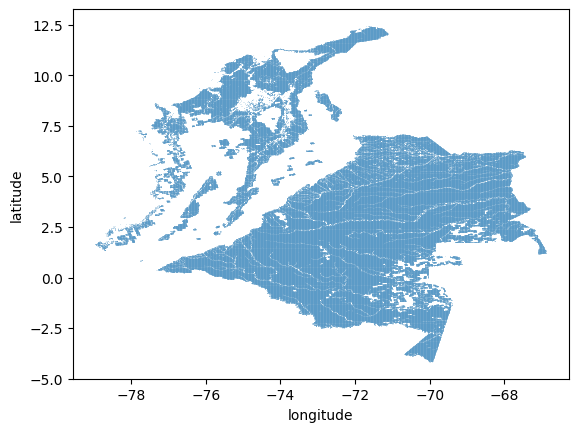

In [ ]:
sns.scatterplot(data=r,x='longitude',y='latitude',s=0.1)

In [ ]:
#X= np.loadtxt('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv',skiprows=1,delimiter=',', usecols=(2,3,5)) # se carga el archivo .csv
X=r.to_numpy()
X -= np.mean(X,axis=0) # Se deben normalizar las variables para que sean comparables# Se deben normalizar las variables para que sean comparables
X /= np.std(X,axis=0)


array([[  -4.175     ,  -69.985     , 1914.65282771],
       [  -4.165     ,  -69.995     , 1940.14050826],
       [  -4.155     ,  -70.005     , 1940.14050285],
       ...,
       [  12.435     ,  -71.635     , 1953.609375  ],
       [  12.445     ,  -71.665     , 1953.06396214],
       [  12.445     ,  -71.655     , 1956.07613601]])

/tmp/ipykernel_1728/3666907742.py:6: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagen para artículo


<Axes: xlabel='longitude', ylabel='latitude'>

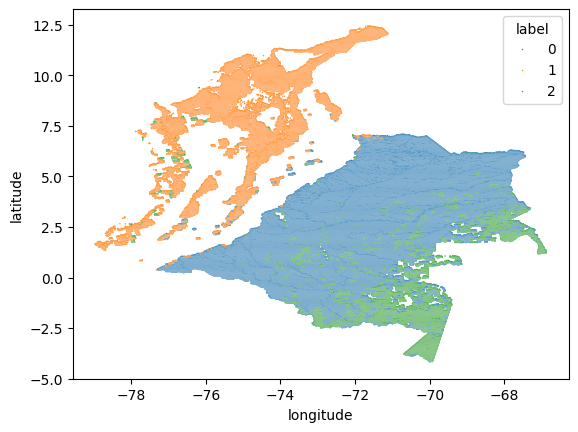

In [ ]:
alpha_star=3
kmeans = KMeans(n_clusters=alpha_star, random_state=42, n_init='auto').fit(X)
labe=kmeans.labels_
r['label']=labe
r
sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagen para artículo

In [ ]:
sns.scatterplot(data=r,x='longitude',y='latitude',hue='label',s=1,palette=sns.color_palette("tab10")) #Imagén para artículo

# 6. Clasificación (red neuronal)

Debido a que anteriormente, ningún clasificador hizo un buen trabajo, y simplemente tomaba toda la región del país como perteneciente a una misma intancia, se busca crear una red neuronal que haga la tarea de clasificación.

In [ ]:
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
y=labe
X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)

In [ ]:
X_train.shape

(420383, 2)

In [ ]:
class Data(Dataset):
  def __init__(self, X_train, y_train):
    # need to convert float64 to float32 else
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X_train.astype(np.float32))
    # need to convert float64 to Long else
    # will get the following error
    # RuntimeError: expected scalar type Long but found Float
    self.y = torch.from_numpy(y_train).type(torch.LongTensor)
    self.len = self.X.shape[0]

  def __getitem__(self, index):
    return self.X[index], self.y[index]
  def __len__(self):
    return self.len

In [ ]:
traindata = Data(X_train, Y_train)
print(traindata[25])

(tensor([-1.2128,  0.1842]), tensor(0))


In [ ]:

# number of features (len of X cols)
input_dim = 2
# number of hidden layers
hidden_layers = 25
#hidden_layers2 = 125
# number of classes (unique of y)
output_dim = 3
class Network(nn.Module):
    def __init__(self,hidden_layers):
        super(Network, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_layers)
        #self.linearh1=nn.Linear(hidden_layers,hidden_layers2)
        self.linear2 = nn.Linear(hidden_layers, output_dim)
    def forward(self, x):
        x = F.leaky_relu(self.linear1(x))
        #x = torch.sigmoid(self.linearh1(x))
        x = self.linear2(x)
        #x = F.softmax(x)
        return x


In [ ]:
epochs = 40
def run_epoch(epoch,ta,clf):
    criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
    optimizer = torch.optim.Adam(clf.parameters(), lr=ta)
    for epoch in range(epochs):
      running_loss = 0.0
      for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        # set optimizer to zero grad to remove previous epoch gradients
        optimizer.zero_grad()
        # forward propagation
        outputs = clf(inputs)
        loss = criterion(outputs, labels)
        # backward propagation
        loss.backward()
        # optimize
        optimizer.step()
        running_loss += loss.item()
      # display statistics
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')

In [ ]:
def test_val(clf):
    correct, total = 0, 0
    # no need to calculate gradients during inference
    with torch.no_grad():
      for data in testloader:
        inputs, labels = data
        # calculate output by running through the network
        outputs = clf(inputs)
        # get the predictions
        __, predicted = torch.max(outputs.data, 1)
        # update results
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Accuracy of the network on the {len(testdata)} test data: {100 * correct // total} %')
    return correct/total

In [ ]:
def parameters_train(ep,ta,hl):
    #nn_arch(hidden_layers)
    clf = Network(hl)
    epochs = ep
    lr=ta
    run_epoch(epoch,lr,clf)
    score=test_val(clf)
    return score

In [ ]:
#Se busca el mejor parámetro para la cantidad de capas ocultas
hd=np.arange(2,30,5)
epoch=40
lr=0.005
val_scores_hl=[]
batch_size = 20000
cv=3
for hidden_layers in hd:
    print(hidden_layers)
    val_scores_hl_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=2)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
        val_scores_hl_cv.append(parameters_train(epoch,lr,hidden_layers))
    val_scores_hl.append(np.mean(val_scores_hl_cv))

2
[40,    22] loss: 0.00079
Accuracy of the network on the 207055 test data: 88 %
[40,    22] loss: 0.00067
Accuracy of the network on the 207055 test data: 88 %


KeyboardInterrupt: 

HL_star = 10


ValueError: x and y must have same first dimension, but have shapes (6,) and (0,)

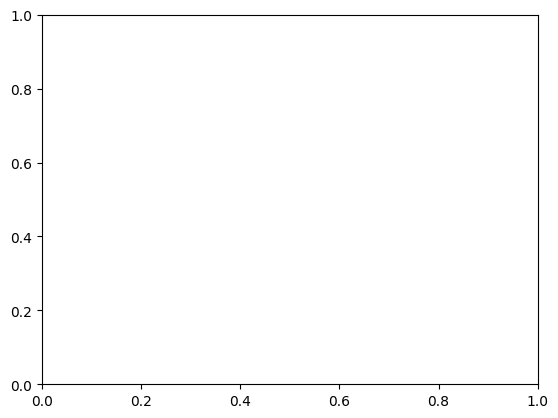

In [ ]:
#Se encuentra la mejor cantidad de puntos en la capa oculta
ind = np.argmax(val_scores_hl)
hl_star = 10#hd[ind] #Resultó ser 13
print('HL_star =', hl_star)

plt.plot(hd,val_scores_hl)
plt.plot(np.ones(11)*hl_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.9,1)
plt.ylim(0.9,1)
plt.xlabel('HL')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# Se busca el mejor valor para la tasa de aprendizaje
epoch=40
lr=np.arange(1e-5,0.01,5e-4)
val_scores_lr=[]
batch_size = 500
cv=4
for i in lr:
    #print(clf.parameters)
    print(i)
    val_scores_lr_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=2)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
        val_scores_lr_cv.append(parameters_train(epoch,i,hl_star))
    val_scores_lr.append(np.mean(val_scores_lr_cv))

In [ ]:
ind = np.argmax(val_scores_lr)
lr_star = lr[ind]
print('LR_star =', lr_star)

plt.plot(lr,val_scores_lr)
plt.plot(np.ones(11)*lr_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.95,1)
plt.ylim(0.95,1)
plt.xlabel('Learning Rate')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

LR_star = 0.005


NameError: name 'val_scores_lr' is not defined

In [ ]:
#plt.scatter(inputs[:,0],inputs[:,1],c=predicted)
parameters_train(40,0.005,15)

[40,    22] loss: 0.00096
Accuracy of the network on the 207055 test data: 88 %


0.8830117601603439

In [ ]:
# save the trained model
hl_star=15
clf = Network(hl_star)
criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
optimizer = torch.optim.Adam(clf.parameters(), lr=lr_star)
epochs = 40
for epoch in range(epochs):
  running_loss = 0.0
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    # set optimizer to zero grad to remove previous epoch gradients
    optimizer.zero_grad()
    # forward propagation
    outputs = clf(inputs)
    loss = criterion(outputs, labels)
    # backward propagation
    loss.backward()
    # optimize
    optimizer.step()
    running_loss += loss.item()
  # display statistics
  print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')
PATH = '/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/mymodel_prueba2.pth'
torch.save(clf.state_dict(), PATH)

[1,    22] loss: 0.00590
[2,    22] loss: 0.00409
[3,    22] loss: 0.00250
[4,    22] loss: 0.00168
[5,    22] loss: 0.00144
[6,    22] loss: 0.00131
[7,    22] loss: 0.00124
[8,    22] loss: 0.00120
[9,    22] loss: 0.00117
[10,    22] loss: 0.00115
[11,    22] loss: 0.00113
[12,    22] loss: 0.00112
[13,    22] loss: 0.00112
[14,    22] loss: 0.00113
[15,    22] loss: 0.00110
[16,    22] loss: 0.00111
[17,    22] loss: 0.00110
[18,    22] loss: 0.00109
[19,    22] loss: 0.00109
[20,    22] loss: 0.00109
[21,    22] loss: 0.00109
[22,    22] loss: 0.00108
[23,    22] loss: 0.00106
[24,    22] loss: 0.00104
[25,    22] loss: 0.00103
[26,    22] loss: 0.00104
[27,    22] loss: 0.00104
[28,    22] loss: 0.00103
[29,    22] loss: 0.00102
[30,    22] loss: 0.00102
[31,    22] loss: 0.00102
[32,    22] loss: 0.00103
[33,    22] loss: 0.00102
[34,    22] loss: 0.00101
[35,    22] loss: 0.00102
[36,    22] loss: 0.00101
[37,    22] loss: 0.00100
[38,    22] loss: 0.00101
[39,    22] loss: 0.0

In [ ]:
# load the trained model
clf = Network(hl_star)
clf.load_state_dict(torch.load(PATH))

<ipython-input-110-07824202a065>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clf.load_state_dict(torch.load(PATH))


<All keys matched successfully>

In [ ]:
# mapa con la clasificación de resultado
#sns.scatterplot(x=inputs[:,0],y=inputs[:,1])#],hue='label',s=1,palette=sns.color_palette("tab10"))
batch_size=len(y)
wdata = Data(X[:,[0,1]], y)
dataloader = DataLoader(wdata, batch_size=batch_size,
                                shuffle=True, num_workers=2)
y_pred=[]
for data in dataloader:
    inputs, labels = data
    # calculate output by running through the network
    outputs = clf(inputs)
    # get the predictions
    __, predicted = torch.max(outputs.data, 1)
    y_pred.append(predicted)
#r['region']=predicted
# fig, ax = plt.subplots()
# for label in [0, 1,2,3]:
#     mask = (y_pred == label)
#     ax.scatter(inputs[mask, 0], inputs[mask, 1],s=0.3)
#plt.scatter(inputs[:,0],inputs[:,1],c=predicted)


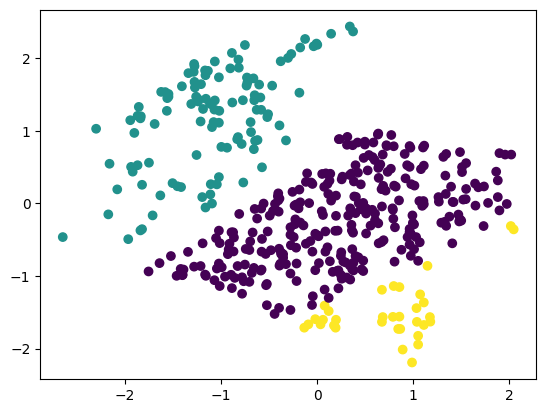

In [ ]:
plt.scatter(inputs[:,1],inputs[:,0],c=predicted)

<Axes: xlabel='longitude', ylabel='latitude'>

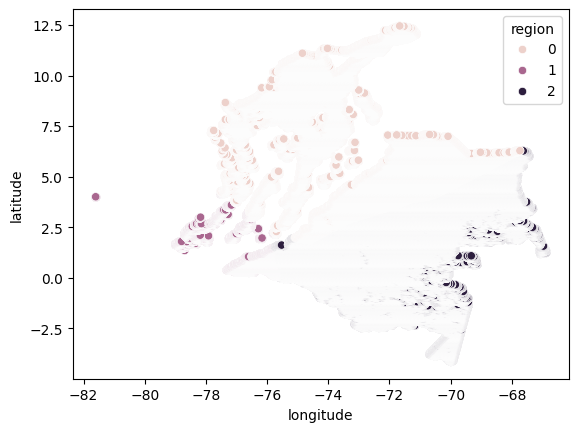

In [ ]:
r['region']=predicted
sns.scatterplot(data=r,x='longitude',y='latitude',hue='region')

array([[-2.24790812,  1.00495578],
       [-2.24504082,  1.00072485],
       [-2.24217352,  0.99649392],
       ...,
       [ 2.51467418,  0.31108332],
       [ 2.51754148,  0.2941596 ],
       [ 2.51754148,  0.29839053]])

# 7. Series de tiempo

In [ ]:
# #Crear los dataframes a partir de la clasificación
# df_car.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Caribe')
# df_valle.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Valle')
# df_amazon.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Amazonía')
# df_orin.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Orinoquía')
# df_pacif.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Pacífico')
# #df_bog.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Bogotá')
# df.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].plot(label='Colomibia')
# plt.legend()
# plt.ylabel('Methane concentration [ppb]')
# plt.xlabel('Date')
# plt.title('Methane Time Series for Colombian regions')
# plt.grid()

NameError: name 'df_car' is not defined

In [ ]:
#
# TODO(sección pendiente de actualizar): esta ruta sigue siendo de Colab y no
# existe en disco. Al retomar esta sección hay que apuntarla al promedio
# multianual local correspondiente en `directorio_datos`.
df_plot=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/colombia_prom.csv')

# La máscara de calidad se genera en el bloque de alistamiento y se consume
# SIEMPRE por función, nunca por ruta literal. Antes aquí se leía
# '/content/drive/.../datos_csv/colombia_filter.csv', que nunca existió en
# disco, así que este filtro no se estaba aplicando.
df_plot2 = aplicar_mascara(df_plot)
# 1. Asumimos que ya leíste tu shapefile de las 10 regiones
# gdf_regiones = gpd.read_file('ruta_a_tu_shapefile.shp')
# Asumimos que tu dataframe de metano se llama df_promedios

# 2. Convertir tu DataFrame normal a un GeoDataFrame de Puntos
gdf_puntos = gpd.GeoDataFrame(
    df_plot2,
    geometry=gpd.points_from_xy(df_plot2['longitude'], df_plot2['latitude']),
    crs="EPSG:4686"  # EPSG:4326 es el estándar para Latitud/Longitud (WGS84)
)

# 3. EL PASO MÁS IMPORTANTE: Igualar los Sistemas de Coordenadas (CRS)
# Si los mapas no están en el mismo sistema, el cruce dará vacío.
dfg1 = dfg1.to_crs(gdf_puntos.crs)

# 4. Hacer el Cruce Espacial (Spatial Join)
# Un left join asegura que no pierdas puntos, incluso si caen fuera de las 10 regiones (quedarán como NaN)
gdf_final = gpd.sjoin(
    gdf_puntos,
    dfg1,
    how="left",
    predicate="within" # "within" verifica si el punto está DENTRO del polígono
)


<Axes: >

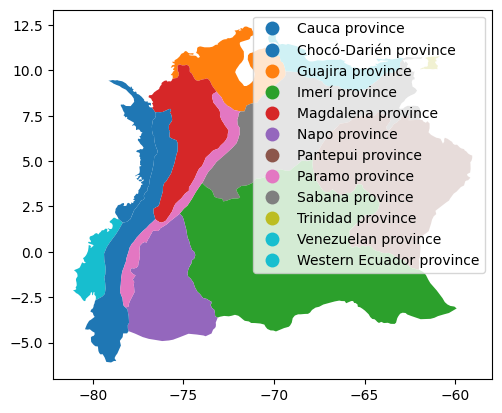

In [ ]:
dfg1=gpd.read_file(r'/content/drive/Shareddrives/PIGCC/Satelite/Scripts/Lowenberg_Neto_2014_shapefile/Lowenberg_Neto_2014.shp')#8\COBERTURAS CORINE 2018\shape coberturas 2018\cobertura_tierra_clc_2018.shp')
dfg1.loc[22:33].plot('Province_1',legend=True)
#dfg1#.loc[:35]#	DominionsSubregio_1

In [ ]:
# gdf_final.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/colombia_prom_regiones')

In [ ]:
# # Sintaxis: df.loc[condicion_de_filas, 'nombre_de_columna'] = nuevo_valor

# gdf_final.loc[gdf_final['Province_1'] == 'Western Ecuador province', 'Province_1'] = 'Chocó-Darién province'
# gdf_final.loc[gdf_final['Province_1'] == 'Napo province', 'Province_1'] = 'Imerí province'
# gdf_final.loc[gdf_final['Province_1'] == 'Pantepui province', 'Province_1'] = 'Imerí province'

In [ ]:
# gdf_final
# ts_global = df_plot.groupby('fecha')[CH4_COL].median().reset_index()
gdf_final=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/colombia_prom_regiones')

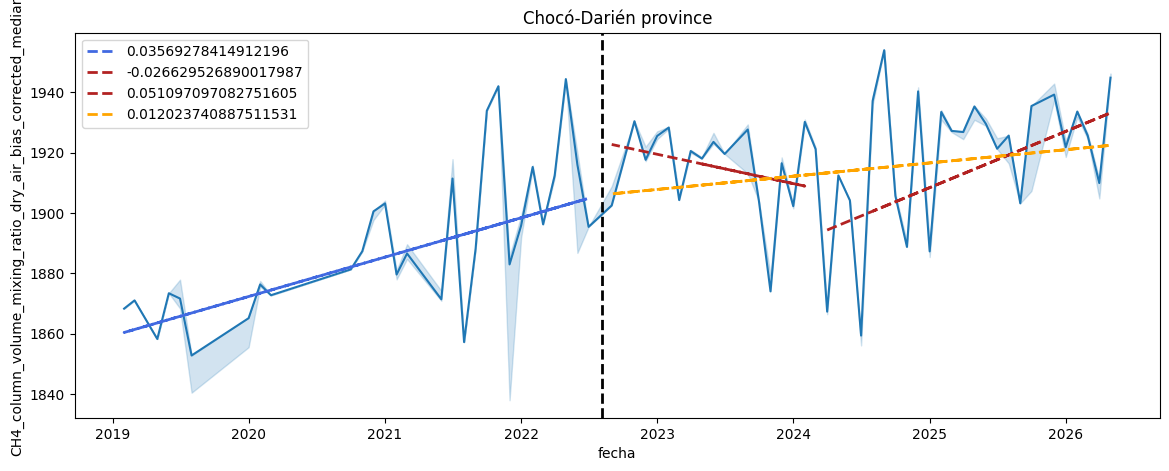

/tmp/ipykernel_9382/3906230564.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


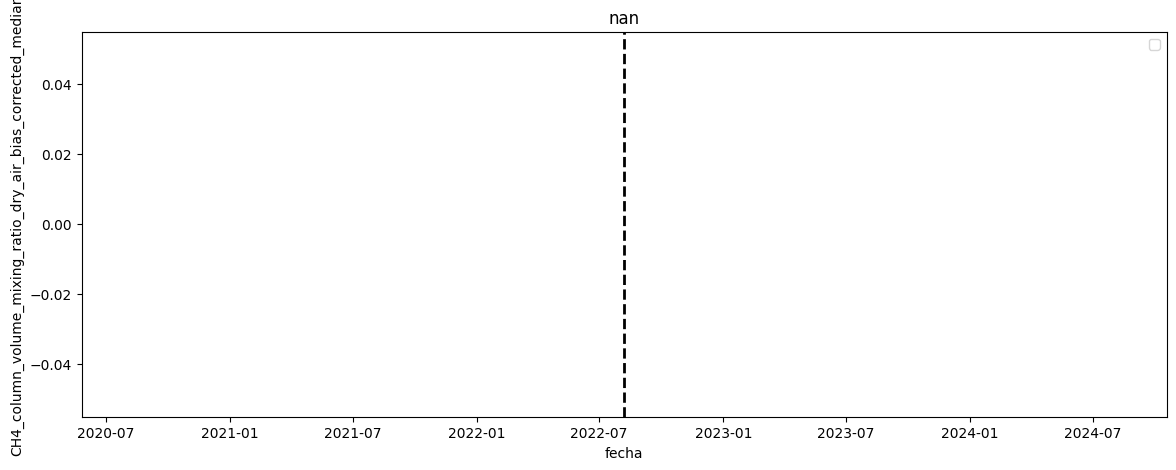

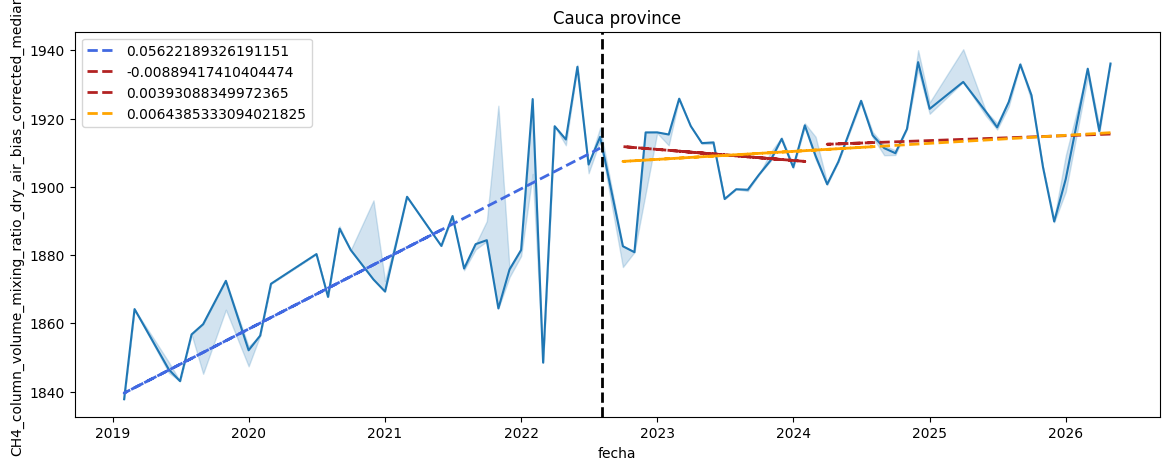

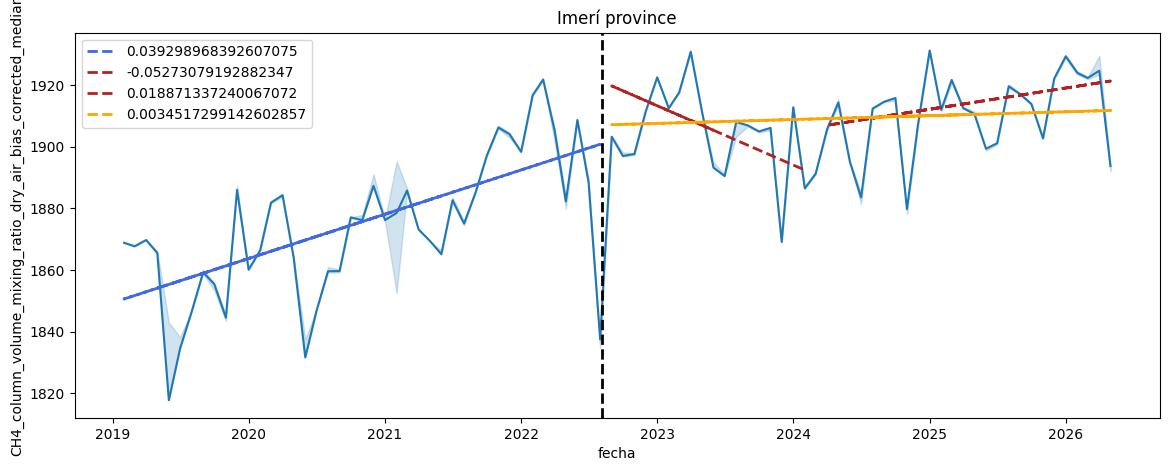

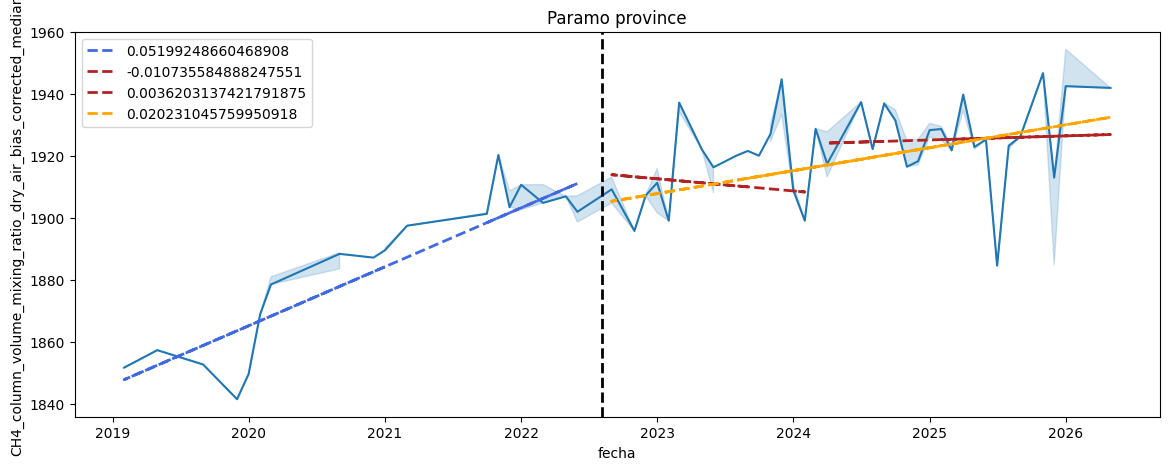

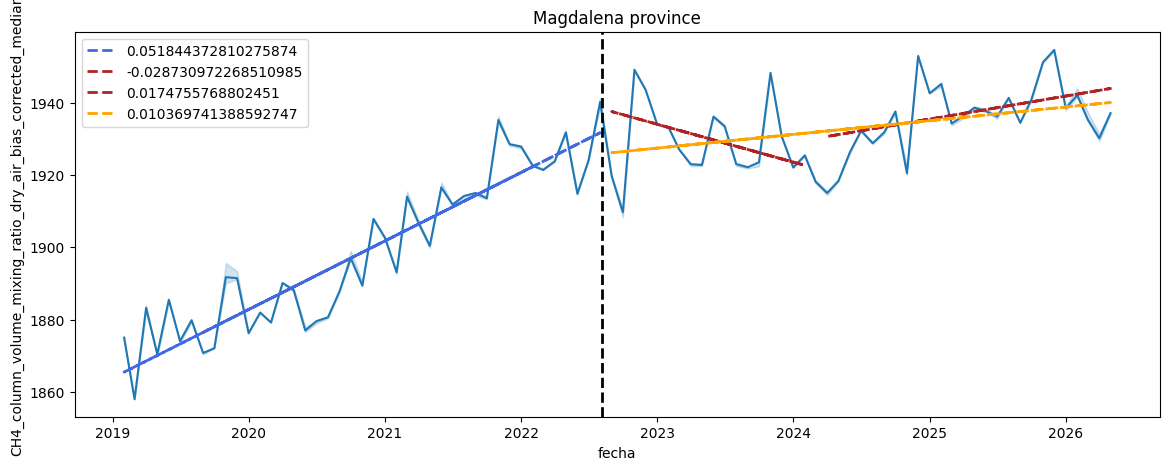

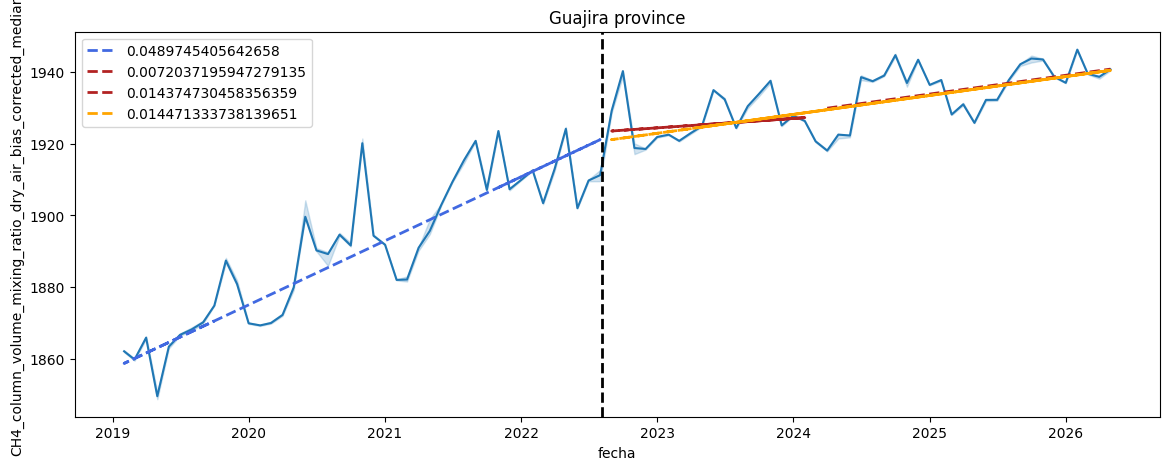

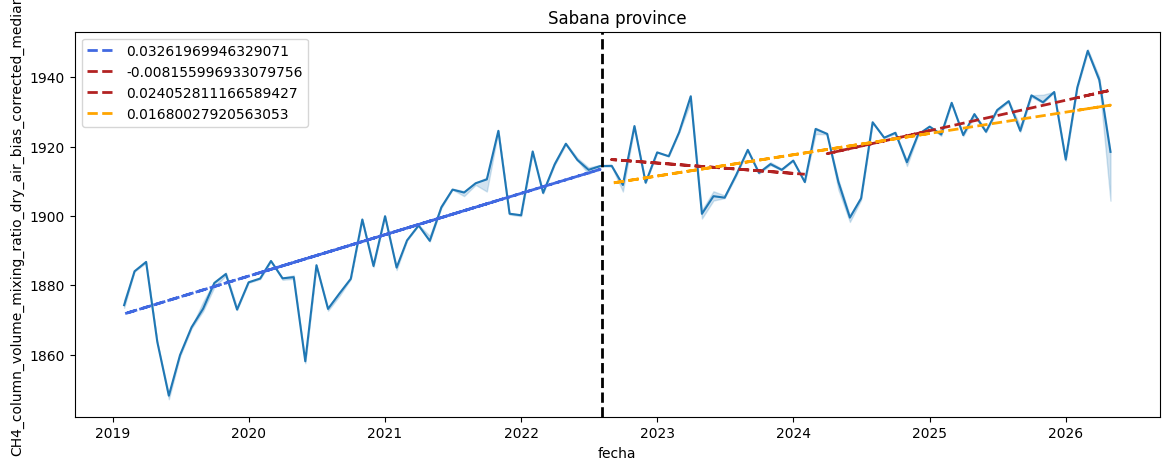

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


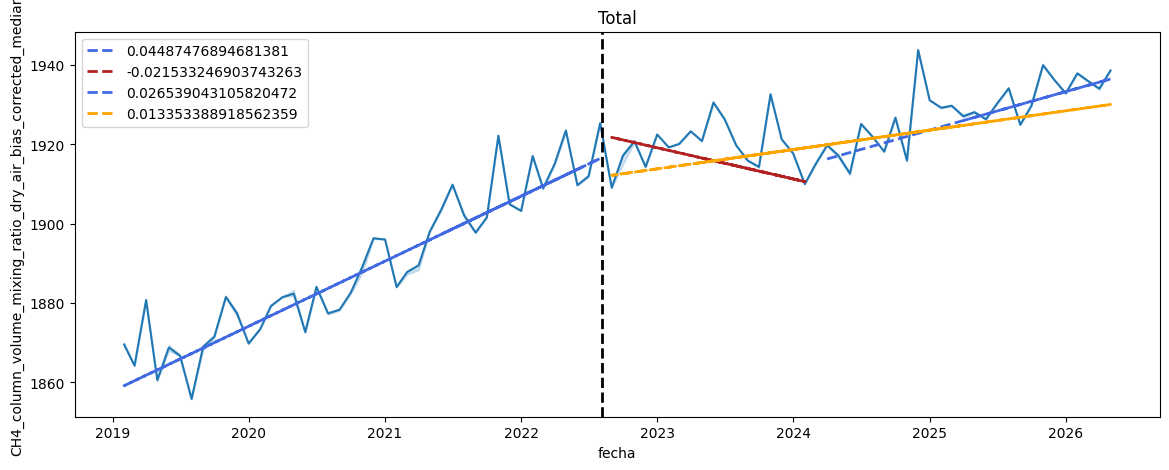

In [ ]:
import matplotlib.dates as mdates
from scipy.stats import linregress
def graficar_tendencia(df_subset, color, label):
    # Evitar que el código falle si un periodo tiene menos de 2 datos para hacer la regresión
    if len(df_subset) < 2:
        return

    x_num = mdates.date2num(df_subset['fecha'])
    y = df_subset[CH4_COL]

    slope, intercept, r_value, p_value, std_err = linregress(x_num, y)
    y_pred = slope * x_num + intercept

    ax.plot(df_subset['fecha'], y_pred, color=color, linewidth=2, linestyle='--', label=slope)
CH4_COL='CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median'
# df_plot['fecha'] = pd.to_datetime(df_plot[['year', 'month']])
# Pandas requiere un 'day' para crear un datetime, así que asignamos el día 1 por defecto
#df_plot['fecha'] = pd.to_datetime(df_plot[['year', 'month']].assign(day=1))
gdf_final['fecha'] = pd.to_datetime(gdf_final[['year', 'month']].assign(day=1))
df_periodo_3=gdf_final[gdf_final['fecha']>pd.to_datetime('2024-03-01')].copy()
df_periodo_2=gdf_final[(gdf_final['fecha']>pd.to_datetime('2022-08-07')) & (gdf_final['fecha']<pd.to_datetime('2024-03-01'))].copy()
df_periodo_1=gdf_final[gdf_final['fecha']<pd.to_datetime('2022-08-07')]
df_periodo_4=gdf_final[gdf_final['fecha']>pd.to_datetime('2022-08-07')]

# df_periodo_1 = df[df['fecha'] < fecha_corte_1].copy()
# df_periodo_2 = df[(df['fecha'] >= fecha_corte_1) & (df['fecha'] < fecha_corte_2)].copy()
# df_periodo_3 = df[df['fecha'] >= fecha_corte_2].copy()

for i in gdf_final['Province_1'].unique():
  fig, ax = plt.subplots(figsize=(14, 5))
  sns.lineplot(data=gdf_final[gdf_final['Province_1']==i],x='fecha',y=CH4_COL,estimator='median')
  plt.title(i)
  # Aplicar la función a los tres periodos con colores distintos
  graficar_tendencia(df_periodo_1[df_periodo_1['Province_1']==i], 'royalblue', 'Tendencia Pre 7 Ago 2022')
  graficar_tendencia(df_periodo_2[df_periodo_2['Province_1']==i], 'firebrick', 'Tendencia 2022 - 2024')
  graficar_tendencia(df_periodo_3[df_periodo_3['Province_1']==i], 'firebrick', 'Tendencia 2024 - 2026')
  graficar_tendencia(df_periodo_4[df_periodo_4['Province_1']==i], 'orange', 'Tendencia Pos 7 Ago 2022')
  plt.axvline(pd.to_datetime('2022-08-07'), color='black', linestyle='dashed', linewidth=2)
  plt.legend()
  # graficar_tendencia(df_periodo_3, 'darkorange', 'Tendencia Post 7 Ago 2024')
  plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=gdf_final,x='fecha',y=CH4_COL,estimator='median')
plt.title('Total')
# Aplicar la función a los tres periodos con colores distintos
graficar_tendencia(df_periodo_1, 'royalblue', 'Tendencia Pre 7 Ago 2022')
graficar_tendencia(df_periodo_2, 'firebrick', 'Tendencia 2022 - 2024')
graficar_tendencia(df_periodo_3, 'royalblue', 'Tendencia 2024 - 2026')
graficar_tendencia(df_periodo_4, 'orange', 'Tendencia Pos 7 Ago 2022')
plt.axvline(pd.to_datetime('2022-08-07'), color='black', linestyle='dashed', linewidth=2)
plt.legend()
# graficar_tendencia(df_periodo_3, 'darkorange', 'Tendencia Post 7 Ago 2024')
plt.show()

<Axes: xlabel='fecha', ylabel='CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median'>

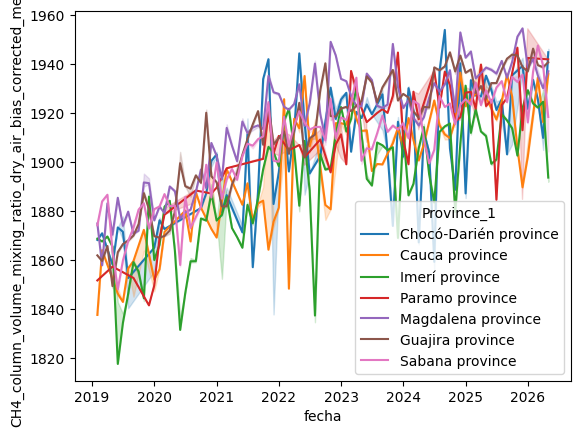

In [ ]:
# gdf_final['fecha'] = pd.to_datetime(gdf_final[['year', 'month']].assign(day=1))
# ts_global = gdf_final.groupby(['fecha','Province_1'])[CH4_COL].median().reset_index()
sns.lineplot(data=gdf_final,x='fecha',y=CH4_COL,hue='Province_1',estimator='median')
#plt.title('Total')
#

In [ ]:
#gdf_prom=gdf_final.groupby(['longitude','latitude'])['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median'].median().reset_index()
gdf_final
ts_global = df_plot.groupby('fecha')[CH4_COL].median().reset_index()
#sns.scatterplot(data=gdf_prom,x='longitude',y='latitude',hue='Province_1')

,longitude,latitude,year,month,CH4_column_volume_mixing_ratio_dry_air_bias_corrected_mean,CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median,fecha,geometry,index_right,NUMB,REGION,SOURCE,Province_1,Dominions,Subregio_1,DOI,PaperURL,CITATION_1
0,-78.965,1.635,2023,5,1865.585938,1865.585938,2023-05-01,POINT (-78.965 1.635),22.0,28.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Western Ecuador province,Pacific dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
1,-78.965,1.635,2024,4,1948.899414,1948.899414,2024-04-01,POINT (-78.965 1.635),22.0,28.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Western Ecuador province,Pacific dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
2,-78.965,1.645,2023,5,1865.585938,1865.585938,2023-05-01,POINT (-78.965 1.645),22.0,28.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Western Ecuador province,Pacific dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
3,-78.965,1.645,2024,4,1948.899414,1948.899414,2024-04-01,POINT (-78.965 1.645),22.0,28.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Western Ecuador province,Pacific dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
4,-78.965,1.655,2023,5,1865.585938,1865.585938,2023-05-01,POINT (-78.965 1.655),22.0,28.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Western Ecuador province,Pacific dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5449230,-66.875,1.225,2024,2,1894.769073,1894.769073,2024-02-01,POINT (-66.875 1.225),29.0,31.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Imerí province,Boreal Brazilian dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
5449231,-66.875,1.225,2024,11,1836.948336,1836.948336,2024-11-01,POINT (-66.875 1.225),29.0,31.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Imerí province,Boreal Brazilian dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
5449232,-66.875,1.235,2024,2,1893.498657,1893.498657,2024-02-01,POINT (-66.875 1.235),29.0,31.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Imerí province,Boreal Brazilian dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...
5449233,-66.875,1.235,2024,11,1835.546265,1835.546265,2024-11-01,POINT (-66.875 1.235),29.0,31.0,Neotropical region,Morrone JJ (2014) Zootaxa 3782: 1110,Imerí province,Boreal Brazilian dominion,Brazilian subregion,http://dx.doi.org/10.11646/zootaxa.3802.2.12,http://zoobank.org/urn:lsid:zoobank.org:pub:FB...,Löwenberg-Neto P (2014) Neotropical region: a ...


In [ ]:
series1=df.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series1_std=df.groupby(['year','month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2=df_amazon.groupby(['year','month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2_std=df_amazon.groupby(['year','month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
df_mean=pd.merge(series1,series2, on=['year','month'])
df_std=pd.merge(series1_std,series2_std, on=['year','month'])
df_mean

In [ ]:
import scipy.stats as stats

series1=df_mean['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_x']
series1_std=df_std['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_x']
series2=df_mean['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_y']
series2_std=df_std['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_y']
t_stat, p_value = stats.ttest_ind_from_stats(
    mean1=np.array(series1),
    std1=np.array(series1_std),
    nobs1=len(series1),
    mean2=np.array(series2),
    std2=np.array(series2_std),
    nobs2=len(series2),
    alternative='greater'
)
print(sum(p_value*100>5)/len(series1)*100) #porcentaje en el que no hay evidencia suficiente para rechazar la hipótesis
print(sum(p_value*100<0.1)/len(series1)*100) # Porcentaje en el que hay evidencia indistutible para rechazar la hipótesis nula
#print(max(p_value)*100)
i_p=np.argwhere(p_value>0.05)
ind[i_p]

In [ ]:
t_stat, p_value = stats.ttest_ind(series1, series2, equal_var=False,alternative='greater')
print(p_value*100) # comparación de medias, Evidencia indiscutible

In [ ]:
#Se sospecha que no siempre es menor el metano en el Amazonas, por lo que se hace prueba de hipótesis entre promedios multianuales
series1m=df.groupby(['month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series1_stdm=df.groupby(['month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2m=df_amazon.groupby(['month']).mean()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
series2_stdm=df_amazon.groupby(['month']).std()['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
t_statm, p_valuem = stats.ttest_ind_from_stats(
    mean1=np.array(series1m),
    std1=np.array(series1_stdm),
    nobs1=len(series1m),
    mean2=np.array(series2m),
    std2=np.array(series2_stdm),
    nobs2=len(series2m),
    alternative='greater'
)
print(p_valuem*100<5)
print(p_valuem*100) # No se puede refutar la hipótesis de que el Amazonas tenga menores niveles de metano en los meses de Enero, Febrero, Marzo y Diciembre

In [ ]:
# df_final.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/colombia_prom_regiones')
df_tsc=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/colombia_prom_regiones',skiprows=1)
df_tsc=df_tsc[(df_tsc['value']>1850)*(df_tsc['year']>2015)]
df_tsc.groupby(['year','month'])[CH4_COL].median().plot()
plt.ylabel('Methane concentration [ppb]')
plt.xlabel('Month')
plt.title('Methane Time Series reference value')
plt.grid()


KeyError: 'value'

In [ ]:
df_g

,year,month,decimal,average,average_unc,trend,trend_unc
390,2016,1,2016.042,1842.46,0.98,1839.66,0.61
391,2016,2,2016.125,1841.64,1.16,1840.36,0.63
392,2016,3,2016.208,1843.00,0.87,1841.04,0.64
393,2016,4,2016.292,1843.75,0.75,1841.70,0.65
394,2016,5,2016.375,1842.14,0.87,1842.33,0.65
...,...,...,...,...,...,...,...
507,2025,10,2025.792,1945.97,-9.99,1937.59,-9.99
508,2025,11,2025.875,1945.96,-9.99,1938.08,-9.99
509,2025,12,2025.958,1942.45,-9.99,1938.60,-9.99
510,2026,1,2026.042,1940.88,-9.99,1939.14,-9.99


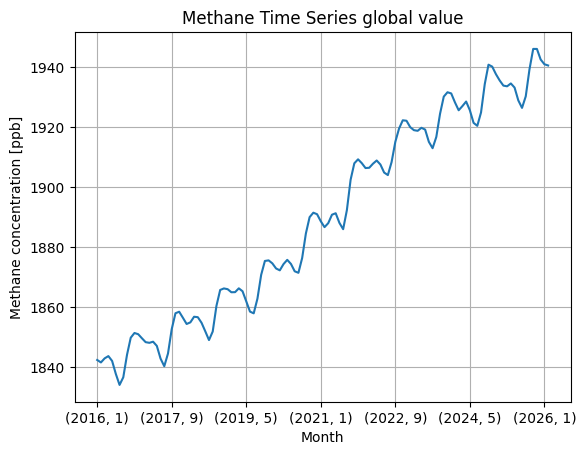

In [ ]:
df_g=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/ch4_mm_gl.csv',skiprows=45)
df_g=df_g[df_g['year']>2015]
df_g.groupby(['year','month'])['average'].mean().plot()
plt.ylabel('Methane concentration [ppb]')
plt.xlabel('Month')
plt.title('Methane Time Series global value')
plt.grid()

In [ ]:
df_c_b=pd.merge(df,df_c, on=['year','month'])
df_c_r=pd.merge(df_c_b,df_g,on=['year','month'])
df_c_r

In [ ]:
df_c_r.groupby(['year','month'])['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].mean().plot(label='Colombia')
df_c_r.groupby(['year','month'])['average'].mean().plot(label='Global')
df_c_r.groupby(['year','month'])['value'].mean().plot(label='Barbados')
plt.legend()
plt.ylabel('Methane concentration [ppb]')
plt.xlabel('Date')
plt.title('Methane Time Series for Colombia vs reference value')
plt.grid()

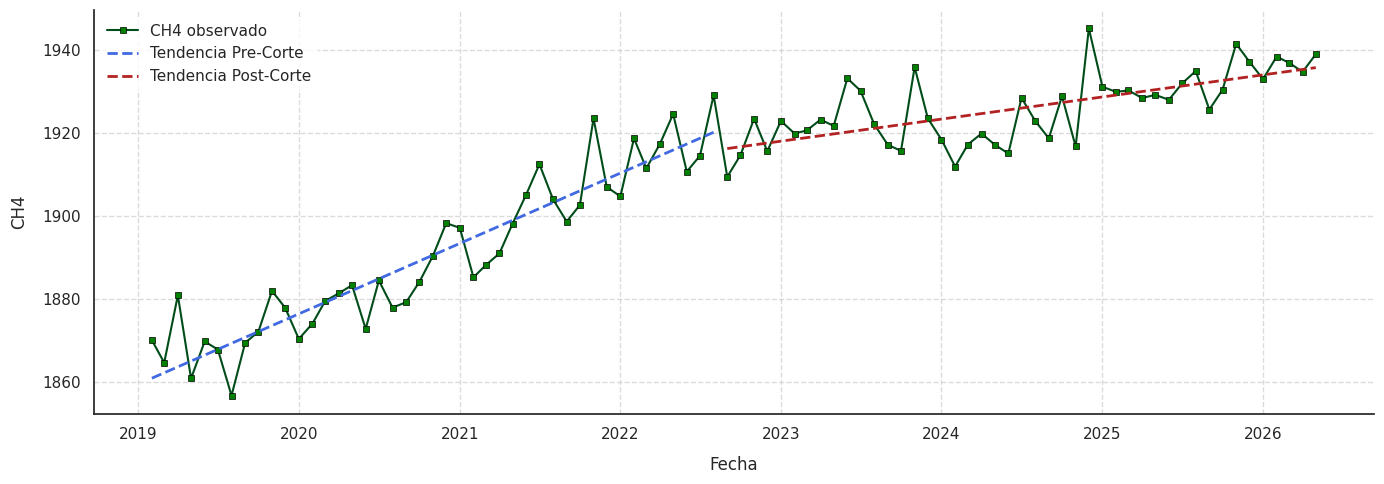

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress

# 1. Preparar datos
df=ts_global
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha')

fecha_corte = pd.to_datetime('2022-08-07')
df_antes = df[df['fecha'] < fecha_corte].copy()
df_despues = df[df['fecha'] >= fecha_corte].copy()

# 2. Configurar el estilo de la figura
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 5))

# --- PARTE 1: La Serie de Tiempo Continua ---
sns.lineplot(
    data=df,
    x='fecha',
    y=CH4_COL,
    color='#004d1a',
    linewidth=1.5,
    marker='s', markersize=4, markerfacecolor='green', markeredgecolor='black', markeredgewidth=0.5,
    ax=ax, label='CH4 observado'
)

# --- PARTE 2: Calcular y graficar tendencias manualmente (LA SOLUCIÓN) ---

def graficar_tendencia(df_subset, color, label):
    # a) Extraer X (como números para la matemática) y Y
    x_num = mdates.date2num(df_subset['fecha'])
    y = df_subset[CH4_COL]

    # b) Calcular la regresión lineal
    slope, intercept, r_value, p_value, std_err = linregress(x_num, y)

    # c) Crear los puntos Y de la línea recta
    y_pred = slope * x_num + intercept

    # d) Graficar usando las FECHAS ORIGINALES, para que encaje perfecto en el eje X
    ax.plot(df_subset['fecha'], y_pred, color=color, linewidth=2, linestyle='--', label=label)

# Aplicar la función a ambos periodos
if not df_antes.empty:
    graficar_tendencia(df_antes, 'royalblue', 'Tendencia Pre-Corte')
if not df_despues.empty:
    graficar_tendencia(df_despues, 'firebrick', 'Tendencia Post-Corte')

# --- PARTE 3: Estilización ---
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, which='both', linestyle='--', color='#cccccc', alpha=0.7)
sns.despine(ax=ax, top=True, right=True)

plt.xlabel('Fecha', fontsize=12, labelpad=10)
plt.ylabel('CH4', fontsize=12, labelpad=10)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

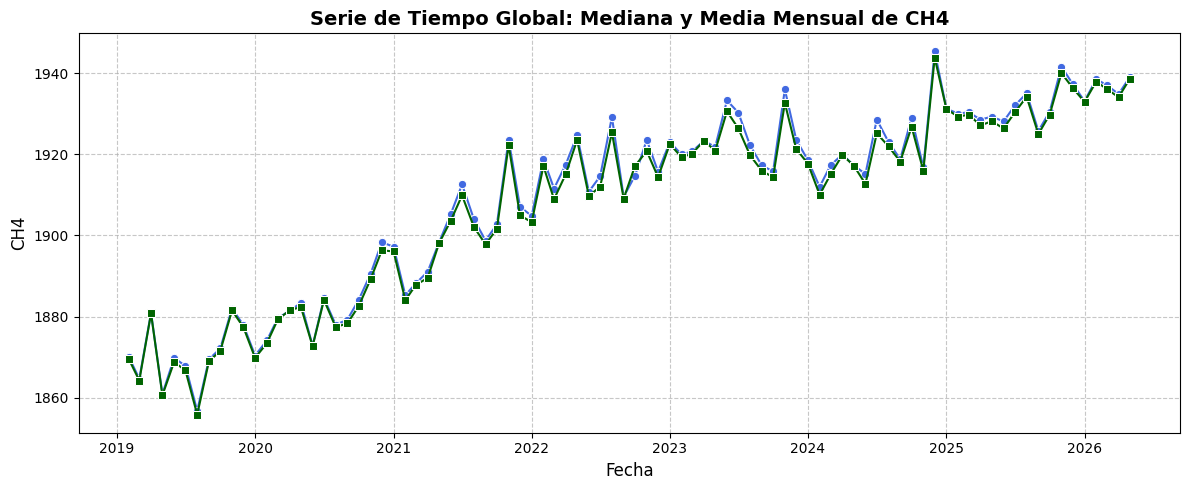

In [ ]:
import matplotlib.dates as mdates
from scipy.stats import linregress
# df_plot=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/colombia_prom.csv')
# df_filter=pd.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_filter.csv')
# 1. Aplanar el MultiIndex para convertirlo de nuevo en un DataFrame normal
# df_plot = monthly_median.reset_index()
# df_plot2 = monthly_mean.reset_index()
df_plot2=pd.merge(df_plot,df_filter[['latitude','longitude']],on=['latitude','longitude'], how='inner')
# 2. Crear una columna 'fecha' combinando 'year' y 'month'
CH4_COL='CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median'
# df_plot['fecha'] = pd.to_datetime(df_plot[['year', 'month']])
# Pandas requiere un 'day' para crear un datetime, así que asignamos el día 1 por defecto
df_plot['fecha'] = pd.to_datetime(df_plot[['year', 'month']].assign(day=1))
df_plot2['fecha'] = pd.to_datetime(df_plot2[['year', 'month']].assign(day=1))
# Agrupar por la nueva columna 'fecha' para obtener el valor consolidado mensual
ts_global = df_plot.groupby('fecha')[CH4_COL].median().reset_index()
ts_global2 = df_plot2.groupby('fecha')[CH4_COL].median().reset_index()
#ts_global2 = df_plot.groupby('fecha')['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_mean'].median().reset_index()
#ts_global2 = pd.merge(ts_global,df_filter,on=['latitude','longitude'], how='inner')
#ts_global2=ts_global2.groupby('fecha')['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_mean'].median().reset_index(
# Configurar y dibujar la gráfica
plt.figure(figsize=(12, 5))
sns.lineplot(data=ts_global, x='fecha', y=CH4_COL, marker='o', color='royalblue')
sns.lineplot(data=ts_global2, x='fecha', y=CH4_COL, marker='s', color='darkgreen')
plt.title('Serie de Tiempo Global: Mediana y Media Mensual de CH4', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('CH4', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
ts_global2#pd.merge(df_plot,df_filter[['latitude','longitude']],on=['latitude','longitude'], how='inner')

,fecha,CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median
0,2019-02-01,1869.552588
1,2019-03-01,1864.220947
2,2019-04-01,1880.759939
3,2019-05-01,1860.592896
4,2019-06-01,1868.792030
...,...,...
83,2026-01-01,1932.893311
84,2026-02-01,1937.912720
85,2026-03-01,1936.046879
86,2026-04-01,1934.062193


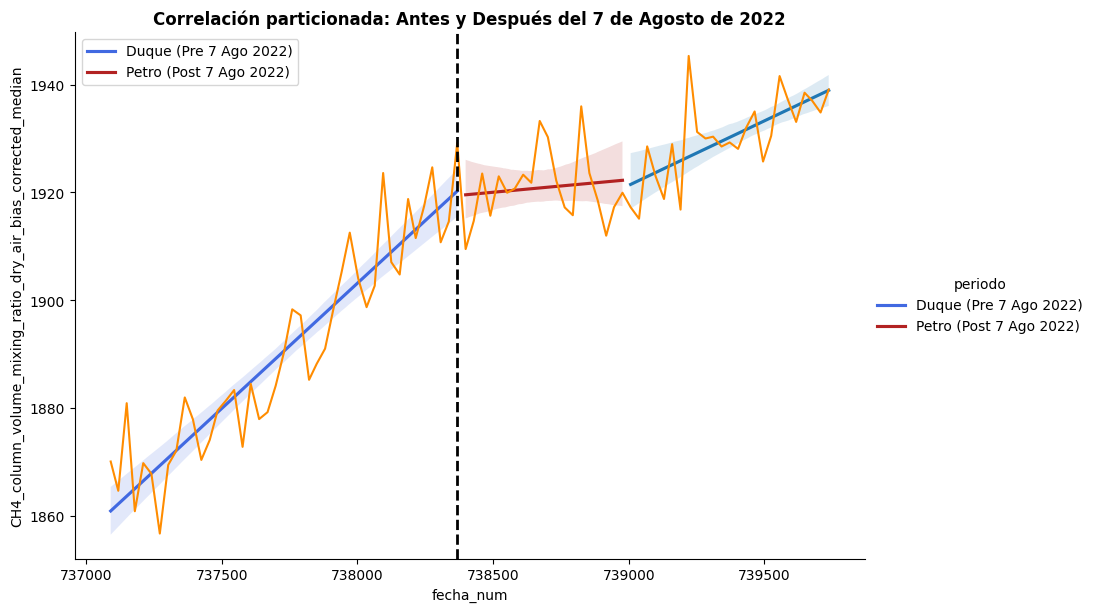

In [ ]:
# 1. Asegurarte de que tu columna de fecha sea formato datetime
#df_plot['fecha'] = pd.to_datetime(df_plot['fecha'])
#ts_global=ts_global[]
# 2. Definir la fecha de corte
fecha_corte = pd.to_datetime('2022-08-07')

# 3. Crear una nueva columna categórica usando np.where

ts_global['periodo'] = np.where(ts_global['fecha'] < fecha_corte, 'Duque (Pre 7 Ago 2022)', 'Petro (Post 7 Ago 2022)')
#ts_global['periodo']= np.where(ts_global['fecha'] > pd.to_datetime('2024-08-07'), 'Petro (Post 7 Ago 2024)')
ts_global['fecha_num'] = ts_global['fecha'].map(pd.Timestamp.toordinal)
ts_global2=ts_global[ts_global['fecha']>pd.to_datetime('2024-04-07')]
ts_global1=ts_global[ts_global['fecha']<pd.to_datetime('2024-04-07')]

grafico = sns.lmplot(
    data=ts_global1,
    x='fecha_num',  # Reemplaza con tu columna X (ej. delta cobertura)
    y=CH4_COL,  # Reemplaza con tu columna Y (ej. metano)
    hue='periodo',   # Esta es la magia que crea dos líneas
    palette=['royalblue', 'firebrick'], # Colores para Antes y Después
    height=6,
    aspect=1.5,
    scatter=False
    #scatter_kws={'alpha': 0.5} # Hace los puntos semi-transparentes
)
sns.regplot(
    data=ts_global2,
    x='fecha_num',  # Reemplaza con tu columna X (ej. delta cobertura)
    y=CH4_COL,  # Reemplaza con tu columna Y (ej. metano)
    #hue='periodo',   # Esta es la magia que crea dos líneas
    #palette=['royalblue', 'firebrick'], # Colores para Antes y Después
    #height=6,
    #aspect=1.5,
    scatter=False
)
sns.lineplot(data=ts_global, x='fecha_num', y=CH4_COL, color='darkorange')
plt.axvline(738368, color='black', linestyle='dashed', linewidth=2)

plt.title('Correlación particionada: Antes y Después del 7 de Agosto de 2022', fontweight='bold')
plt.show()

In [ ]:
ts_global.loc[20:45]#[ts_global['fecha']==fecha_corte]#['fecha_num']

,fecha,CH4_column_volume_mixing_ratio_dry_air_bias_corrected_median,periodo,fecha_num
20,2020-10-01,1884.140827,Duque (Pre 7 Ago 2022),737699
21,2020-11-01,1890.455078,Duque (Pre 7 Ago 2022),737730
22,2020-12-01,1898.317383,Duque (Pre 7 Ago 2022),737760
23,2021-01-01,1897.199184,Duque (Pre 7 Ago 2022),737791
24,2021-02-01,1885.245585,Duque (Pre 7 Ago 2022),737822
25,2021-03-01,1888.193726,Duque (Pre 7 Ago 2022),737850
26,2021-04-01,1891.018188,Duque (Pre 7 Ago 2022),737881
27,2021-05-01,1898.214722,Duque (Pre 7 Ago 2022),737911
28,2021-06-01,1905.233032,Duque (Pre 7 Ago 2022),737942
29,2021-07-01,1912.544800,Duque (Pre 7 Ago 2022),737972


# 8. Detección de anomalías

In [ ]:
X= np.loadtxt(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv',skiprows=1, usecols=(1,2,4),delimiter=',')
X

array([[ -77.305     ,    7.745     , 1866.55965028],
       [ -77.305     ,    7.755     , 1866.55961485],
       [ -77.295     ,    7.705     , 1866.55956703],
       ...,
       [ -67.325     ,    3.455     , 1835.4564209 ],
       [ -67.315     ,    3.435     , 1835.45643867],
       [ -67.315     ,    3.445     , 1835.4564209 ]])

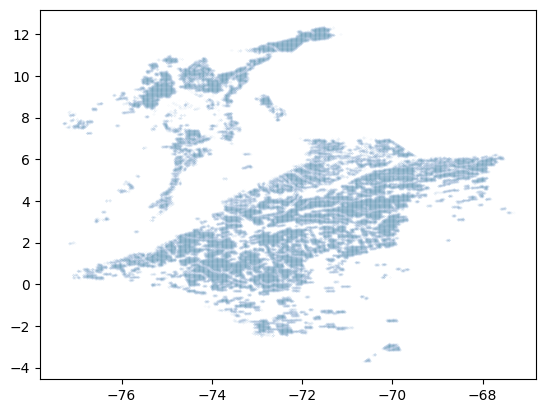

In [ ]:
plt.scatter(X[:,0],X[:,1],s=0.0001)

In [ ]:
def prepData(processed_data,iSplit=0.5):
    # gaia_vars=['phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag']
    # var0=(igaia_data[gaia_vars[0]]-idist.distmod).value
    # var1=(igaia_data[gaia_vars[1]]-idist.distmod).value
    # var2=(igaia_data[gaia_vars[2]]-idist.distmod).value
    # var3=igalcen.x.value
    # var4=igalcen.y.value
    # var5=igalcen.z.value
    # var6=igalcen.v_x.value
    # var7=igalcen.v_y.value
    # var8=igalcen.v_z.value

    #processed_data = np.vstack((var0,var1,var2,var3,var4,var5,var6,var7,var8))
    # processed_data = np.vstack((var0,var1,var2,var3,var4,var5,var6,var7,var8))
    # processed_data = processed_data.T
    # processed_data = processed_data[~np.isnan(processed_data).any(axis=1)]
    processed_data_raw = processed_data.copy()

    #normalize the data
    processed_data -= np.mean(processed_data,axis=0)
    processed_data /= np.std(processed_data,axis=0)
    processed_data = processed_data[~np.isnan(processed_data).any(axis=1)]

    #pytorch the layer
    tprocessed_data = torch.tensor(processed_data).float()
    processed_data_raw = processed_data_raw[~torch.any(tprocessed_data.isnan(),dim=1)]
    #galcen_clean       = igalcen[~torch.any(tprocessed_data.isnan(),dim=1)]
    n_samples=processed_data.shape[0]
    indices = np.arange(n_samples)
    #split
    X_train, X_test, Y_train, Y_test = train_test_split(processed_data, indices, test_size=iSplit)
    maxindex       = int(len(processed_data)*iSplit)
    trainset       = torch.tensor(X_train).float()
    trainset       = trainset[~torch.any(trainset.isnan(),dim=1)]
    testset        = torch.tensor(X_test).float()
    testset        = testset[~torch.any(testset.isnan(),dim=1)]
    print(processed_data_raw.shape,testset.shape,trainset.shape)
    return testset,trainset,processed_data_raw,tprocessed_data, Y_train, Y_test #,galcen_clean

#btestset,btrainset,bprocessed_data_raw,btprocessed_data,bgalcen_clean=prepData(gaia_data,dist,galcen)
btestset,btrainset,bprocessed_data_raw,btprocessed_data,index_train,index_test=prepData(X)

(248583, 3) torch.Size([124292, 3]) torch.Size([124291, 3])


In [ ]:
#autoencoder para que la red neuronal aprenda las características más relevantes de los datos
class MLP(nn.Module):
    def __init__(self,n_inputs,n_outputs):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_inputs, 20),
            nn.LeakyReLU(),
            nn.Linear(20, 6),
            nn.ReLU(),
            nn.Linear(6, 2),
            nn.ReLU(),
            nn.Linear(2, 6),
            nn.ReLU(),
            nn.Linear(6, 20),
            nn.ReLU(),
            nn.Linear(20, n_outputs),
        )

    def forward(self, x):
        x = self.layers(x)
        return x

def train(x,y,net,loss_func,opt,sched,nepochs):
    net.train(True)
    for epoch in range(nepochs):
        prediction = net(x)
        opt.zero_grad()
        loss = loss_func(prediction,y)
        loss.backward()
        opt.step()
        if epoch % 500 == 0:
            print('[%d] loss: %.4f ' % (epoch + 1, loss.item()  ))
    #sched.step()
    return

basicmodel     = MLP(btrainset.shape[1],1)#btrainset.shape[1])
optimizer = torch.optim.Adam(basicmodel.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1, last_epoch=-1, verbose=False)
loss_fn   =  nn.MSELoss(reduction='sum')

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
train(btrainset,btrainset[:,2:],basicmodel,loss_fn,optimizer,scheduler,5001)

[1] loss: 128365.7344 
[501] loss: 53.6156 
[1001] loss: 18.3428 
[1501] loss: 7.8193 
[2001] loss: 4.3443 
[2501] loss: 2.6354 
[3001] loss: 1.6575 
[3501] loss: 1.1730 
[4001] loss: 0.9142 
[4501] loss: 0.7922 
[5001] loss: 0.5201 


In [ ]:
btrainset.shape

torch.Size([124291, 3])

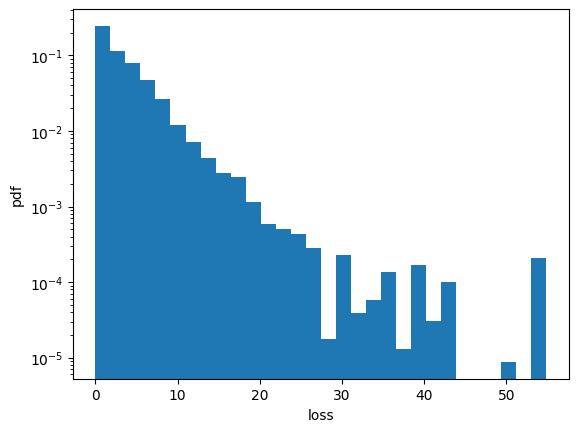

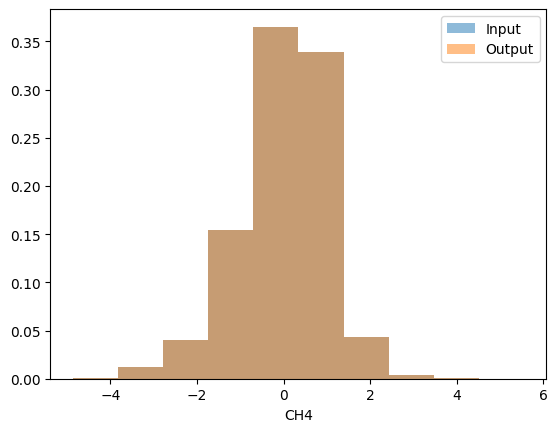

In [ ]:
basicmodel.train(False)
boutput=basicmodel(btestset)
btestloss=torch.sum((btestset-boutput)**2,axis=1)
#btestloss2=torch.sum((btestset-boutput)**1,axis=1)
plt.hist(btestloss[btestloss < 100].detach().numpy(),density=True,bins=30)
plt.yscale('log')
plt.xlabel('loss')
plt.ylabel('pdf')
plt.show()

varlabels=['longitude','latitude','CH4']#['Mag','B-Mag','R-Mag','x','y','z','vx','vy','vz']
_,bins,_=plt.hist(btestset[:,2].detach().numpy(),density=True,alpha=0.5,label='Input')
plt.hist(boutput.detach().numpy(),density=True,alpha=0.5,bins=bins,label='Output')
plt.xlabel(varlabels[2])
plt.legend()
# fig, ax = plt.subplots(3, 3, figsize=(20, 20))
# for var in range(btestset.shape[1]):
#     _,bins,_=ax[var//3,var % 3].hist(btestset[:,var].detach().numpy(),density=True,alpha=0.5,label='Input')
#     ax[var//3,var % 3].hist(boutput [:,var].detach().numpy(),density=True,alpha=0.5,bins=bins,label='Output')
#     ax[var//3,var % 3].set_xlabel(varlabels[var])
#     ax[var//3,var % 3].legend()

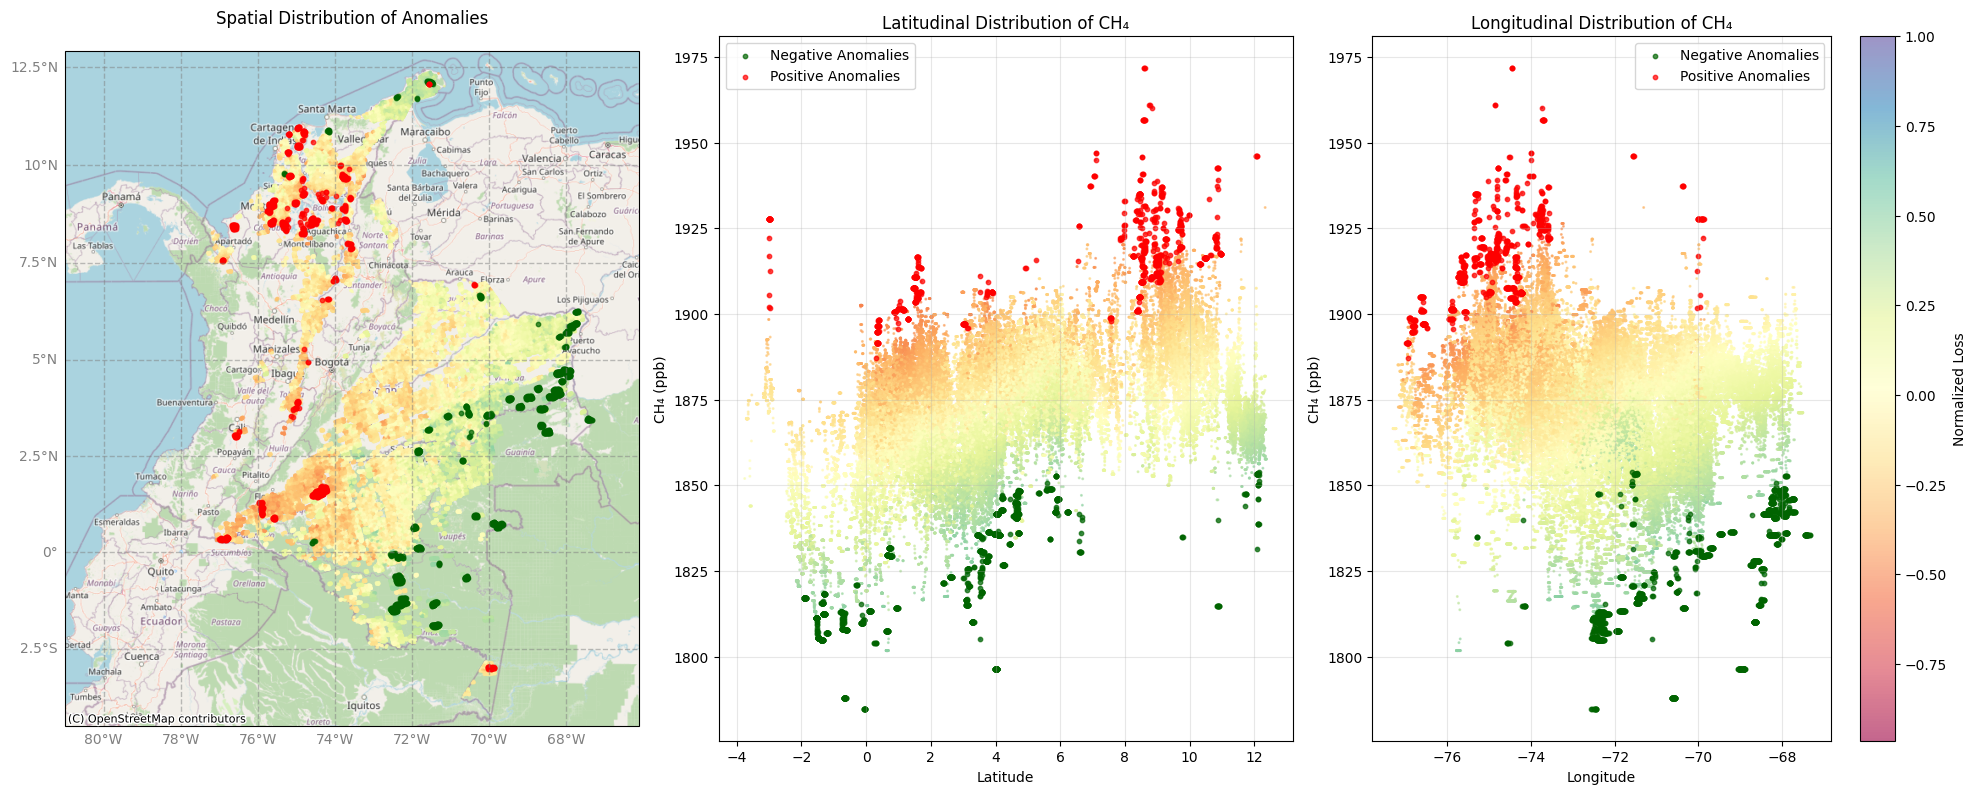

In [ ]:
def plotAnomaly(iCut, iRaw, iLoss, i_test, iLoss2, maxlosscolor=20, figsize=(20, 8),
                save_plot=False, filename='anomaly_plot.png'):
    """
    Plot anomalies in methane data with enhanced visualization and map background.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import cartopy.crs as ccrs
    import contextily as cx
    from matplotlib.gridspec import GridSpec
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

    # Prepare the data
    loss = np.minimum(iLoss2, maxlosscolor)
    anomalies = (iLoss > iCut)
    btestdata_raw = iRaw[i_test]

    # Separate positive and negative anomalies
    pos_anomaly_raw = btestdata_raw[anomalies*(iLoss2>0)]
    neg_anomaly_raw = btestdata_raw[anomalies*(iLoss2<0)]
    anomaly_raw = btestdata_raw[anomalies]

    # Normalize loss values
    loss = loss/np.max(loss)
    if maxlosscolor != 20:
        loss = np.ones(loss.shape)

    # Create figure with GridSpec
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 3, figure=fig)

    # Map plot with anomalies
    ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

    # Set map extent for Colombia
    extent = [-81, -66.1, -4.5, 12.9]
    ax1.set_extent(extent, crs=ccrs.PlateCarree())

    # Plot points on map
    scat = ax1.scatter(btestdata_raw[:,0], btestdata_raw[:,1],
                      marker='.', c=loss, cmap="Spectral",
                      transform=ccrs.PlateCarree(),
                      s=5, alpha=0.6)

    # Plot anomalies
    ax1.scatter(pos_anomaly_raw[:,0], pos_anomaly_raw[:,1],
                c='#006400', s=10, alpha=0.7,
                label='Negative Anomalies',
                transform=ccrs.PlateCarree())
    ax1.scatter(neg_anomaly_raw[:,0], neg_anomaly_raw[:,1],
                c='red', s=10, alpha=0.7,
                label='Positive Anomalies',
                transform=ccrs.PlateCarree())

    # Add basemap
    cx.add_basemap(ax1, source=cx.providers.OpenStreetMap.Mapnik)

    # Add gridlines
    gl = ax1.gridlines(crs=ccrs.PlateCarree(),
                      draw_labels=True,
                      linewidth=1,
                      color='gray',
                      alpha=0.5,
                      linestyle='--')

    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}

    # # Add legend
    # legend = ax1.legend(title='Anomalies',
    #                    loc='upper left',
    #                    bbox_to_anchor=(1.05, 1),
    # #                    markerscale=3)
    # plt.setp(legend.get_title(), fontsize=10)

    ax1.set_title('Spatial Distribution of Anomalies', pad=20)

    # Latitude-CH4 plot
    ax2 = fig.add_subplot(gs[1])
    scat2 = ax2.scatter(btestdata_raw[:,1], btestdata_raw[:,2],
                       c=loss, marker='.', cmap="Spectral",
                       s=5, alpha=0.6)
    ax2.scatter(pos_anomaly_raw[:,1], pos_anomaly_raw[:,2],
                c='#006400', s=10, alpha=0.7,
                label='Negative Anomalies')
    ax2.scatter(neg_anomaly_raw[:,1], neg_anomaly_raw[:,2],
                c='red', s=10, alpha=0.7,
                label='Positive Anomalies')
    ax2.set_xlabel("Latitude", fontsize=10)
    ax2.set_ylabel("CH₄ (ppb)", fontsize=10)
    ax2.set_title('Latitudinal Distribution of CH₄', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Longitude-CH4 plot
    ax3 = fig.add_subplot(gs[2])
    scat3 = ax3.scatter(btestdata_raw[:,0], btestdata_raw[:,2],
                       c=loss, marker='.', cmap="Spectral",
                       s=5, alpha=0.6)
    ax3.scatter(pos_anomaly_raw[:,0], pos_anomaly_raw[:,2],
                c='#006400', s=10, alpha=0.7,
                label='Negative Anomalies')
    ax3.scatter(neg_anomaly_raw[:,0], neg_anomaly_raw[:,2],
                c='red', s=10, alpha=0.7,
                label='Positive Anomalies')
    ax3.set_xlabel("Longitude", fontsize=10)
    ax3.set_ylabel("CH₄ (ppb)", fontsize=10)
    ax3.set_title('Longitudinal Distribution of CH₄', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # Add colorbar
    cbar = plt.colorbar(scat3, ax=ax3)
    cbar.set_label('Normalized Loss', fontsize=10)

    # Adjust layout
    plt.tight_layout()

    # Save plot if requested
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

    return pos_anomaly_raw, neg_anomaly_raw, anomaly_raw
# def plotAnomaly(iCut,iRaw,iLoss,i_test,iLoss2,maxlosscolor=20):
#     loss = np.minimum(iLoss2,maxlosscolor)
#     anomalies=(iLoss > iCut)

#     #baseidex=len(iRaw)-len(iLoss)
#     btestdata_raw = iRaw[i_test]
#     pos_anomaly_raw=btestdata_raw[anomalies*(iLoss2>0)]
#     neg_anomaly_raw=btestdata_raw[anomalies*(iLoss2<0)]
#     anomaly_raw  = btestdata_raw[anomalies]
#     # pos_anomaly= anomaly_raw[iLoss2>0]
#     # neg_anomaly= anomaly_raw[iLoss2<0]
#     #btestgalcen   = igalcen[baseidex:]#
#     #anomaly_galcen = btestgalcen[anomalies]#
#     #print(anomaly_raw)
#     vma=1
#     vmi=-1*vma
#     loss = loss/np.max(loss)
#     if maxlosscolor != 20:
#         loss=np.ones(loss.shape)
#     print(loss.shape,btestdata_raw[:,2].shape)
#     scat=plt.scatter(btestdata_raw[:,0],btestdata_raw[:,1], marker='.',c=loss,cmap="Spectral")
#     plt.plot(anomaly_raw[:,0],anomaly_raw[:,1], marker='.', linestyle='none',c='orange')
#     plt.xlabel('$Longitude$')
#     plt.ylabel('$Latitude$')
#     #plt.ylim(15,0)
#     #plt.xlim(1,-5)
#     plt.colorbar(scat)
#     plt.show()
#     plt.figure(figsize=(16,4))
#     plt.subplot(1,3,1)
#     scat=plt.scatter(btestdata_raw[:,0],btestdata_raw[:,1], marker='.',c=loss,cmap="Spectral", vmin=vmi, vmax=vma)
#     plt.plot(pos_anomaly_raw[:,0],pos_anomaly_raw[:,1], marker='.', linestyle='none',c='#006400')
#     plt.plot(neg_anomaly_raw[:,0],neg_anomaly_raw[:,1], marker='.', linestyle='none',c="#FF0000")
#     plt.xlabel('$Longitude$')
#     plt.ylabel('$Latitude$')
#     #plt.ylim(15,0)
#     #plt.xlim(1,-5)
#     #plt.colorbar(scat)
#     #plt.show()
#     plt.subplot(1,3,2)
#     scat=plt.scatter(btestdata_raw[:,1],btestdata_raw[:,2],c=loss, marker='.',cmap="Spectral",vmin=vmi, vmax=vma)
#     plt.plot(pos_anomaly_raw[:,1],pos_anomaly_raw[:,2], marker='.', linestyle='none',c='#006400')
#     plt.plot(neg_anomaly_raw[:,1],neg_anomaly_raw[:,2], marker='.', linestyle='none',c='red')
#     #plt.plot(anomaly_raw[:,1],anomaly_raw[:,2], marker='.', linestyle='none',c='orange')
#     plt.xlabel("$Latitude$")
#     plt.ylabel("CH4[ppb]")
#     #plt.colorbar(scat)
#     #plt.show()
#     plt.subplot(1,3,3)
#     scat=plt.scatter(btestdata_raw[:,0],btestdata_raw[:,2],c=loss, marker='.', cmap="Spectral", vmin=vmi, vmax=vma)
#     plt.plot(pos_anomaly_raw[:,0],pos_anomaly_raw[:,2], marker='.', linestyle='none',c='#006400')
#     plt.plot(neg_anomaly_raw[:,0],neg_anomaly_raw[:,2], marker='.', linestyle='none',c='red')
#     #plt.plot(anomaly_raw[:,0],anomaly_raw[:,2], marker='.', linestyle='none',c='orange')
#     plt.xlabel("$Longitude$")
#     plt.ylabel("CH4[ppb]")
#     plt.colorbar(scat)
#     plt.show()
#     return pos_anomaly_raw,neg_anomaly_raw,anomaly_raw
    # scat=plt.scatter(btestdata_raw[:,6],btestdata_raw[:,7],c=loss, marker='.', cmap="viridis")
    # plt.plot(anomaly_raw[:,6],anomaly_raw[:,7], marker='.', linestyle='none',c='orange')
    # plt.xlabel("vx[pc]")
    # plt.ylabel("vy[pc]")
    # plt.colorbar(scat)
    # plt.show()

    # scat=plt.scatter(btestdata_raw[:,6],btestdata_raw[:,8],c=loss, marker='.',cmap="viridis")
    # plt.plot(anomaly_raw[:,6],anomaly_raw[:,8], marker='.', linestyle='none')
    # plt.xlabel("vx[pc]")
    # plt.ylabel("vz[pc]")
    # plt.show()

    # print(len(btestdata_raw),len(iRaw),len(igalcen),len(btestgalcen))
    # H = gp.Hamiltonian(milky_way)
    # w0_anom = gd.PhaseSpacePosition(anomaly_galcen.cartesian)
    # orbits_anom = H.integrate_orbit(w0_anom, dt=1*u.Myr, t1=0*u.Myr, t2=100*u.Myr)
    # w0_all  = gd.PhaseSpacePosition(bgalcen_clean[1==1].cartesian)
    # orbits_all  = H.integrate_orbit(w0_all,  dt=1*u.Myr, t1=0*u.Myr, t2=100*u.Myr)

    # zmax_all = orbits_all.zmax(approximate=True)
    # zmax_anom = orbits_anom.zmax(approximate=True)
    # print("ZMax mean:",zmax_anom[~np.isnan(zmax_anom.value)].mean(),len(zmax_anom),"default:",zmax_all.mean())
    # bins = np.linspace(0, 10, 50)
    # plt.hist(zmax_all.value, bins=bins, alpha=0.4, density=True, label='all')
    # plt.hist(zmax_anom.value, bins=bins, alpha=0.4, density=True, label='anom')
    # plt.legend(loc='best', fontsize=14)
    # plt.yscale('log')
    # plt.xlabel(r" zmax" + " [{0:latex}]".format(zmax_all.unit))
    # plt.show()

    # zmax_all  = orbits_all.eccentricity()
    # zmax_anom = orbits_anom.eccentricity()
    # print("Ecc mean:",zmax_anom[~np.isnan(zmax_anom.value)].mean(),len(zmax_anom),"default:",zmax_all.mean())
    # bins = np.linspace(0, 3, 50)
    # plt.hist(zmax_all.value,  bins=bins, alpha=0.4, density=True, label='all')
    # plt.hist(zmax_anom.value, bins=bins, alpha=0.4, density=True, label='anom')
    # plt.legend(loc='best', fontsize=14)
    # plt.yscale('log')
    # plt.xlabel('Eccentricity')
    # plt.show()
# cutoff 20 whole average, 14 prom 2020
btestloss2=torch.sum((btestset-boutput)**1,axis=1)
positive_anomaly,negative_anomaly,anomaly=plotAnomaly(14,bprocessed_data_raw,btestloss.detach().numpy(),index_test,btestloss2.detach().numpy())#,bgalcen_clean)

In [ ]:
#Relacionar con el uso de la tierra en puntos anomalos
encoded_df45=encoded_df[~((encoded_df['Leyenda_1_4. Wet areas']>0)+(encoded_df['Leyenda_1_5. Water surfaces']>0))]
#encoded_df45=encoded_df[encoded_df['Leyenda_3_1.3.1. Zonas de extracción minera']>0]
#encoded_df45=encoded_df.copy()

In [ ]:
#encoded_df.geometry.intersects(positive_anomaly)
# This will return a boolean Series
for i in range(len(positive_anomaly)):
  is_within = encoded_df45.geometry.contains(Point(positive_anomaly[i,0], positive_anomaly[i,1]))
  encoded_df45.loc[is_within,'groupb']=1
# encoded_df2=encoded_df45.copy()
# encoded_df2['groupb']=0
for i in range(len(negative_anomaly)):
  is_within = encoded_df45.geometry.contains(Point(negative_anomaly[i,0], negative_anomaly[i,1]))
  encoded_df45.loc[is_within,'groupb']=2
#encoded_df2[encoded_df2['groupb']==1].geometry
#encoded_df45[encoded_df45['groupb']==1].geometry

KeyboardInterrupt: 

In [ ]:
l_in=list(encoded_df45.columns)
pos_level3=encoded_df45[encoded_df45['groupb']==1].groupby('groupb')[l_in[25:-6]].aggregate('sum')
pos_level1=encoded_df45[encoded_df45['groupb']==1].groupby('groupb')[l_in[-6:-3]].aggregate('sum')
#matching_polygons = gpd.sjoin(gdf, points_gdf, predicate='contains')
neg_level3=encoded_df45[encoded_df45['groupb']==2].groupby('groupb')[l_in[25:-6]].aggregate('sum')
neg_level1=encoded_df45[encoded_df45['groupb']==2].groupby('groupb')[l_in[-6:-3]].aggregate('sum')

In [ ]:
# plt.figure(figsize=(15,15))
# plt.subplot(3,3,1)
# pos_rel=pos_level1>0
# pos_columns=pos_level1.columns[pos_rel.iloc[0]]
# pos_level1=pos_level1[pos_columns]
# patches, texts, autotexts = plt.pie(pos_level1.iloc[0],
#                                   labels=[''] * len(pos_level1.columns),  # Remove direct labels
#                                   autopct='%1.1f%%',
#                                   colors=['#ff7f0e', '#2ca02c'],
#                                   startangle=90)
# # plt.legend(patches, pos_level1.columns,
# #           title="Categories",
# #           loc="center left",
# #           bbox_to_anchor=(1, 0, 0.5, 1))  # Place legend to the right
# plt.title('Positive anormal points')
# plt.axis('equal')
# plt.subplot(3,1,1)
# patches, texts, autotexts = plt.pie(neg_level1.iloc[0],
#                                   labels=[''] * len(neg_level1.columns),  # Remove direct labels
#                                   autopct='%1.1f%%',
#                                   startangle=90)
# plt.legend(patches, [i[10:] for i in neg_level1.columns],
#           title="Categories",
#           loc="center left",
#           bbox_to_anchor=(0.7, 0, 0.5, 1))  # Place legend to the right
# plt.title('Negative anormal points ')
# plt.axis('equal')
# plt.show()
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Set publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 15,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (15, 8),
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

# Create figure
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

# First pie chart (positive anomalies)
ax1 = fig.add_subplot(gs[0])
pos_rel = pos_level1 > 1
pos_columns = pos_level1.columns[pos_rel.iloc[0]]
pos_level1_filtered = pos_level1[pos_columns]

# Professional color palette
colors = ['#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377']

wedges, texts, autotexts = ax1.pie(
    pos_level1_filtered.iloc[0],
    autopct='%1.1f%%',
    colors=colors[1:len(pos_columns)+1],
    startangle=90,
    wedgeprops={'edgecolor': 'w', 'linewidth': 1}
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add legend with clean category names
# ax1.legend(
#     wedges,
#     [col.replace('_', ' ').title() for col in pos_columns],
#     title="Positive Anomaly Categories",
#     loc="center left",
#     bbox_to_anchor=(1, 0.5)
# )
ax1.set_title('Distribution of Positive Anomalies', fontweight='bold')

# Second pie chart (negative anomalies)
ax2 = fig.add_subplot(gs[1])
wedges, texts, autotexts = ax2.pie(
    neg_level1.iloc[0],
    autopct='%1.1f%%',
    colors=colors[:len(neg_level1.columns)],
    startangle=90,
    wedgeprops={'edgecolor': 'w', 'linewidth': 1}
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Clean up category names by removing prefix
clean_labels = [col[10:].replace('_', ' ').title() if col.startswith('neg_level1')
                else col[10:].replace('_', ' ').title() for col in neg_level1.columns]

ax2.legend(
    wedges,
    clean_labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax2.set_title('Distribution of Negative Anomalies', fontweight='bold')

# Add overall figure title
#fig.suptitle('Anomaly Classification Analysis', fontsize=18, fontweight='bold', y=0.98)

# Save figure
plt.savefig('anomaly_classification.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# print("Default color cycle:", default_colors)

In [ ]:
total=pos_level3.iloc[0].sum()
pos_rel=pos_level3/total*100>0
pos_columns=pos_level3.columns[pos_rel.iloc[0]]
pos_level3=pos_level3[pos_columns]
pos_level3=pos_level3[pos_rel]
pos_rel=pos_level3/total*100>0
l=pos_level3/total*100
l.iloc[0].sort_values()

In [ ]:
# pos_rel=pos_level3/total*100>3
# pos_columns=pos_level3.columns[pos_rel.iloc[0]]
# pos_level3=pos_level3[pos_columns]
# pos_level3=pos_level3[pos_rel]
# #neg_level3=neg_level3.sort_values(by=0)
# others=total-pos_level3[pos_rel].iloc[0].sum()
# pos_level3_graph=pos_level3.iloc[0].sort_values().to_numpy()
# index=np.concatenate((np.array(['Others']),np.array([i[10:] for i in pos_level3.iloc[0].sort_values().index])))
# plt.figure(figsize=(10, 8))
# patches, texts, autotexts =plt.pie(np.concatenate((np.array([others]),pos_level3_graph)),  # Get the first (and only) row
#         labels=index,#[''] * len(pos_level3.columns),
#         autopct='%1.1f%%',  # Show percentages
#         startangle=90)
# plt.title('Positive anormal points by land use on level 3  ')
# # plt.legend(patches, pos_level3.iloc[0].sort_values().index,
# #           title="Categories",
# #           loc="center left",
# #           bbox_to_anchor=(1, 0, 0.5, 1))  # Place legend to the right
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# plt.show()

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.figsize': (10, 8),
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

# Process data
pos_rel = pos_level3/total*100 > 3
pos_columns = pos_level3.columns[pos_rel.iloc[0]]
pos_level3_filtered = pos_level3[pos_columns]
pos_level3_filtered = pos_level3_filtered[pos_rel]

# Calculate "Others" category
others = total - pos_level3_filtered.iloc[0].sum()

# Sort values for better visualization
pos_level3_graph = pos_level3_filtered.iloc[0].sort_values().to_numpy()
index = np.concatenate((np.array(['Others']),
                        np.array([i[10:].replace('_', ' ').title() for i in
                                 pos_level3_filtered.iloc[0].sort_values().index])))

# Set up figure
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Color palette - colorblind friendly
colors = ['#DDDDDD', '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377']

# Create pie chart
wedges, texts, autotexts = ax.pie(
    np.concatenate((np.array([others]), pos_level3_graph)),
    labels=None,  # We'll use a legend instead
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(index)],
    wedgeprops={'edgecolor': 'w', 'linewidth': 1},
    pctdistance=0.85
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Add legend with clean category names
ax.legend(
    wedges,
    index,
    title="Land Use Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True,
    framealpha=0.9,
    edgecolor='black'
)

# Add title with proper formatting
ax.set_title('Distribution of Positive Anomalies by Land Use (Level 3)',
             fontweight='bold', pad=20)

# Add footnote for methodology
plt.annotate('Note: Only categories representing >3% of total area are shown individually',
             xy=(0.5, -0.05), xycoords='axes fraction',
             ha='center', va='center', fontsize=10, fontstyle='italic')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Save figure
plt.savefig('land_use_anomalies.pdf', bbox_inches='tight')
plt.show()


In [ ]:
total=neg_level3.iloc[0].sum()
neg_rel=neg_level3/total*100>0
neg_columns=neg_level3.columns[neg_rel.iloc[0]]
neg_level3=neg_level3[neg_columns]
neg_level3=neg_level3[neg_rel]
neg_rel=neg_level3/total*100>0
l=neg_level3/total*100
l.iloc[0].sort_values()

In [ ]:
# neg_rel=neg_level3/total*100>2.3
# neg_columns=neg_level3.columns[neg_rel.iloc[0]]
# neg_level3=neg_level3[neg_columns]
# neg_level3=neg_level3[neg_rel]
# #neg_level3=neg_level3.sort_values(by=0)
# others=total-neg_level3[neg_rel].iloc[0].sum()
# neg_level3_graph=neg_level3.iloc[0].sort_values().to_numpy()
# index=np.concatenate((np.array(['Others']),np.array([i[10:] for i in neg_level3.iloc[0].sort_values().index])))
# plt.figure(figsize=(10, 8))
# patches, texts, autotexts =plt.pie(np.concatenate((np.array([others]),neg_level3_graph)),  # Get the first (and only) row
#         labels=index,#[''] * len(pos_level3.columns),
#         autopct='%1.1f%%',  # Show percentages
#         startangle=90)
# plt.title('Negative anormal points by land use on level 3  ')
# # plt.legend(patches, pos_level3.iloc[0].sort_values().index,
# #           title="Categories",
# #           loc="center left",
# #           bbox_to_anchor=(1, 0, 0.5, 1))  # Place legend to the right
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# plt.show()
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.figsize': (10, 8),
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

# Process data
neg_rel = neg_level3/total*100 > 4
neg_columns = neg_level3.columns[neg_rel.iloc[0]]
neg_level3_filtered = neg_level3[neg_columns]
neg_level3_filtered = neg_level3_filtered[neg_rel]

# Calculate "Others" category
others = total - neg_level3_filtered.iloc[0].sum()

# Sort values for better visualization
neg_level3_graph = neg_level3_filtered.iloc[0].sort_values().to_numpy()
index = np.concatenate((np.array(['Others']),
                        np.array([i[10:].replace('_', ' ').title() for i in
                                  neg_level3_filtered.iloc[0].sort_values().index])))

# Set up figure
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

# Color palette - use reds for negative anomalies (diverging from blue in positive chart)
colors = ['#DDDDDD', '#8B0000', '#A52A2A', '#CD5C5C', '#E9967A', '#F08080', '#FA8072', '#FF0000']  # Added Pure Red

# Create pie chart
wedges, texts, autotexts = ax.pie(
    np.concatenate((np.array([others]), neg_level3_graph)),
    labels=None,  # We'll use a legend instead
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(index)],
    wedgeprops={'edgecolor': 'w', 'linewidth': 1},
    pctdistance=0.85
)

# Customize text appearance
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# Add legend with clean category names
ax.legend(
    wedges,
    index,
    title="Land Use Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True,
    framealpha=0.9,
    edgecolor='black'
)

# Add title with proper formatting
ax.set_title('Distribution of Negative Anomalies by Land Use (Level 3)',
             fontweight='bold', pad=20)

# Add footnote for methodology
plt.annotate('Note: Only categories representing >2.3% of total area are shown individually',
             xy=(0.5, -0.05), xycoords='axes fraction',
             ha='center', va='center', fontsize=10, fontstyle='italic')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Save figure
plt.savefig('negative_land_use_anomalies.pdf', bbox_inches='tight')
plt.show()

# 9. Suplemental — código histórico
Se debe correr la sección alistamiento de datos hastala línea donde se carga df_s y se muestra un mapa

> **No forma parte del pipeline y no corre.** 11 de sus 47 celdas apuntan a rutas
> de Google Colab que no existen en disco, y varias dependen de variables
> (`encoded_df`, `df_s`, `df_completo`) que se definían en el bloque legado de 2020
> ya eliminado. Se conserva por el trabajo de media anual insesgada
> (`compute_unbiased`), que sí es relevante y habría que rescatar a una sección propia.

In [ ]:
encoded_df = get_areas(encoded_df)

C:\Users\jolej\AppData\Local\Temp\ipykernel_11948\906446406.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  encoded_df['SHAPE_Area'] = encoded_df.geometry.area


In [ ]:
encoded_df45=encoded_df[(encoded_df['Leyenda_1_4. Wetlands']>0)+(encoded_df['Leyenda_1_5. Water bodies']>0)]#tabla para eliminar el glint en la plataforma continental

In [ ]:
encoded_df45

,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,nivel_4,...,Leyenda_3_5.1.4. Artificial water bodies,Leyenda_3_5.2.1. Coastal lagoons,Leyenda_3_5.2.2. Seas and oceans,Leyenda_3_5.2.3. Ponds for marine aquaculture,Leyenda_1_1. Urbanized areas,Leyenda_1_2. Agricultural lands,Leyenda_1_3. Forests and semi-natural areas,Leyenda_1_4. Wetlands,Leyenda_1_5. Water bodies,groupb
159,522,5.2.2. Mares y océanos,Mosaico_Medianas_Sentinel2_2022_SanAndres10m_C...,GoogleEarth,SI,1,5. Superficies de agua,5.2. Aguas marítimas,5.2.2. Mares y océanos,NaN,...,False,False,True,False,False,False,False,False,True,0
160,522,5.2.2. Mares y océanos,Mosaico_Medianas_Sentinel2_2022_SanAndres10m_C...,GoogleEarth,SI,1,5. Superficies de agua,5.2. Aguas marítimas,5.2.2. Mares y océanos,NaN,...,False,False,True,False,False,False,False,False,True,0
161,522,5.2.2. Mares y océanos,Mosaico_Medianas_Sentinel2_2022_SanAndres10m_C...,GoogleEarth,SI,1,5. Superficies de agua,5.2. Aguas marítimas,5.2.2. Mares y océanos,NaN,...,False,False,True,False,False,False,False,False,True,0
162,522,5.2.2. Mares y océanos,Mosaico_Medianas_Sentinel2_2022_SanAndres10m_C...,GoogleEarth,SI,1,5. Superficies de agua,5.2. Aguas marítimas,5.2.2. Mares y océanos,NaN,...,False,False,True,False,False,False,False,False,True,0
163,522,5.2.2. Mares y océanos,Mosaico_Medianas_Sentinel2_2022_SanAndres10m_C...,GoogleEarth,SI,1,5. Superficies de agua,5.2. Aguas marítimas,5.2.2. Mares y océanos,NaN,...,False,False,True,False,False,False,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520975,512,"5.1.2. Lagunas, lagos y ciénagas naturales",Landsat_2022_mediana_09032023,"GoogleMaps,GoogleEarth",SI,2,5. Superficies de agua,5.1. Aguas continentales,"5.1.2. Lagunas, lagos y ciénagas naturales",NaN,...,False,False,False,False,False,False,False,False,True,0
520977,411,4.1.1. Zonas pantanosas,Landsat_2022_mediana_09032023,"GoogleMaps,GoogleEarth",SI,2,4. Áreas húmedas,4.1. Áreas húmedas continentales,4.1.1. Zonas pantanosas,NaN,...,False,False,False,False,False,False,False,True,False,0
520978,411,4.1.1. Zonas pantanosas,Landsat_2022_mediana_09032023,"GoogleMaps,GoogleEarth",SI,2,4. Áreas húmedas,4.1. Áreas húmedas continentales,4.1.1. Zonas pantanosas,NaN,...,False,False,False,False,False,False,False,True,False,0
521157,512,"5.1.2. Lagunas, lagos y ciénagas naturales",Landsat_2022_mediana_09032023,"GoogleMaps,GoogleEarth",SI,2,5. Superficies de agua,5.1. Aguas continentales,"5.1.2. Lagunas, lagos y ciénagas naturales",NaN,...,False,False,False,False,False,False,False,False,True,0


In [ ]:
#df_g es el promedio de todos los año filtrado sin cuerpo de agua para evitar el glint
#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv')
df_s=pd.read_csv(r'descarga de datos\csvResults\CH4_full.csv')
#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020
#df_g=df_s[df_s['Leyenda_1_4. Áreas húmedas'].isnull()+df_s['Leyenda_1_5. Superficies de agua'].isnull()]#.plot(x='longitude',y='latitude',column='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')
#sns.scatterplot(data=df_g,x='longitude',y='latitude',s=0.5)#,hue='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')
#df_g.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/glint_intersect_filtered.csv')
#df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020.csv')
#df_g=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/glint_intersect_filtered.csv')
sns.scatterplot(data=df_s,x='longitude',y='latitude',s=0.5)
df_s

OSError: [Errno 22] Invalid argument: 'descarga de datos\\csvResults\\CH4_full.csv'

In [ ]:
encoded_df45.geometry.crs

<Geographic 2D CRS: EPSG:4686>
Name: MAGNA-SIRGAS
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Datum: Marco Geocentrico Nacional de Referencia
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
from pathlib import Path
from shapely.geometry import box

# --- Step 1: Build water/wetland GeoDataFrame ONCE ---
# Filter encoded_df to only water/wetland rows upfront
# water_mask = (
#     (encoded_df['Leyenda_1_4. Áreas húmedas'] > 0) |
#     (encoded_df['Leyenda_1_5. Superficies de agua'] > 0)
# )
# encoded_df45 = encoded_df[water_mask].copy()

# Weighted land cover columns
l_in = list(encoded_df45.columns)
while l_in[0] != 'Leyenda_3_1.1.1. Continuous urban fabric':
    l_in.pop(0)
if 'groupb' in l_in:
    l_in.remove('groupb')

for col in l_in:
    encoded_df45[col] = encoded_df[col] * encoded_df['area_m2']

# Build water geometries as boxes — vectorized, no apply()
delta = 0.01
water_gdf = gpd.GeoDataFrame(
    encoded_df45,
    geometry=encoded_df45['geometry'],  # already exists in encoded_df45
    crs='EPSG:4686'
)
print(f"Water/wetland polygons: {len(water_gdf):,}")

# --- Step 2: Load CH4 data in chunks and filter via spatial join ---
INPUT_CSV  = Path('descarga de datos/csvResults') / 'CH4_full.csv'
OUTPUT_CSV = Path('datos_csv/datos corregidos') / 'colombia_2024-2026_filtered.csv'
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

CHUNK_SIZE = 50_000
write_header = True
total_in  = 0
total_out = 0

# Build spatial index on water polygons ONCE outside the loop
# geopandas uses STRtree internally — extremely fast intersection queries
water_sindex = water_gdf.sindex

for chunk in pd.read_csv(INPUT_CSV, chunksize=CHUNK_SIZE):
    total_in += len(chunk)

    # Vectorized geometry creation — no apply(lambda)
    chunk_geom = gpd.GeoDataFrame(
        chunk,
        geometry=gpd.points_from_xy(chunk['longitude'], chunk['latitude']),
        crs='EPSG:4686'
    )

    # Spatial index query — finds candidate matches in bulk
    # Much faster than row-by-row intersects()
    possible_matches_idx = list(water_sindex.query(
        chunk_geom.geometry.union_all(),
        predicate='intersects'
    ))
    possible_water = water_gdf.iloc[possible_matches_idx]

    if len(possible_water) > 0:
        # Precise intersection only on candidates — not all rows
        joined = gpd.sjoin(
            chunk_geom,
            possible_water[['geometry']],
            how='left',
            predicate='intersects'
        )
        # Keep rows that did NOT intersect any water polygon
        filtered = chunk[joined['index_right'].isna()]
    else:
        filtered = chunk  # no water in this chunk's area

    filtered.to_csv(OUTPUT_CSV, mode='a', header=write_header, index=False)
    write_header = False
    total_out += len(filtered)

    print(f"  processed {total_in:,} rows — kept {total_out:,} — removed {total_in - total_out:,}")

print(f"\n✓ Done: {total_in:,} → {total_out:,} rows ({total_in - total_out:,} removed)")

Water/wetland polygons: 43,793
  processed 50,000 rows — kept 50,000 — removed 0
  processed 100,000 rows — kept 100,000 — removed 0
  processed 150,000 rows — kept 150,000 — removed 0
  processed 200,000 rows — kept 200,000 — removed 0
  processed 250,000 rows — kept 250,000 — removed 0
  processed 300,000 rows — kept 300,000 — removed 0
  processed 350,000 rows — kept 350,000 — removed 0
  processed 400,000 rows — kept 399,999 — removed 1
  processed 450,000 rows — kept 449,993 — removed 7
  processed 500,000 rows — kept 499,993 — removed 7
  processed 550,000 rows — kept 549,993 — removed 7
  processed 600,000 rows — kept 599,993 — removed 7
  processed 650,000 rows — kept 649,993 — removed 7
  processed 700,000 rows — kept 699,993 — removed 7
  processed 750,000 rows — kept 749,993 — removed 7
  processed 800,000 rows — kept 799,993 — removed 7
  processed 850,000 rows — kept 849,993 — removed 7
  processed 900,000 rows — kept 899,993 — removed 7
  processed 950,000 rows — kept 949

In [ ]:
df_f=pd.read_csv(OUTPUT_CSV)
sns.scatterplot(data=df_f,x='longitude',y='latitude',s=0.5)

OSError: [Errno 22] Invalid argument: 'datos_csv\\datos corregidos\\colombia_2024-2026_filtered.csv'

In [ ]:
df_s['coordinate_x']=df_s['longitude'].apply(lambda x: [x])
df_s['coordinate_y']=df_s['latitude'].apply(lambda x: [x])
df_s['coordinates']=df_s['coordinate_x']+df_s['coordinate_y']
delta_y=0.01
delta_x=0.01
df_s['geometry'] = df_s['coordinates'].apply(
    lambda x: Polygon([
        (x[0] - delta_x, x[1] - delta_y),
        (x[0] - delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] - delta_y)
    ]))# Corregir el delta
df_s

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry
0,-77.305,7.745,1.606068e+12,1866.559650,[-77.305],[7.745],"[-77.305, 7.745]","POLYGON ((-77.31500000000001 7.735, -77.315000..."
1,-77.305,7.755,1.606068e+12,1866.559615,[-77.305],[7.755],"[-77.305, 7.755]","POLYGON ((-77.31500000000001 7.745, -77.315000..."
2,-77.295,7.705,1.606068e+12,1866.559567,[-77.295],[7.705],"[-77.295, 7.705]","POLYGON ((-77.305 7.695, -77.305 7.715, -77.28..."
3,-77.295,7.715,1.606068e+12,1866.559602,[-77.295],[7.715],"[-77.295, 7.715]","POLYGON ((-77.305 7.705, -77.305 7.725, -77.28..."
4,-77.295,7.725,1.606068e+12,1866.559608,[-77.295],[7.725],"[-77.295, 7.725]","POLYGON ((-77.305 7.715, -77.305 7.73499999999..."
...,...,...,...,...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421,[-67.325],[3.455],"[-67.325, 3.455]",POLYGON ((-67.33500000000001 3.445000000000000...
307151,-67.315,3.375,1.580923e+12,1851.070163,[-67.315],[3.375],"[-67.315, 3.375]","POLYGON ((-67.325 3.365, -67.325 3.385, -67.30..."
307152,-67.315,3.385,1.580923e+12,1851.070189,[-67.315],[3.385],"[-67.315, 3.385]","POLYGON ((-67.325 3.375, -67.325 3.39499999999..."
307153,-67.315,3.435,1.577987e+12,1835.456439,[-67.315],[3.435],"[-67.315, 3.435]","POLYGON ((-67.325 3.4250000000000003, -67.325 ..."


In [ ]:
l_in=list(encoded_df45.columns)
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in.remove('groupb')
for i in l_in:
    encoded_df45[i]=encoded_df[i]*encoded_df['area_m2']
#df_s.loc[:,l_in]=None
#df_s['Leyenda_1_4. Áreas húmedas'][0]

/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [ ]:
#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered_pausa_349827.csv')


In [ ]:
# for j in df_s.index:
#     #print(j)
#     f=encoded_df45[df_s['geometry'][j].intersects(encoded_df45['geometry'])]
#     f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
#     if not len(f1)==0:
#       for i in l_in:
#         df_s.loc[j, i]=f1[i].iloc[0].copy()
#     if j%5e4==0:
#       print(j)
listind=[]
for j in encoded_df45.index:
    f=df_s[encoded_df45['geometry'][j].intersects(df_s['geometry'])]
    #f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
    #listind.append(f.index)
    df_s.drop(f.index,inplace=True)
    #

#df_sfil=df_s[~listind]
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_2024-2026_filtered.csv')
#correr hasta acá

In [ ]:
# listindc=listind[0]
# for i in range(1,len(listind)):
#   #listindc=listindc.append(listind[i])
#   try:
#     df_s.drop(listind[i],inplace=True)
#   except: KeyError
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')

<Axes: xlabel='longitude', ylabel='latitude'>

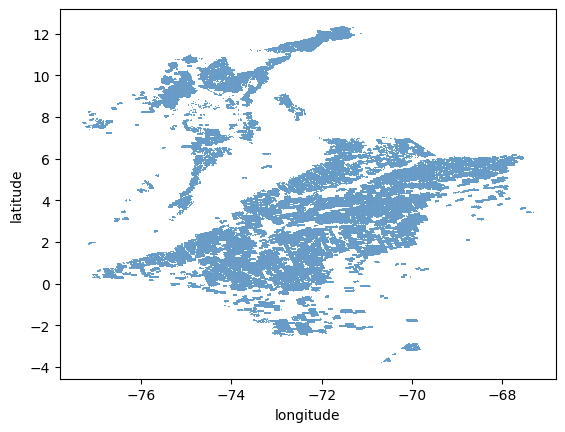

In [ ]:
sns.scatterplot(data=df_s,x='longitude',y='latitude',s=0.5)

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-77.305,7.745,1.606068e+12,1866.559650
1,-77.305,7.755,1.606068e+12,1866.559615
2,-77.295,7.705,1.606068e+12,1866.559567
3,-77.295,7.715,1.606068e+12,1866.559602
4,-77.295,7.725,1.606068e+12,1866.559608
...,...,...,...,...
307132,-67.365,3.445,1.577987e+12,1835.456421
307135,-67.355,3.435,1.577987e+12,1835.456433
307150,-67.325,3.455,1.577987e+12,1835.456421
307153,-67.315,3.435,1.577987e+12,1835.456439


In [ ]:
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')


In [ ]:
df_g=df_s[df_s['Leyenda_1_5. Superficies de agua'].isnull()+df_s['Leyenda_1_5. Superficies de agua'].isnull()]

<Axes: xlabel='longitude', ylabel='latitude'>

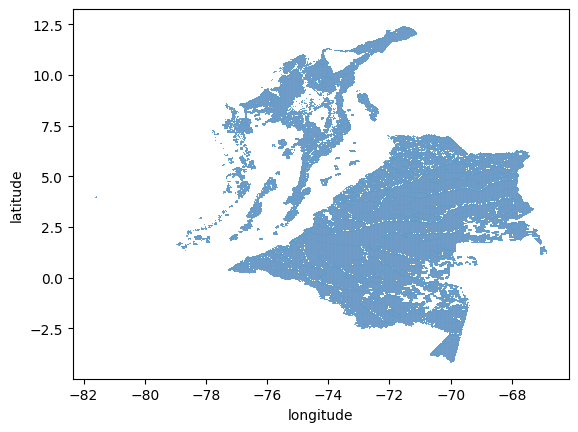

In [ ]:
sns.scatterplot(data=df_g,x='longitude',y='latitude',s=0.5)#,hue='label',s=1,palette=sns.color_palette("tab10"))

In [ ]:
df_g.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv')

In [ ]:
df_g.dtypes.head(60)

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
latitude,float64
longitude,float64
time,float64
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,float64
coordinate_x,object
coordinate_y,object
coordinates,object
geometry,object


In [ ]:
#Correr desde acá 11/11/24
df_g=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_filtered.csv')
df_g['coordinate_x']=df_g['longitude'].apply(lambda x: [x])
df_g['coordinate_y']=df_g['latitude'].apply(lambda x: [x])
df_g['coordinates']=df_g['coordinate_x']+df_g['coordinate_y']
df_g
df_g.coordinates

,coordinates
0,"[-69.995, -4.165]"
1,"[-70.005, -4.155]"
2,"[-69.965, -4.135]"
3,"[-69.955, -4.135]"
4,"[-69.94500000000001, -4.135]"
...,...
494249,"[-71.58500000000001, 12.415]"
494250,"[-71.575, 12.415]"
494251,"[-71.605, 12.425]"
494252,"[-71.595, 12.425]"


In [ ]:
df_completo=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_corrected.csv')
df_completo

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28


/home/hernan/colombian_case_methane_analysis-/.venv/lib/python3.11/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(
/home/hernan/colombian_case_methane_analysis-/.venv/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'ECOSISTEMAS_18062025.gpkg': 'e_cobertura_tierra_2022_admin' (default), 'e_cobertura_tierra_2022_amb'. Specify layer parameter to avoid this warning.
  result = read_func(


Testing 27 pixels (25 with data, 2 without)

✓ Pixel (-71.3650, 6.0450)
   Stored sum:     4.9951  |  Recomputed sum: 4.9951
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.6650  stored=0.6650
     ✓ Leyenda_3_3.2.1. Herbazal                     recomputed=0.6650  stored=0.6650
     ✓ Leyenda_6_3.2.1.1.2.1. Herbazal denso inundab recomputed=0.6650  stored=0.6650
     ✓ Leyenda_5_3.2.1.1.2. Herbazal denso inundable recomputed=0.6650  stored=0.6650
     ✓ Leyenda_4_3.2.1.1. Herbazal denso             recomputed=0.6650  stored=0.6650
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.6650  stored=0.6650
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.3350  stored=0.3350
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.3346  stored=0.3346
     ✓ Leyenda_3_2.3.3. Pastos enmalezados           recomputed=0.2776  stored=0.2776
     ✓ Leyenda_3_2.3.1. Pastos limp

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


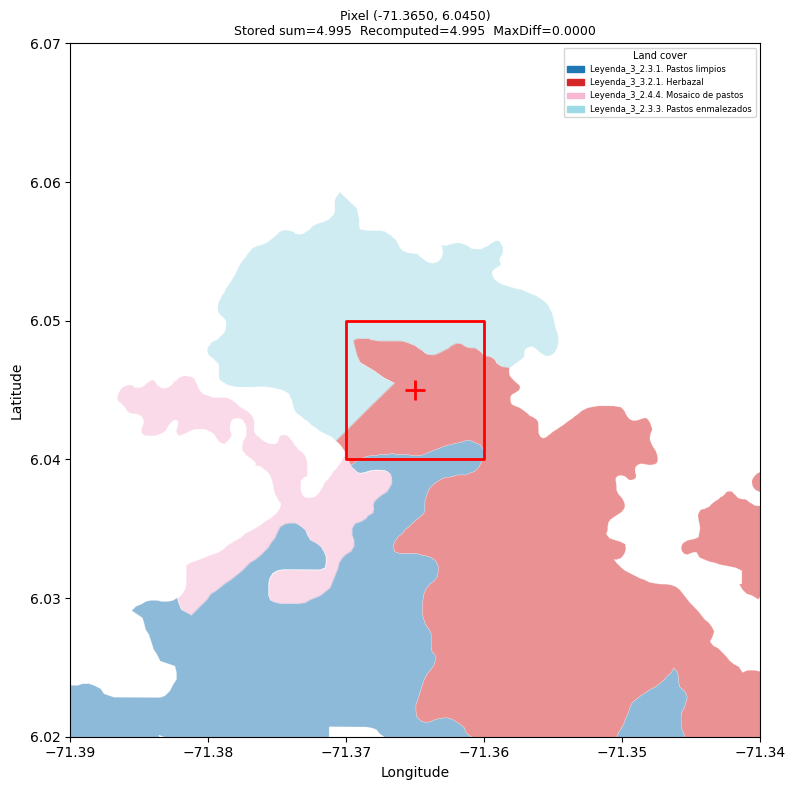


✓ Pixel (-72.7250, 8.5150)
   Stored sum:     3.8974  |  Recomputed sum: 3.8974
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=1.0000  stored=1.0000
     ✓ Leyenda_3_2.2.3. Cultivos permanentes arbóreo recomputed=0.8974  stored=0.8974
     ✓ Leyenda_2_2.2. Cultivos permanentes           recomputed=0.8974  stored=0.8974
     ✓ Leyenda_4_2.2.3.2. Palma de aceite            recomputed=0.8974  stored=0.8974
     ✓ Leyenda_3_2.4.3. Mosaico de cultivos, pastos  recomputed=0.1026  stored=0.1026
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.1026  stored=0.1026


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


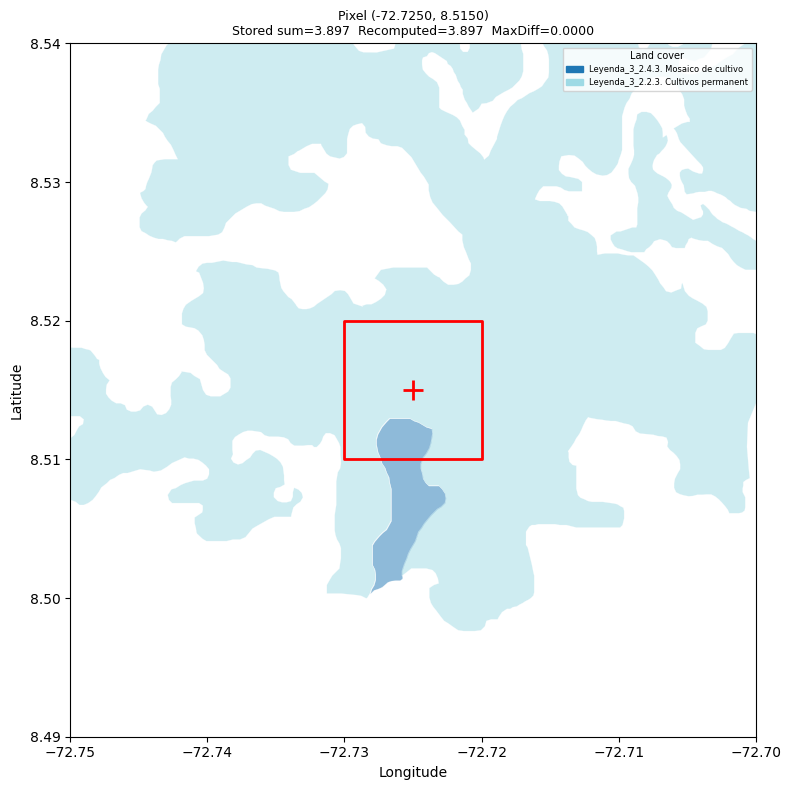


✓ Pixel (-69.9550, 5.5750)
   Stored sum:     4.2093  |  Recomputed sum: 4.2093
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.6868  stored=0.6868
     ✓ Leyenda_4_3.2.1.1. Herbazal denso             recomputed=0.4031  stored=0.4031
     ✓ Leyenda_3_3.2.1. Herbazal                     recomputed=0.4031  stored=0.4031
     ✓ Leyenda_6_3.2.1.1.2.1. Herbazal denso inundab recomputed=0.4031  stored=0.4031
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.4031  stored=0.4031
     ✓ Leyenda_5_3.2.1.1.2. Herbazal denso inundable recomputed=0.4031  stored=0.4031
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.3132  stored=0.3132
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.3132  stored=0.3132
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.3132  stored=0.3132
     ✓ Leyenda_3_3.1.4. Bosque de galería y ripario  recomputed=0.2837  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


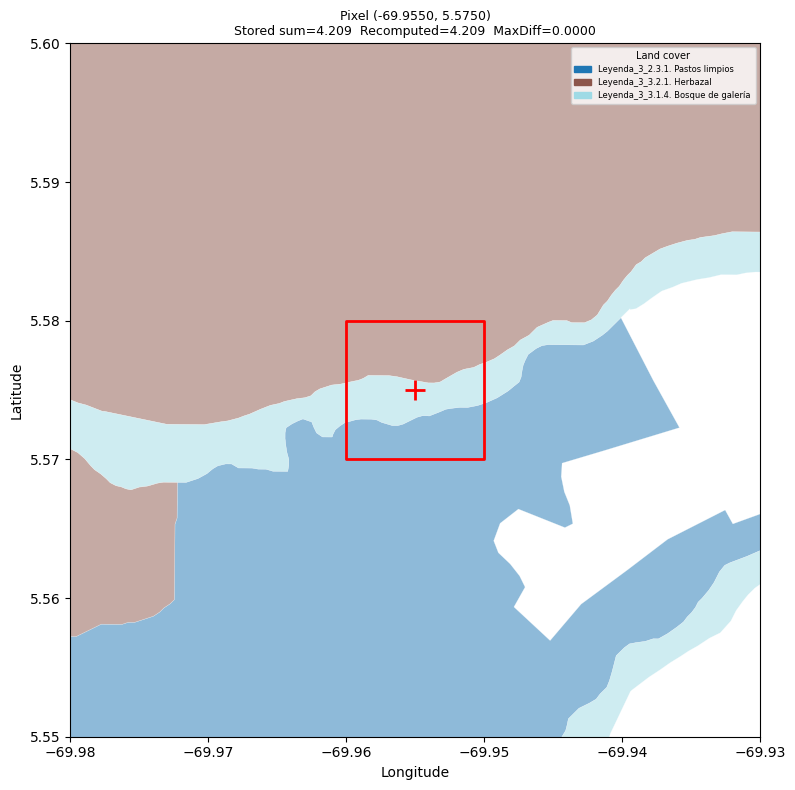


✓ Pixel (-72.1550, 3.6150)
   Stored sum:     5.9858  |  Recomputed sum: 5.9858
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=1.0000  stored=1.0000
     ✓ Leyenda_3_3.2.1. Herbazal                     recomputed=0.9953  stored=0.9953
     ✓ Leyenda_4_3.2.1.1. Herbazal denso             recomputed=0.9953  stored=0.9953
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.9953  stored=0.9953
     ✓ Leyenda_5_3.2.1.1.1. Herbazal denso de tierra recomputed=0.9953  stored=0.9953
     ✓ Leyenda_6_3.2.1.1.1.1.  Herbazal denso de tie recomputed=0.9953  stored=0.9953


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


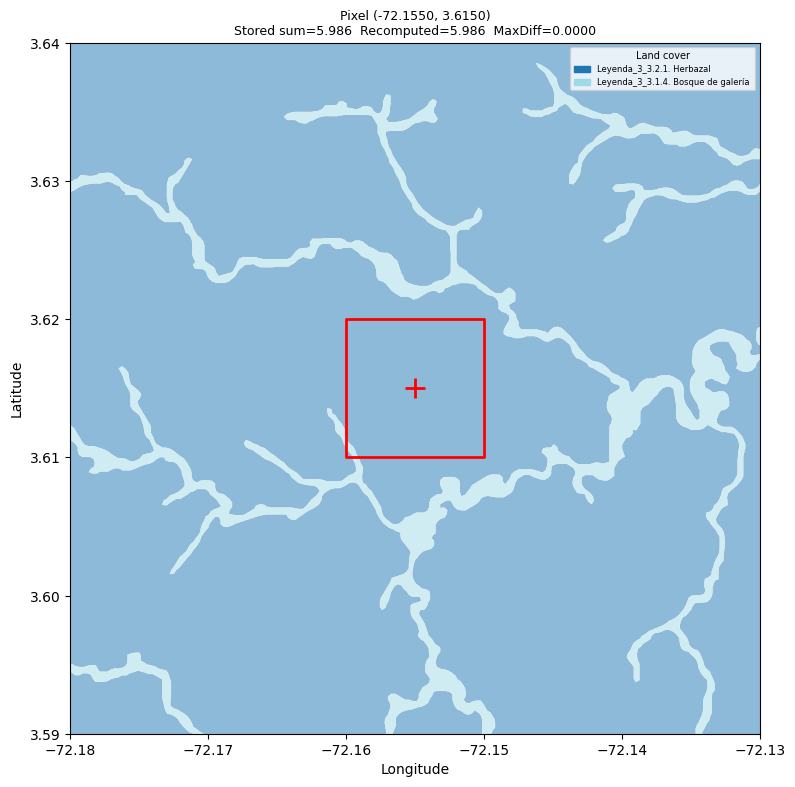


✓ Pixel (-75.8950, 4.9450)
   Stored sum:     4.9626  |  Recomputed sum: 4.9626
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_2.2.1. Cultivos permanentes herbáce recomputed=0.9626  stored=0.9626
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.9626  stored=0.9626
     ✓ Leyenda_4_2.2.1.2. Caña                       recomputed=0.9626  stored=0.9626
     ✓ Leyenda_5_2.2.1.2.1. Caña de azúcar           recomputed=0.9626  stored=0.9626
     ✓ Leyenda_2_2.2. Cultivos permanentes           recomputed=0.9626  stored=0.9626
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.0374  stored=0.0374
     ✓ Leyenda_3_3.2.3. Vegetación secundaria o en t recomputed=0.0374  stored=0.0374
     ✓ Leyenda_4_3.2.3.2. Vegetación secundaria baja recomputed=0.0374  stored=0.0374
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.0374  stored=0.0374


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


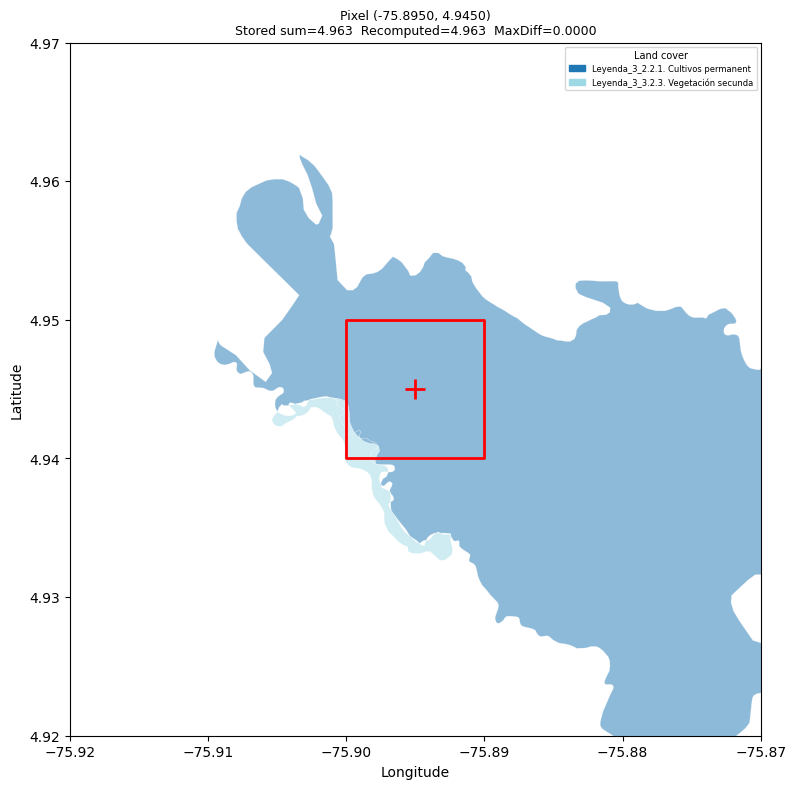


✓ Pixel (-74.2050, 9.1550)
   Stored sum:     3.0000  |  Recomputed sum: 3.0000
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.7985  stored=0.7985
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.7412  stored=0.7412
     ✓ Leyenda_3_2.4.3. Mosaico de cultivos, pastos  recomputed=0.7332  stored=0.7332
     ✓ Leyenda_2_4.1. Áreas húmedas continentales    recomputed=0.1372  stored=0.1372
     ✓ Leyenda_3_4.1.1. Zonas pantanosas             recomputed=0.1372  stored=0.1372
     ✓ Leyenda_1_4. Áreas húmedas                    recomputed=0.1372  stored=0.1372
     ✓ Leyenda_1_5. Superficies de agua              recomputed=0.0642  stored=0.0642
     ✓ Leyenda_2_5.1. Aguas  continentales           recomputed=0.0642  stored=0.0642
     ✓ Leyenda_3_5.1.2. Lagunas, lagos y ciénagas na recomputed=0.0642  stored=0.0642
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.0574  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


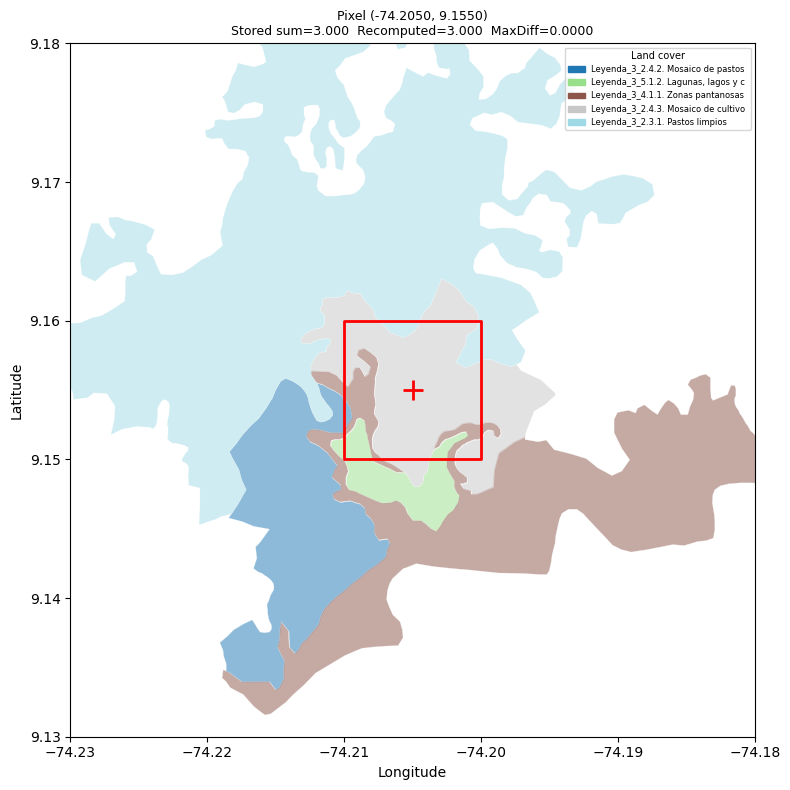


✓ Pixel (-73.8950, 7.9150)
   Stored sum:     3.0000  |  Recomputed sum: 3.0000
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_4.1.1. Zonas pantanosas             recomputed=0.9327  stored=0.9327
     ✓ Leyenda_1_4. Áreas húmedas                    recomputed=0.9327  stored=0.9327
     ✓ Leyenda_2_4.1. Áreas húmedas continentales    recomputed=0.9327  stored=0.9327
     ✓ Leyenda_3_5.1.2. Lagunas, lagos y ciénagas na recomputed=0.0673  stored=0.0673
     ✓ Leyenda_1_5. Superficies de agua              recomputed=0.0673  stored=0.0673
     ✓ Leyenda_2_5.1. Aguas  continentales           recomputed=0.0673  stored=0.0673


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


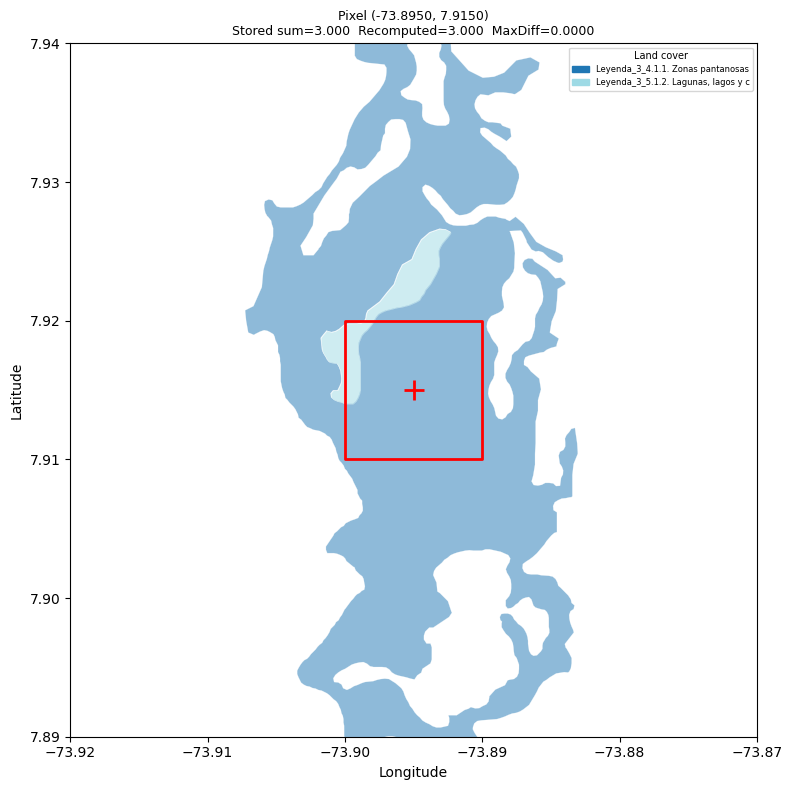


✓ Pixel (-75.5250, 8.5350)
   Stored sum:     3.0000  |  Recomputed sum: 3.0000
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=1.0000  stored=1.0000
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.6116  stored=0.6116
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.6116  stored=0.6116
     ✓ Leyenda_3_2.1.1. Otros cultivos transitorios  recomputed=0.3884  stored=0.3884
     ✓ Leyenda_2_2.1. Cultivos transitorios          recomputed=0.3884  stored=0.3884


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


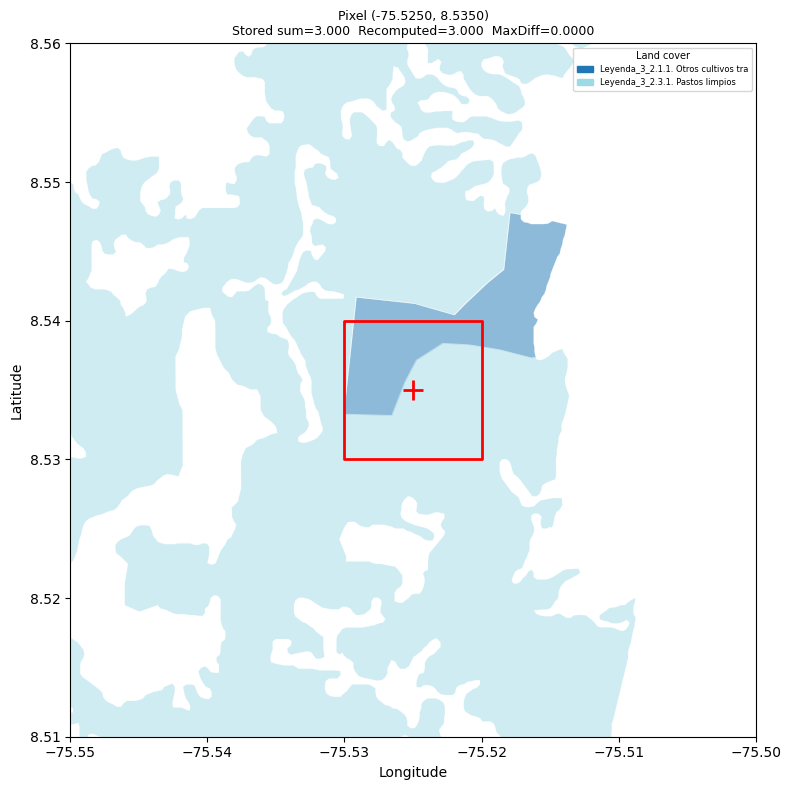


✓ Pixel (-73.0150, 11.2050)
   Stored sum:     3.8584  |  Recomputed sum: 3.8584
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.8584  stored=0.8584
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.8584  stored=0.8584
     ✓ Leyenda_3_3.2.3. Vegetación secundaria o en t recomputed=0.7112  stored=0.7112
     ✓ Leyenda_4_3.2.3.2. Vegetación secundaria baja recomputed=0.7112  stored=0.7112
     ✓ Leyenda_4_3.2.2.1. Arbustal denso             recomputed=0.1472  stored=0.1472
     ✓ Leyenda_3_3.2.2. Arbustal                     recomputed=0.1472  stored=0.1472
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.1416  stored=0.1416
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.0840  stored=0.0840
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.0840  stored=0.0840
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.0576  stored

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


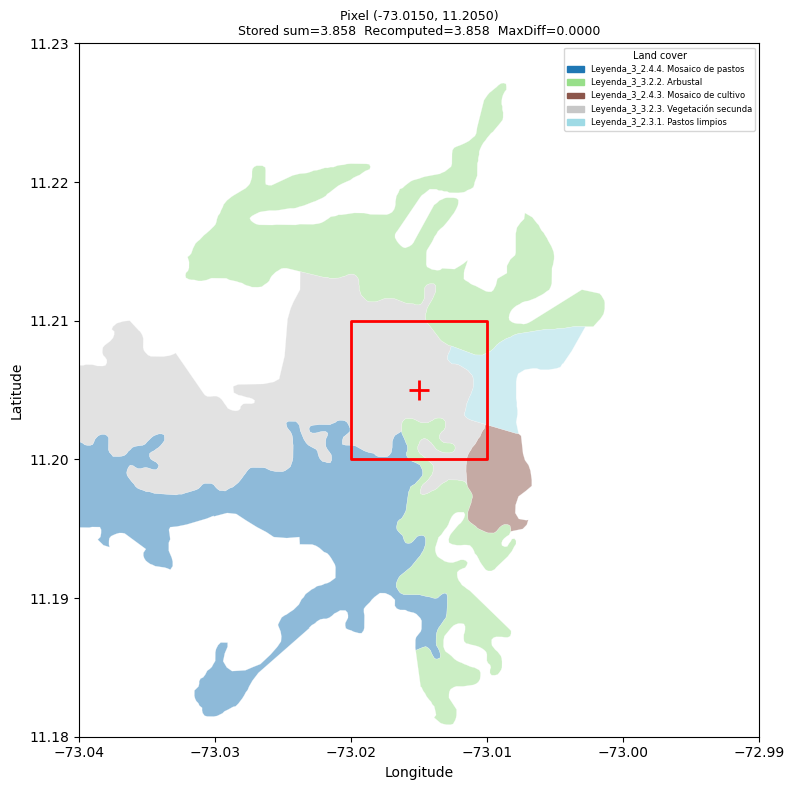


✓ Pixel (-74.1150, 10.1750)
   Stored sum:     3.0009  |  Recomputed sum: 3.0009
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.9458  stored=0.9458
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.5468  stored=0.5468
     ✓ Leyenda_3_2.3.2. Pastos arbolados             recomputed=0.4659  stored=0.4659
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.3981  stored=0.3981
     ✓ Leyenda_3_2.4.4. Mosaico de pastos con espaci recomputed=0.3981  stored=0.3981
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.0542  stored=0.0542
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.0542  stored=0.0542
     ✓ Leyenda_3_3.1.4. Bosque de galería y ripario  recomputed=0.0542  stored=0.0542
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.0406  stored=0.0406
     ✓ Leyenda_3_2.3.3. Pastos enmalezados           recomputed=0.0402  stored

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


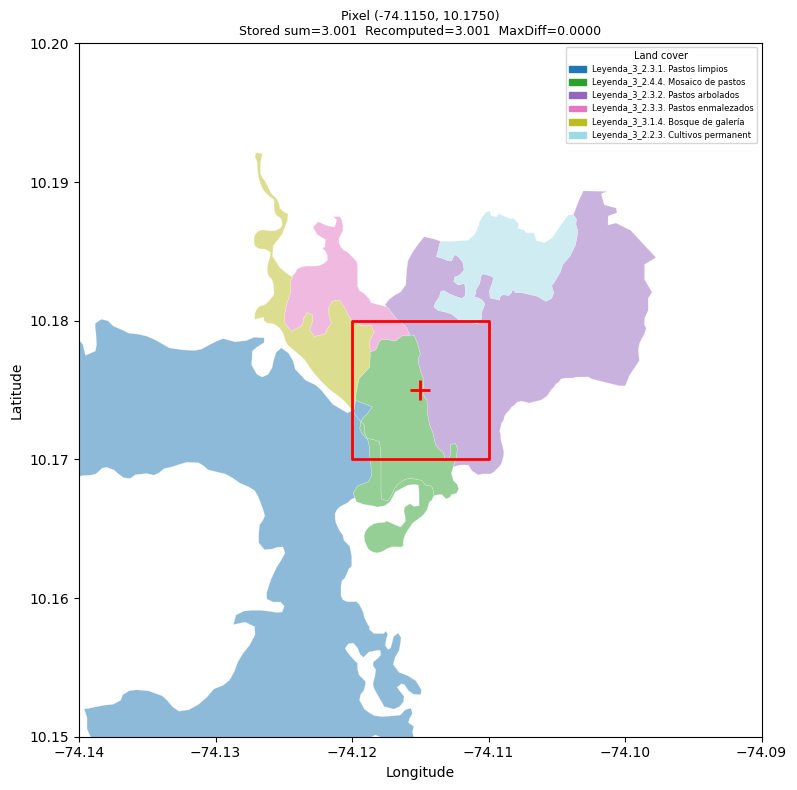


✓ Pixel (-74.3550, 2.9350)
   Stored sum:     4.4523  |  Recomputed sum: 4.4523
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.7262  stored=0.7262
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.7262  stored=0.7262
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.7262  stored=0.7262
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=0.7262  stored=0.7262
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.7262  stored=0.7262
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.2738  stored=0.2738
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.1611  stored=0.1611
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.1611  stored=0.1611
     ✓ Leyenda_3_2.4.4. Mosaico de pastos con espaci recomputed=0.1127  stored=0.1127
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.1127  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


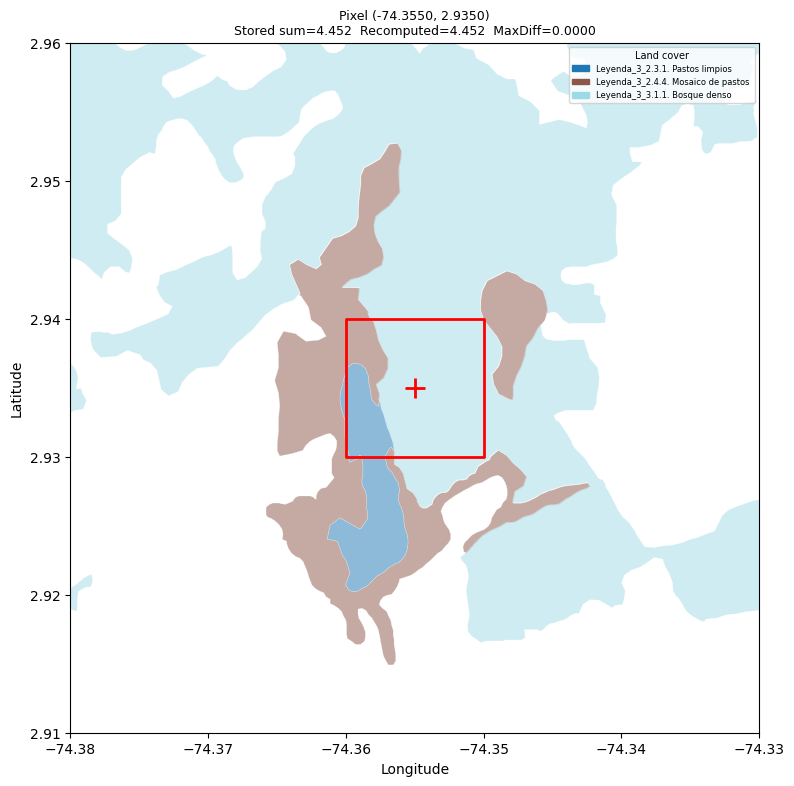


✓ Pixel (-70.3150, -3.2150)
   Stored sum:     4.9054  |  Recomputed sum: 4.9054
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.9921  stored=0.9921
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.9527  stored=0.9527
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.9527  stored=0.9527
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=0.9527  stored=0.9527
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.9527  stored=0.9527
     ✓ Leyenda_3_3.2.3. Vegetación secundaria o en t recomputed=0.0394  stored=0.0394
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.0394  stored=0.0394


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


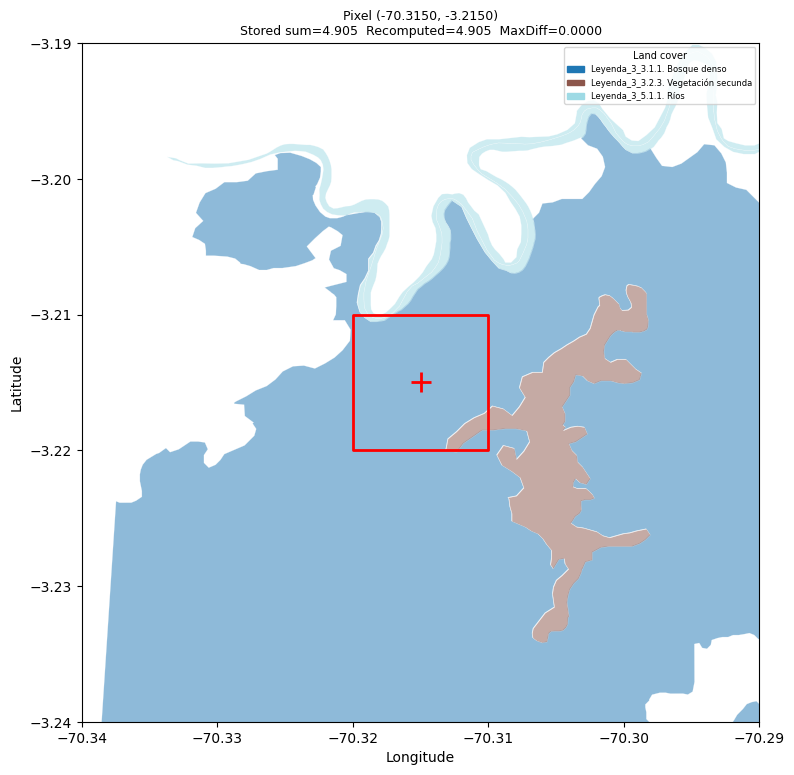


✓ Pixel (-74.2650, 1.8150)
   Stored sum:     3.0336  |  Recomputed sum: 3.0336
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.9832  stored=0.9832
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.9649  stored=0.9649
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.9649  stored=0.9649
     ✓ Leyenda_3_2.4.4. Mosaico de pastos con espaci recomputed=0.0183  stored=0.0183
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.0183  stored=0.0183
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.0168  stored=0.0168
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.0168  stored=0.0168
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.0168  stored=0.0168
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.0168  stored=0.0168
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=0.0168  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


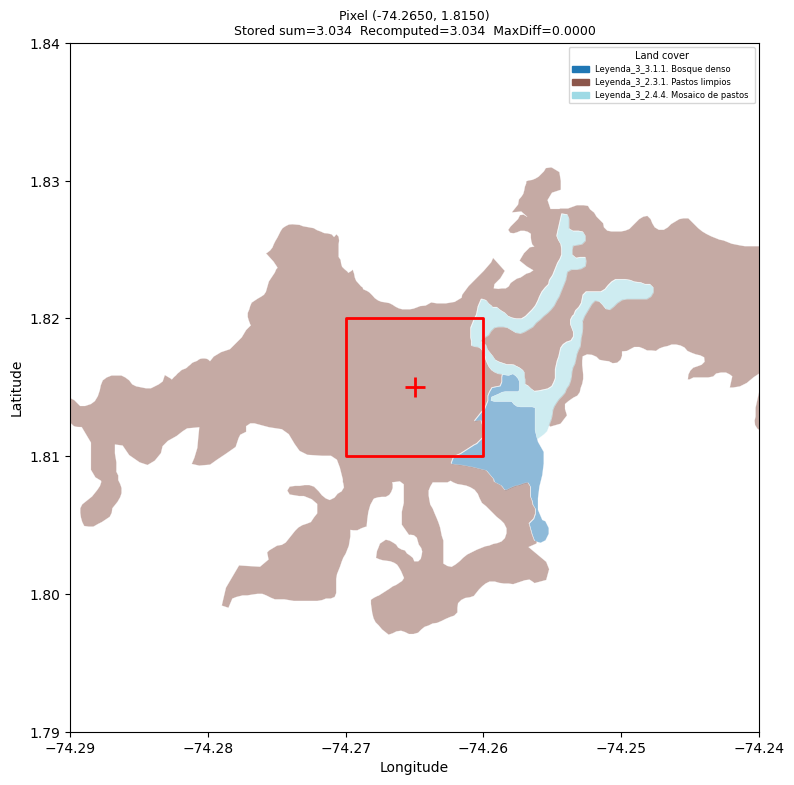


✓ Pixel (-74.5050, 0.6250)
   Stored sum:     3.9600  |  Recomputed sum: 3.9600
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.7976  stored=0.7976
     ✓ Leyenda_3_3.2.3. Vegetación secundaria o en t recomputed=0.4776  stored=0.4776
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.4776  stored=0.4776
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.3200  stored=0.3200
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.3200  stored=0.3200
     ✓ Leyenda_5_3.1.1.1.2. Bosque denso alto inunda recomputed=0.3200  stored=0.3200
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.3200  stored=0.3200
     ✓ Leyenda_6_3.1.1.1.2.1. Bosque denso alto Inun recomputed=0.3200  stored=0.3200
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.1578  stored=0.1578
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.1067  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


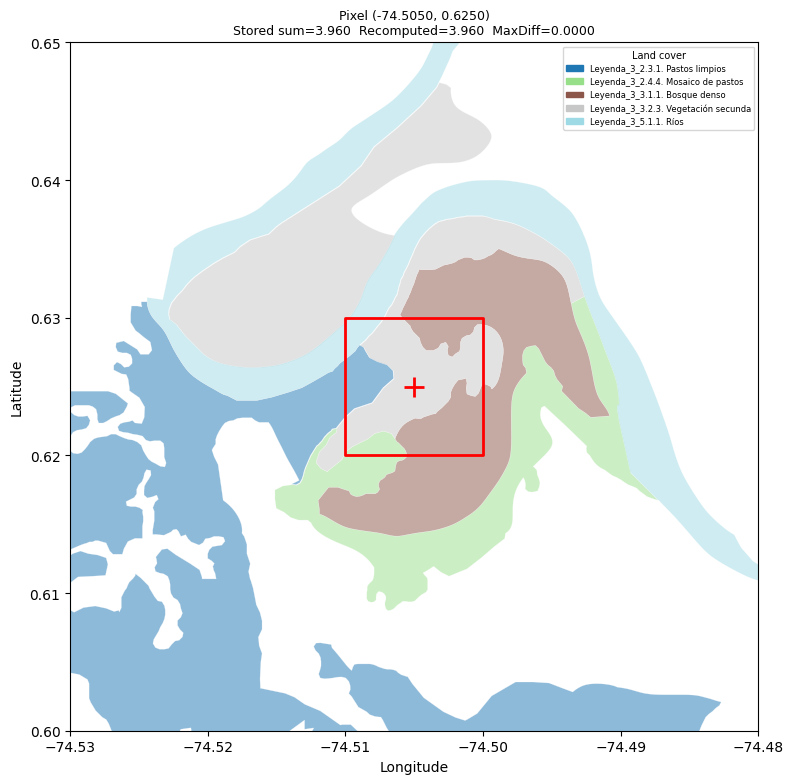


✓ Pixel (-71.2050, 1.7450)
   Stored sum:     5.0000  |  Recomputed sum: 5.0000
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=1.0000  stored=1.0000
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=1.0000  stored=1.0000
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=1.0000  stored=1.0000
     ✓ Leyenda_2_3.1. Bosques                        recomputed=1.0000  stored=1.0000
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=1.0000  stored=1.0000


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


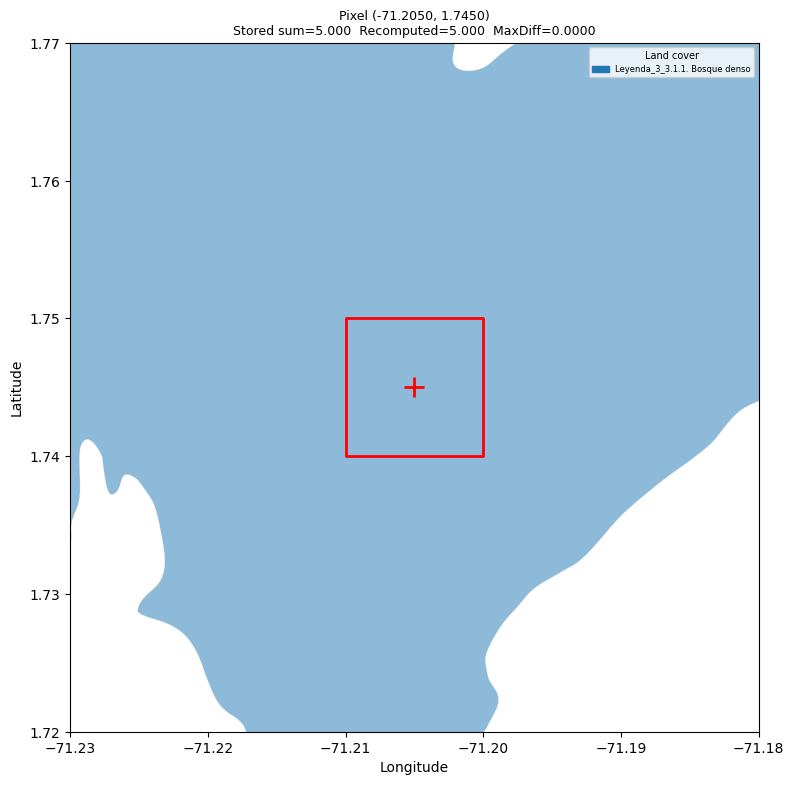


✓ Pixel (-74.8650, 1.0050)
   Stored sum:     3.6107  |  Recomputed sum: 3.6107
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.6946  stored=0.6946
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.6913  stored=0.6913
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.6913  stored=0.6913
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.3054  stored=0.3054
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.3054  stored=0.3054
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.3054  stored=0.3054
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.3054  stored=0.3054
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=0.3054  stored=0.3054


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


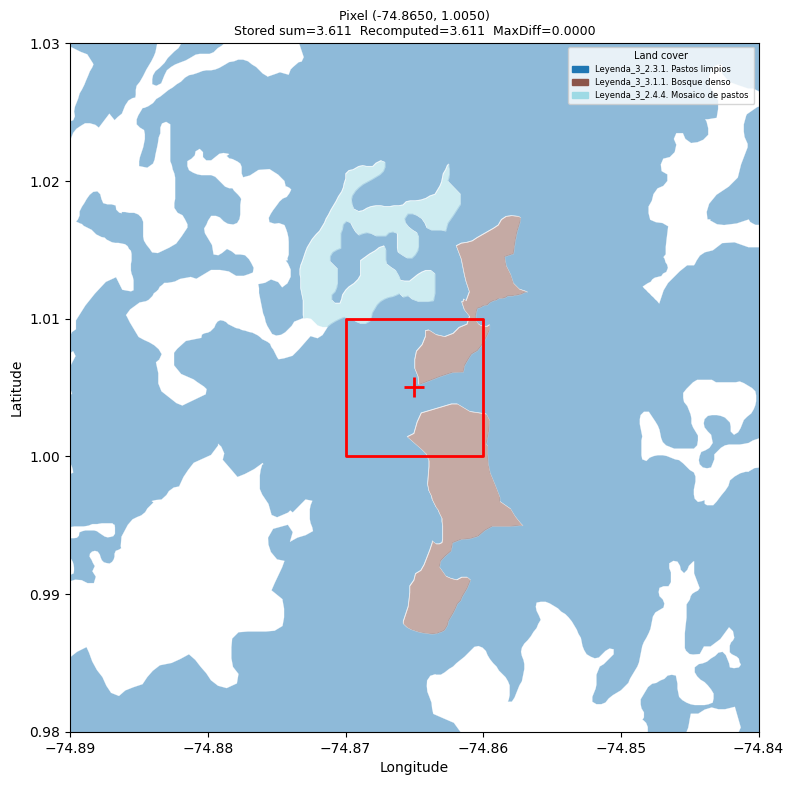


✓ Pixel (-71.8750, 5.2850)
   Stored sum:     6.0000  |  Recomputed sum: 6.0000
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_3.2.1. Herbazal                     recomputed=1.0000  stored=1.0000
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=1.0000  stored=1.0000
     ✓ Leyenda_4_3.2.1.1. Herbazal denso             recomputed=1.0000  stored=1.0000
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=1.0000  stored=1.0000
     ✓ Leyenda_5_3.2.1.1.2. Herbazal denso inundable recomputed=1.0000  stored=1.0000
     ✓ Leyenda_6_3.2.1.1.2.1. Herbazal denso inundab recomputed=1.0000  stored=1.0000


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


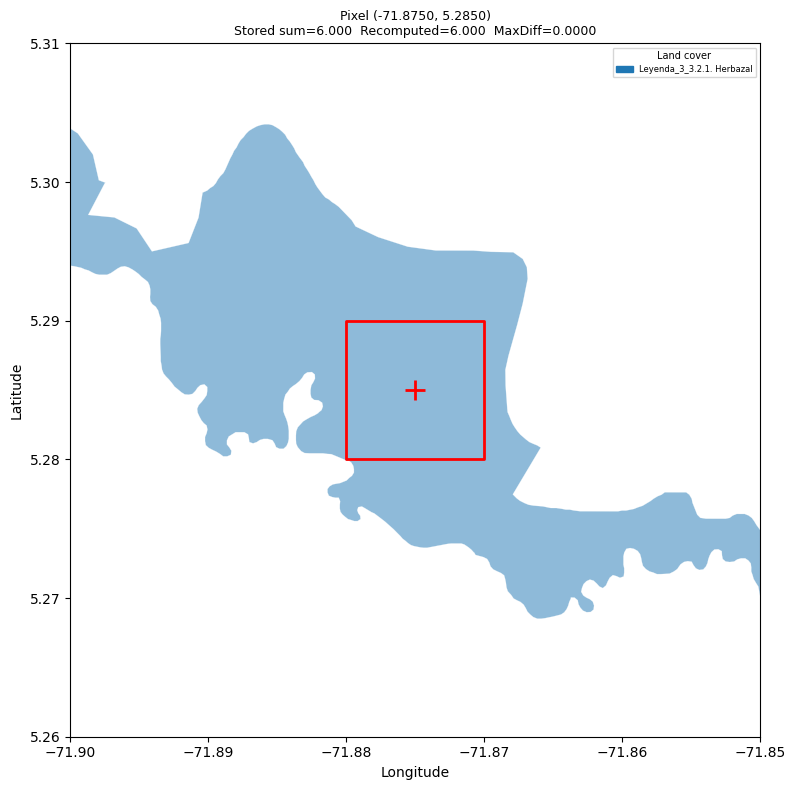


✓ Pixel (-74.4250, 1.2750)
   Stored sum:     3.6903  |  Recomputed sum: 3.6903
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.6176  stored=0.6176
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.5268  stored=0.5268
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.5268  stored=0.5268
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.3824  stored=0.3824
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.3451  stored=0.3451
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.3451  stored=0.3451
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=0.3451  stored=0.3451
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.3451  stored=0.3451
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.0907  stored=0.0907
     ✓ Leyenda_3_2.4.4. Mosaico de pastos con espaci recomputed=0.0797  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


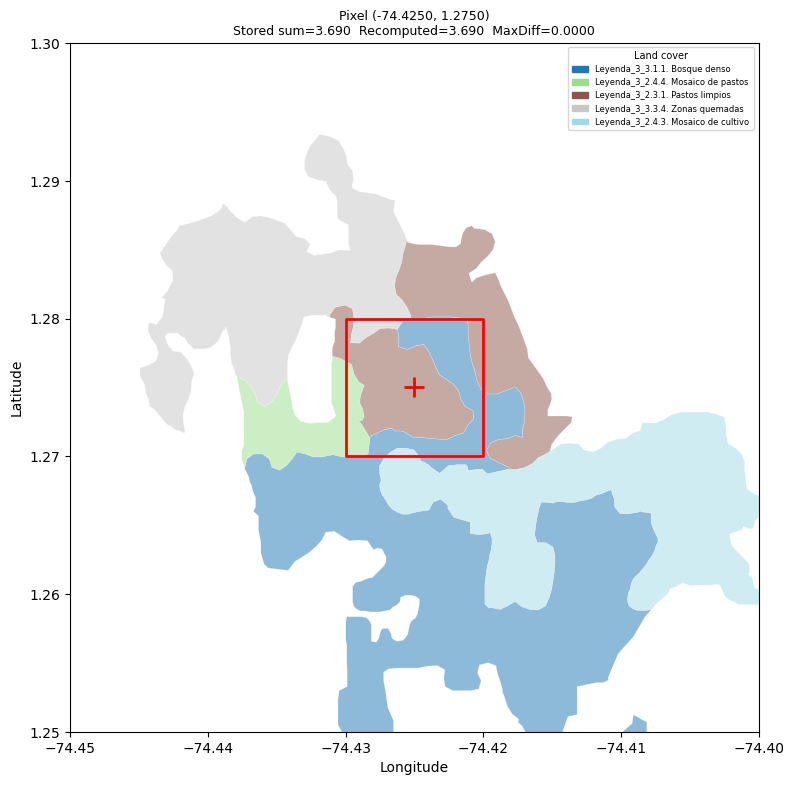


✓ Pixel (-74.0350, 6.8050)
   Stored sum:     3.0000  |  Recomputed sum: 3.0000
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.7418  stored=0.7418
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.7418  stored=0.7418
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.7418  stored=0.7418
     ✓ Leyenda_3_5.1.2. Lagunas, lagos y ciénagas na recomputed=0.2582  stored=0.2582
     ✓ Leyenda_1_5. Superficies de agua              recomputed=0.2582  stored=0.2582
     ✓ Leyenda_2_5.1. Aguas  continentales           recomputed=0.2582  stored=0.2582


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


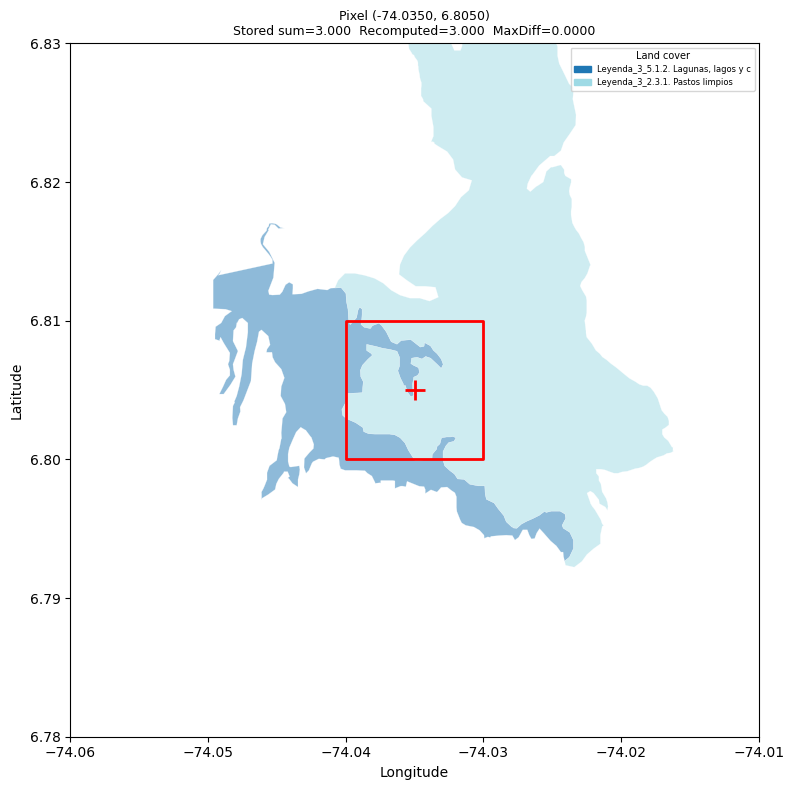


✓ Pixel (-70.1750, 4.0950)
   Stored sum:     4.3479  |  Recomputed sum: 4.3479
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.7445  stored=0.7445
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.6739  stored=0.6739
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=0.6739  stored=0.6739
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.6739  stored=0.6739
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.6739  stored=0.6739
     ✓ Leyenda_3_2.4.4. Mosaico de pastos con espaci recomputed=0.2555  stored=0.2555
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.2555  stored=0.2555
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.2555  stored=0.2555
     ✓ Leyenda_3_3.2.3. Vegetación secundaria o en t recomputed=0.0706  stored=0.0706
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.0706  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


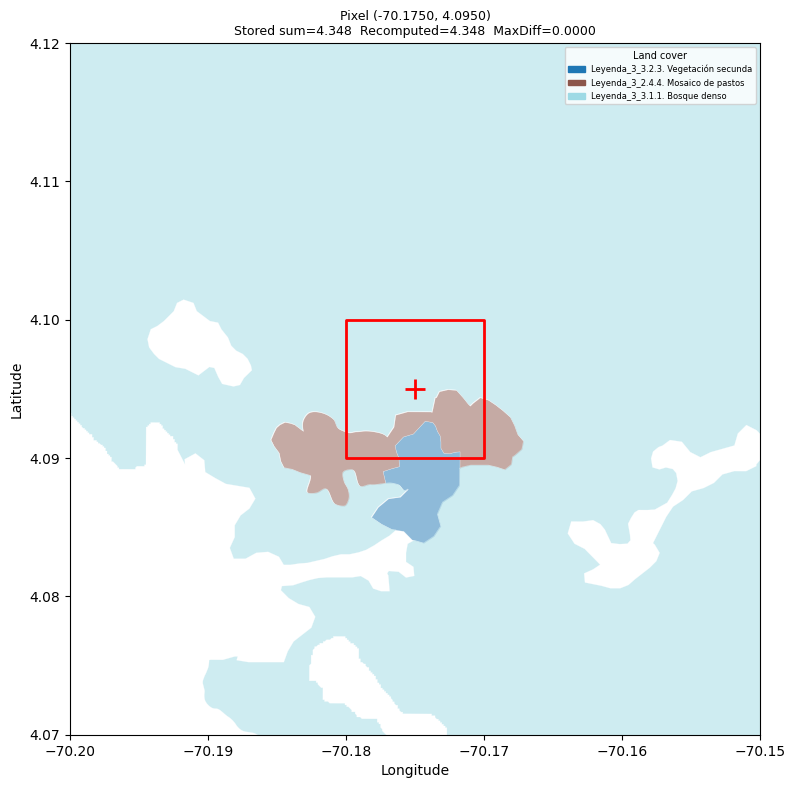


✓ Pixel (-71.4950, 2.2050)
   Stored sum:     5.1861  |  Recomputed sum: 5.1861
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.9870  stored=0.9870
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=0.7747  stored=0.7747
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=0.7747  stored=0.7747
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.7747  stored=0.7747
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=0.7747  stored=0.7747
     ✓ Leyenda_5_3.2.1.1.1. Herbazal denso de tierra recomputed=0.2122  stored=0.2122
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.2122  stored=0.2122
     ✓ Leyenda_3_3.2.1. Herbazal                     recomputed=0.2122  stored=0.2122
     ✓ Leyenda_4_3.2.1.1. Herbazal denso             recomputed=0.2122  stored=0.2122
     ✓ Leyenda_6_3.2.1.1.1.1.  Herbazal denso de tie recomputed=0.2122  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


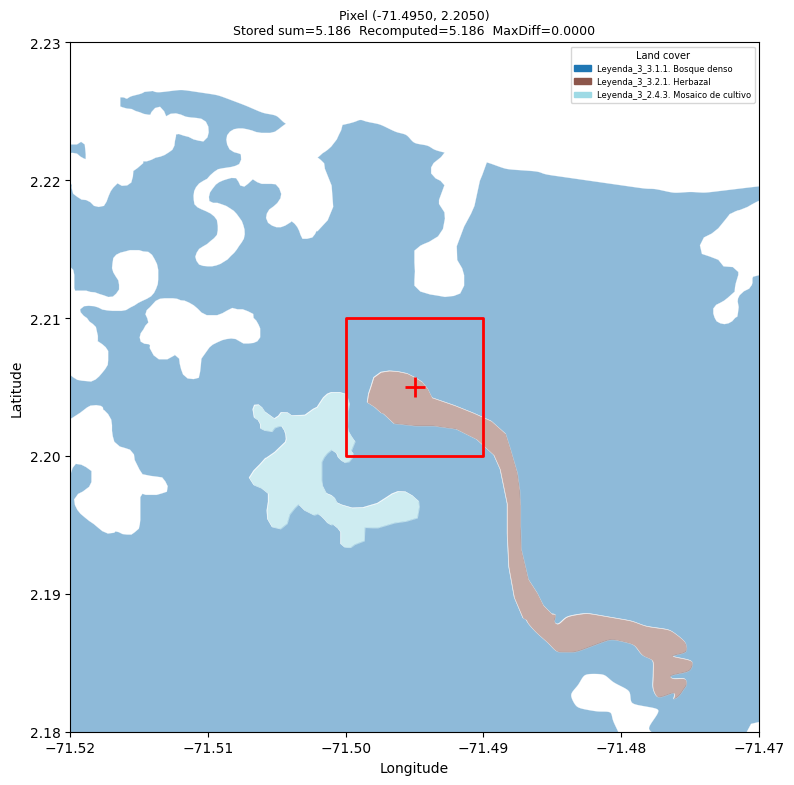


✓ Pixel (-75.2150, 8.1850)
   Stored sum:     3.8951  |  Recomputed sum: 3.8951
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_3.2.3. Vegetación secundaria o en t recomputed=0.7306  stored=0.7306
     ✓ Leyenda_4_3.2.3.1. Vegetación secundaria alta recomputed=0.7306  stored=0.7306
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.7306  stored=0.7306
     ✓ Leyenda_2_3.2. Áreas con vegetación herbácea  recomputed=0.7306  stored=0.7306
     ✓ Leyenda_3_1.3.1. Zonas de extracción minera   recomputed=0.1645  stored=0.1645
     ✓ Leyenda_2_1.3. Zonas de extracción mineras y  recomputed=0.1645  stored=0.1645
     ✓ Leyenda_1_1. Territorios artificializados     recomputed=0.1645  stored=0.1645
     ✓ Leyenda_4_1.3.1.4. Explotación de oro         recomputed=0.1645  stored=0.1645
     ✓ Leyenda_3_2.4.4. Mosaico de pastos con espaci recomputed=0.1049  stored=0.1049
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.1049  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


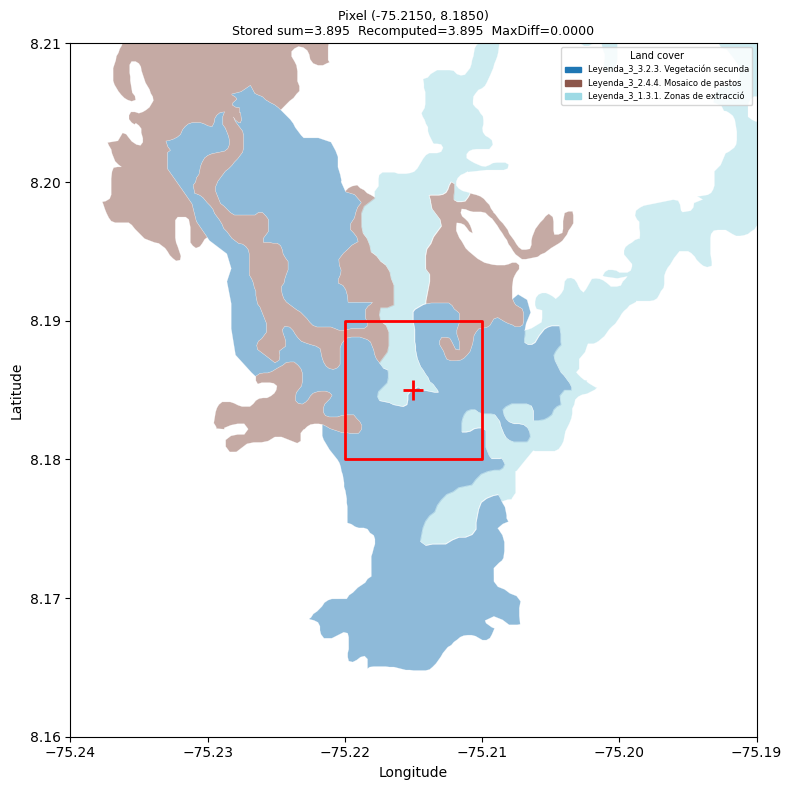


✓ Pixel (-73.3250, 9.7450)
   Stored sum:     3.0308  |  Recomputed sum: 3.0308
   Max difference: 0.000001
   Land cover breakdown (recomputed):
     ✓ Leyenda_1_2. Territorios agrícolas            recomputed=0.6064  stored=0.6064
     ✓ Leyenda_2_3.1. Bosques                        recomputed=0.3936  stored=0.3936
     ✓ Leyenda_3_3.1.4. Bosque de galería y ripario  recomputed=0.3936  stored=0.3936
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=0.3936  stored=0.3936
     ✓ Leyenda_2_2.4. Áreas agrícolas heterogéneas   recomputed=0.3423  stored=0.3423
     ✓ Leyenda_2_2.3. Pastos                         recomputed=0.2334  stored=0.2334
     ✓ Leyenda_3_2.3.1. Pastos limpios               recomputed=0.2334  stored=0.2334
     ✓ Leyenda_3_2.4.2. Mosaico de pastos y cultivos recomputed=0.1809  stored=0.1809
     ✓ Leyenda_3_2.4.4. Mosaico de pastos con espaci recomputed=0.1614  stored=0.1614
     ✓ Leyenda_3_2.1.2. Cereales                     recomputed=0.0308  stored=

/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


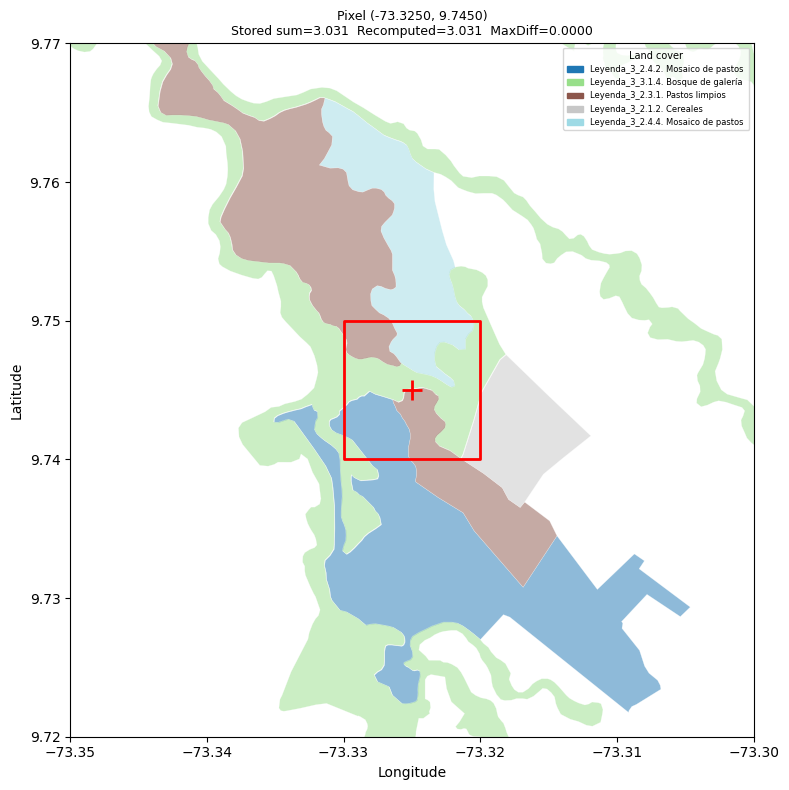


✓ Pixel (-69.9750, 3.6950)
   Stored sum:     5.0000  |  Recomputed sum: 5.0000
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=1.0000  stored=1.0000
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=1.0000  stored=1.0000
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=1.0000  stored=1.0000
     ✓ Leyenda_2_3.1. Bosques                        recomputed=1.0000  stored=1.0000
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=1.0000  stored=1.0000


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


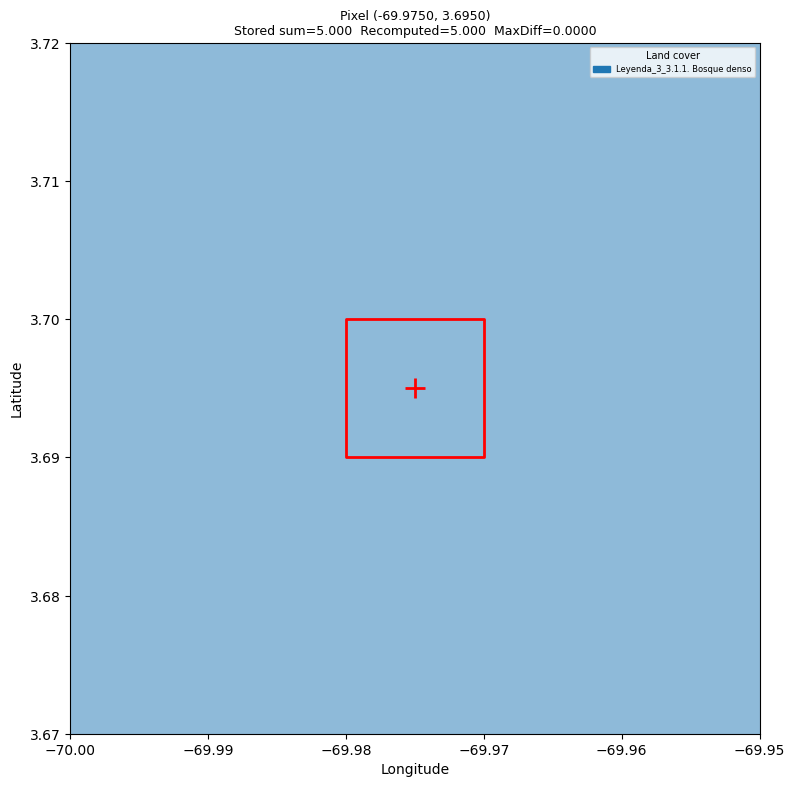


✓ Pixel (-70.7650, 1.9750)
   Stored sum:     5.0000  |  Recomputed sum: 5.0000
   Max difference: 0.000000
   Land cover breakdown (recomputed):
     ✓ Leyenda_3_3.1.1. Bosque denso                 recomputed=1.0000  stored=1.0000
     ✓ Leyenda_1_3. Bosques y áreas seminaturales    recomputed=1.0000  stored=1.0000
     ✓ Leyenda_4_3.1.1.1. Bosque denso alto          recomputed=1.0000  stored=1.0000
     ✓ Leyenda_2_3.1. Bosques                        recomputed=1.0000  stored=1.0000
     ✓ Leyenda_5_3.1.1.1.1. Bosque denso alto de tie recomputed=1.0000  stored=1.0000


/tmp/ipykernel_4119726/4127916287.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', len(unique_types))


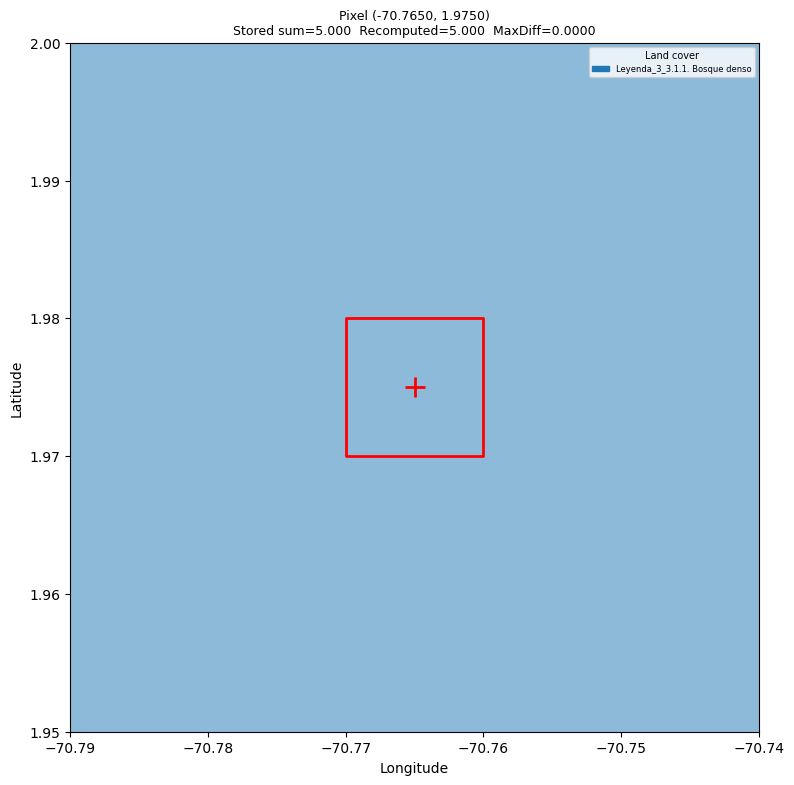


✓ Pixel (-75.7850, 9.4050)
   Stored sum:     0.0000  |  Recomputed sum: 0.0000
   Max difference: 0.000000
   ⚠ No land cover found in recomputation


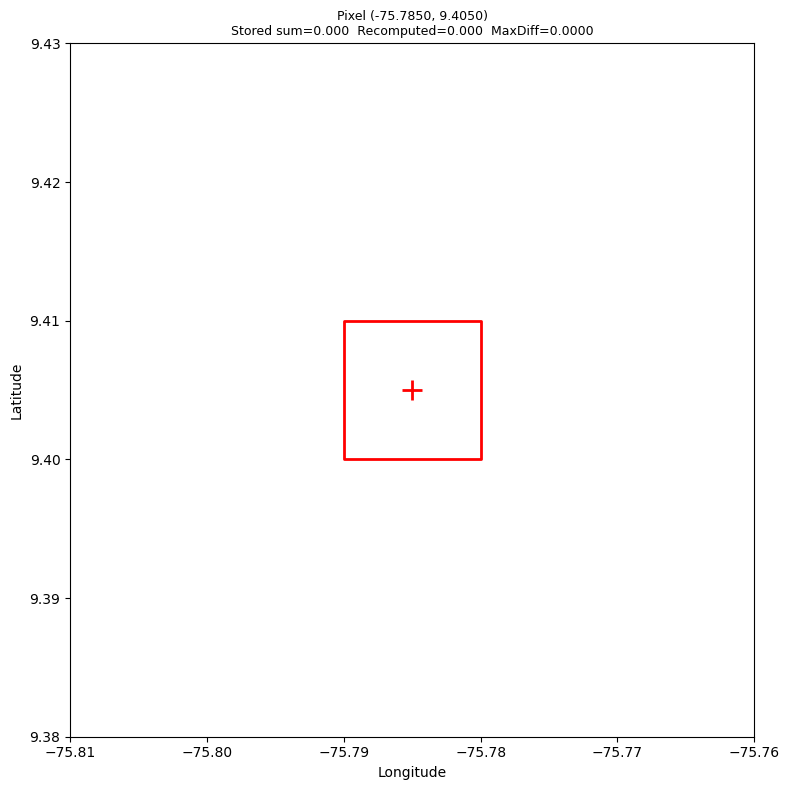


✓ Pixel (-75.5950, 10.3250)
   Stored sum:     0.0000  |  Recomputed sum: 0.0000
   Max difference: 0.000000
   ⚠ No land cover found in recomputation


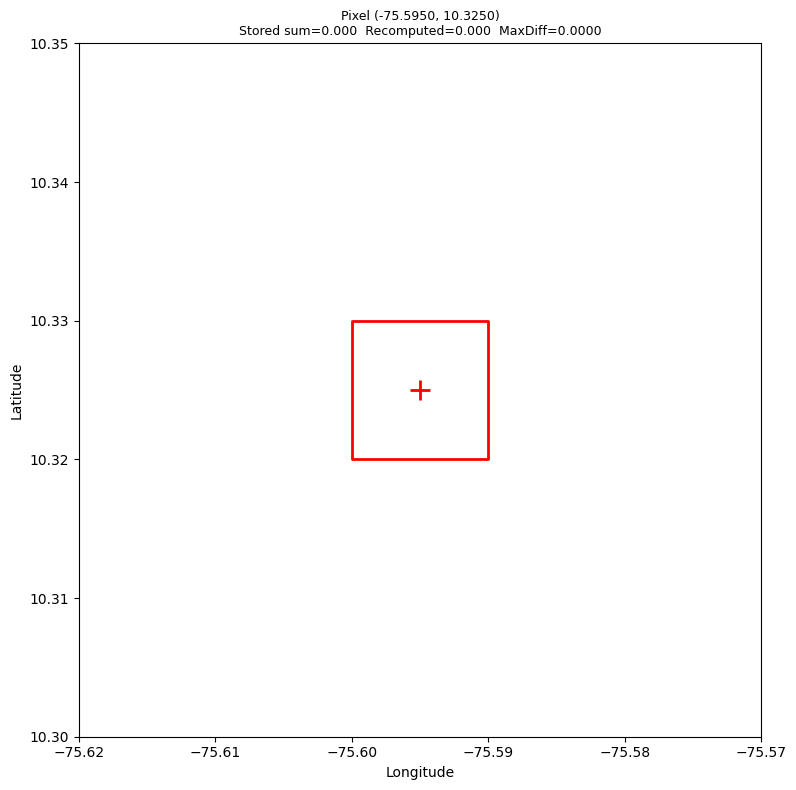

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import box
import numpy as np

def test_landcover_assignment(df, encoded_gdf, l_in, n_samples=5, delta=0.01/2):
    """
    Visual and numerical test for land cover assignment.
    For each sampled pixel:
    - Shows the pixel geometry overlaid on land cover polygons
    - Compares stored values vs recomputed intersection areas
    - Flags discrepancies
    """
    pixel_area = (2 * delta) ** 2

    # Sample pixels with data and without
    #l_in2=df.columns[3:-1]
    has_data    = df[l_in].sum(axis=1) > 0
    sample_with = df[has_data].sample(min(n_samples, has_data.sum()), random_state=42)
    sample_without = df[~has_data].sample(min(2, (~has_data).sum()), random_state=42)
    sample = pd.concat([sample_with, sample_without])

    print(f"Testing {len(sample)} pixels ({len(sample_with)} with data, {len(sample_without)} without)\n")

    for idx, row in sample.iterrows():
        lon, lat = row['longitude'], row['latitude']
        pixel_geom = box(lon - delta, lat - delta, lon + delta, lat + delta)

        # --- Recompute intersection from scratch ---
        candidate_idx = list(encoded_gdf.sindex.query(pixel_geom, predicate='intersects'))
        candidates    = encoded_gdf.iloc[candidate_idx].copy()

        recomputed = {}
        for col in l_in:
            relevant = candidates[candidates[col] > 0]
            area = sum(
                pixel_geom.intersection(geom).area
                for geom in relevant.geometry
                if not geom.is_empty
            )
            recomputed[col] = area / pixel_area

        recomputed_series = pd.Series(recomputed)
        stored_series     = row[l_in]
        # --- Numerical comparison ---
        diff       = (recomputed_series - stored_series).abs()
        max_diff   = diff.max()
        sum_stored = stored_series.sum()
        sum_recomp = recomputed_series.sum()
        status     = '✓' if max_diff < 0.01 else '✗'

        print(f"{status} Pixel ({lon:.4f}, {lat:.4f})")
        print(f"   Stored sum:     {sum_stored:.4f}  |  Recomputed sum: {sum_recomp:.4f}")
        print(f"   Max difference: {max_diff:.6f}")

        # Show non-zero land cover types
        nonzero_stored = stored_series[stored_series > 0.01]
        nonzero_recomp = recomputed_series[recomputed_series > 0.01]

        if len(nonzero_recomp) > 0:
            print("   Land cover breakdown (recomputed):")
            for col, val in nonzero_recomp.sort_values(ascending=False).items():
                stored_val = stored_series[col]
                match = '✓' if abs(val - stored_val) < 0.01 else '✗'
                print(f"     {match} {col[:45]:<45} recomputed={val:.4f}  stored={stored_val:.4f}")
        else:
            print("   ⚠ No land cover found in recomputation")

        # --- Visual check ---
        fig, ax = plt.subplots(figsize=(8, 8))

        # Plot land cover polygons with colors
        if len(candidates) > 0:
            # Find dominant land cover per polygon for coloring
            dominant = candidates[l_in].idxmax(axis=1)
            unique_types = dominant.unique()

            cmap   = plt.cm.get_cmap('tab20', len(unique_types))
            colors = {t: cmap(i) for i, t in enumerate(unique_types)}

            for _, lc_row in candidates.iterrows():
                dom = l_in[candidates[l_in].loc[_].values.argmax()] if candidates[l_in].loc[_].sum() > 0 else 'unknown'
                color = colors.get(dom, 'gray')
                gpd.GeoSeries([lc_row.geometry]).plot(
                    ax=ax, color=color, alpha=0.5, edgecolor='white', linewidth=0.3
                )

            # Legend
            patches = [mpatches.Patch(color=colors[t], label=t[:35]) for t in unique_types]
            ax.legend(handles=patches, loc='upper right', fontsize=6,
                      title='Land cover', title_fontsize=7)

        # Plot the pixel box
        pixel_gdf = gpd.GeoDataFrame(geometry=[pixel_geom], crs='EPSG:4326')
        pixel_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Pixel')

        # Plot pixel center
        ax.plot(lon, lat, 'r+', markersize=15, markeredgewidth=2)

        ax.set_title(
            f"Pixel ({lon:.4f}, {lat:.4f})\n"
            f"Stored sum={sum_stored:.3f}  Recomputed={sum_recomp:.3f}  MaxDiff={max_diff:.4f}",
            fontsize=9
        )
        ax.set_xlim(lon - delta * 5, lon + delta * 5)  # zoom out 5x to see context
        ax.set_ylim(lat - delta * 5, lat + delta * 5)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        plt.tight_layout()
        plt.show()

        print()

# --- Run the test ---
dfg_2022=gpd.read_file(r'/home/hernan/colombian_case_methane_analysis-/scripts_2026/Scripts/Cobertura_tierra_100K_periodo_2022_limite_administrativo/Cobertura_tierra_100K_periodo_2022_limite_administrativo/ECOSISTEMAS_18062025/ECOSISTEMAS_18062025.gpkg')#Cobertura_de_la_tierra_100K_Periodo_2020_limite_administrativo/shape Limite admin/e_cobertura_tierra_2020_admin.shp')#8\COBERTURAS CORINE 2018\shape coberturas 2018\cobertura_tierra_clc_2018.shp')
encoded_gdf=get_encoded(dfg_2022)
df = pd.read_csv('/home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/colombia_corr_metano_2022_2023_cobertura_2022.csv')#_bias.csv')
l_in=get_landcover_columns(encoded_gdf)
# #l_in=df.columns[3:-1]
test_landcover_assignment(df, encoded_gdf[encoded_gdf.columns], l_in, n_samples=25)

In [ ]:
df_completo['coordinate_x']=df_completo['longitude'].apply(lambda x: [x])
df_completo['coordinate_y']=df_completo['latitude'].apply(lambda x: [x])
df_completo['coordinates']=df_completo['coordinate_x']+df_completo['coordinate_y']
df_completo

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]"
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]"
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]"
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]"
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]"
...,...,...,...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]"
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.44500000000001, 4.525]"
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]"
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]"


In [ ]:
#df_completo.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_results.csv')
# df_completo=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_results.csv')
# df_completo

KeyboardInterrupt: 

In [ ]:
#df_completo.coordinates.to_numpy()[0]
df_completo_ng=df_completo[df_completo.coordinates.isin(df_g.coordinates)]#Se filtran los datos para saber cuáles son los válidos sin glint
df_completo_ng


In [ ]:
df_completo_ng.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_filtered.csv')

In [ ]:
#df_completo_ng.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_filtered.csv')
#df_completo.coordinates.isin(df_g.coordinates)

In [ ]:
df_completo_ng.dtypes

,0
id,object
longitude,float64
latitude,float64
time,int64
CH4_column_volume_mixing_ratio_dry_air_bias_corrected,float64
date,object
coordinate_x,object
coordinate_y,object
coordinates,object


In [ ]:
df_completo_ng=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_result_corrected.csv')
df_completo_ng['date']=pd.to_datetime(df_completo_ng['date'])
#df_comleto_ng['year']=df_completo_ng['date'].dt.year
df_2020=df_completo_ng[df_completo_ng.date.dt.year==2020]
df_2020.groupby(['longitude','latitude']).mean('CH4_column_volume_mixing_ratio_dry_air_bias_corrected').to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020_filtered.csv')

In [ ]:
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom_2020.csv')
df_s

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-77.305,7.745,1.606068e+12,1866.559650
1,-77.305,7.755,1.606068e+12,1866.559615
2,-77.295,7.705,1.606068e+12,1866.559567
3,-77.295,7.715,1.606068e+12,1866.559602
4,-77.295,7.725,1.606068e+12,1866.559608
...,...,...,...,...
307150,-67.325,3.455,1.577987e+12,1835.456421
307151,-67.315,3.375,1.580923e+12,1851.070163
307152,-67.315,3.385,1.580923e+12,1851.070189
307153,-67.315,3.435,1.577987e+12,1835.456439


In [ ]:
#df_s[(df_s['longitude']==-71.495)*(df_s['latitude']==11.925)].index
df_s['geometry'][0].intersects(encoded_df45['geometry'])

,geometry
217,False
249,False
255,False
269,False
338,False
...,...
393434,False
393435,False
393450,False
393453,False


In [4]:
#encoded_df45['geometry'][217].intersects(df_s['geometry'])
df=pd.read_csv('/home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/CH4_glintfiltered_colombia_2019-2026.csv')
df

/tmp/ipykernel_3780294/3568700364.py:2: DtypeWarning: Columns (0: coordinate_x, 1: coordinate_y, 2: coordinates, 3: geometry) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/CH4_glintfiltered_colombia_2019-2026.csv')


,Unnamed: 0,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,0.0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12011470,NaN,20250829T170331_20250831T092526,-69.865,6.675,1756488305000,1940.542034,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12011471,NaN,20250829T170331_20250831T092526,-69.855,6.675,1756488305000,1939.957886,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12011472,NaN,20250829T170331_20250831T092526,-69.865,6.685,1756488305000,1943.690466,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12011473,NaN,20250829T170331_20250831T092526,-69.855,6.685,1756488305000,1943.042545,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Unnamed: 0,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
9153397,NaN,20260530T181701_20260601T103437,-77.915,1.975,1780166315000,1936.036133,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153396,NaN,20260530T181701_20260601T103437,-77.925,1.975,1780166315000,1936.036133,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153395,NaN,20260530T181701_20260601T103437,-77.935,1.975,1780166315000,1936.036133,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153471,NaN,20260530T181701_20260601T103437,-78.065,2.035,1780166315000,1965.124165,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153394,NaN,20260530T181701_20260601T103437,-77.945,1.975,1780166315000,1936.036133,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153392,NaN,20260530T181701_20260601T103437,-77.965,1.975,1780166315000,1936.036157,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153391,NaN,20260530T181701_20260601T103437,-77.975,1.975,1780166315000,1946.173531,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153390,NaN,20260530T181701_20260601T103437,-77.985,1.975,1780166315000,1956.380050,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153389,NaN,20260530T181701_20260601T103437,-77.995,1.975,1780166315000,1957.819347,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9153388,NaN,20260530T181701_20260601T103437,-78.005,1.975,1780166315000,1959.258643,2026-05-30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dfp=pl.read_csv('/content/drive/Shareddrives/PIGCC/Satelite/Datos_a_05-2026/CH4_glintfiltered_colombia_2019-2026.csv',n_threads=4)
df=dfp.to_pandas()

In [ ]:
df.columns

Index(['Unnamed: 0', 'id', 'longitude', 'latitude', 'time',
       'CH4_column_volume_mixing_ratio_dry_air_bias_corrected', 'date',
       'coordinate_x', 'coordinate_y', 'coordinates', 'geometry',
       'Leyenda_3_1.1.1. Tejido urbano continuo',
       'Leyenda_3_1.1.2. Tejido urbano discontinuo',
       'Leyenda_3_1.2.1. Zonas industriales o comerciales',
       'Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados',
       'Leyenda_3_1.2.3. Zonas portuarias', 'Leyenda_3_1.2.4. Aeropuertos',
       'Leyenda_3_1.2.5. Obras hidráulicas',
       'Leyenda_3_1.3.1. Zonas de extracción minera',
       'Leyenda_3_1.3.2. Zona de disposición de residuos',
       'Leyenda_3_1.4.1. Zonas verdes urbanas',
       'Leyenda_3_1.4.2. Instalaciones recreativas',
       'Leyenda_3_2.1.1. Otros cultivos transitorios',
       'Leyenda_3_2.1.2. Cereales',
       'Leyenda_3_2.1.3. Oleaginosas y leguminosas',
       'Leyenda_3_2.1.4. Hortalizas', 'Leyenda_3_2.1.5. Tubérculos',
       'Leyenda_3_2.2

In [5]:
df['year']=pd.to_datetime(df['date'],format='mixed').dt.year
df['month']=pd.to_datetime(df['date'],format='mixed').dt.month
df

,Unnamed: 0,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,...,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua,year,month
0,0.0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,2
1,1.0,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,2
2,2.0,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,2
3,3.0,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,2
4,4.0,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12011470,NaN,20250829T170331_20250831T092526,-69.865,6.675,1756488305000,1940.542034,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,8
12011471,NaN,20250829T170331_20250831T092526,-69.855,6.675,1756488305000,1939.957886,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,8
12011472,NaN,20250829T170331_20250831T092526,-69.865,6.685,1756488305000,1943.690466,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,8
12011473,NaN,20250829T170331_20250831T092526,-69.855,6.685,1756488305000,1943.042545,2025-08-29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,8


In [6]:
# --- Biased approach (what a simple mean does) ---
CH4_COL='CH4_column_volume_mixing_ratio_dry_air_bias_corrected'
annual_biased = df.groupby(['longitude', 'latitude', 'year'])[CH4_COL].mean()

# --- Unbiased approach: monthly mean first, then annual mean ---
# Step 1: mean per pixel per month — each month gets equal weight
monthly_mean = df.groupby(
    ['longitude', 'latitude', 'year', 'month']
)[CH4_COL].mean()

# Step 2: mean across months — now each month contributes equally
annual_unbiased = monthly_mean.groupby(
    ['longitude', 'latitude', 'year']
).mean().reset_index()

# --- Quantify the bias ---
comparison = annual_biased.reset_index().merge(
    annual_unbiased,
    on=['longitude', 'latitude', 'year'],
    suffixes=('_biased', '_unbiased')
)
comparison['bias'] = comparison[f'{CH4_COL}_biased'] - comparison[f'{CH4_COL}_unbiased']

print(f"Mean bias:    {comparison['bias'].mean():.4f} ppb")
print(f"Max bias:     {comparison['bias'].max():.4f} ppb")
print(f"Std of bias:  {comparison['bias'].std():.4f} ppb")

# --- Also combine with common months filter from before ---
# Apply both corrections together
df_balanced = df[df['month'].isin(common_months)]

annual_corrected = df_balanced.groupby(
    ['longitude', 'latitude', 'year', 'month']
)[CH4_COL].mean().groupby(
    ['longitude', 'latitude', 'year']
).mean().reset_index()

print(f"\nFinal corrected dataset: {len(annual_corrected):,} pixel-year observations")

Mean bias:    -0.1635 ppb
Max bias:     64.5980 ppb
Std of bias:  2.7080 ppb


NameError: name 'common_months' is not defined

In [7]:
df.groupby(['year','month']).count().id

year  month
2019  2         26008
      3         15047
      4         63522
      5         13659
      6         25890
                ...  
2026  1        145155
      2        147281
      3        119995
      4         36191
      5        103909
Name: id, Length: 88, dtype: int64

In [8]:
monthly_counts = df.groupby(['year', 'month'])['longitude'].count()
yearly_counts  = df.groupby('year')['longitude'].count()

# Divide each month by its year total
fractions = monthly_counts / yearly_counts
fractions = fractions.reset_index()
fractions.columns = ['year', 'month', 'fraction']
print(fractions)

    year  month  fraction
0   2019      2  0.084533
1   2019      3  0.048907
2   2019      4  0.206463
3   2019      5  0.044395
4   2019      6  0.084149
..   ...    ...       ...
83  2026      1  0.262709
84  2026      2  0.266557
85  2026      3  0.217173
86  2026      4  0.065500
87  2026      5  0.188060

[88 rows x 3 columns]


In [15]:
# Apply both corrections together
common_months=[1,2,3,4,5,6,7,8,9,10,11,12]
df_balanced = df[df['month'].isin(common_months)]

annual_corrected = df_balanced.groupby(
    ['longitude', 'latitude', 'year', 'month']
)[CH4_COL].mean().groupby(
    ['longitude', 'latitude', 'year']
).mean().reset_index()

annual_corrected_median=df_balanced.groupby(['longitude', 'latitude', 'year'])[CH4_COL].median().reset_index()
print(f"\nFinal corrected dataset: {len(annual_corrected):,} pixel-year observations")


Final corrected dataset: 2,848,574 pixel-year observations


In [22]:
def compute_unbiased(year):
    df_year=pd.read_csv(f'/home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/colombia_corr_{year}_6.csv')
    #df_year2=pd.read_csv(f'/home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/colombia_corr_{year+1}_6.csv')
    #df_year=df_year1.merge(df_year2, on=['longitude', 'latitude'], how='outer', suffixes=('_1', '_2'))
    #df_year=pd.concat([df_year1,df_year2], ignore_index=True)
    df_year=df_year.groupby(['longitude', 'latitude']).mean().reset_index()
    df_year['year']=year
    annual_corrected_median_2020=df_balanced[(df_balanced['year']==year)|(df_balanced['year']==(year+1))].groupby(['longitude', 'latitude'])[CH4_COL].median().reset_index()
    annual_corrected_2020 = df_balanced[(df_balanced['year']==year)|(df_balanced['year']==(year+1))].groupby(
        ['longitude', 'latitude', 'month']
    )[CH4_COL].mean().groupby(
        ['longitude', 'latitude']
    ).mean().reset_index()
    #annual_corrected_2020=annual_corrected[annual_corrected['year']==year]
    #annual_corrected_median_2020=annual_corrected_median[annual_corrected_median['year']==year]
    df_s = df_year.merge(
    annual_corrected_2020[['longitude', 'latitude', CH4_COL]],
    on=['longitude', 'latitude'],
    how='left',
    suffixes=('_original', '_unbiased')
    )
    #annual_corrected_median=annual_corrected_median.reset_index()
    df_s2 = df_year.merge(
    annual_corrected_median_2020[['longitude', 'latitude', CH4_COL]],
    on=['longitude', 'latitude'],
    how='left',
    suffixes=('_original', '_unbiased')
    )
    print(df_s.columns,df_s2.columns)
    df_s1 = df_s.merge(
    df_s2[['longitude', 'latitude', CH4_COL+'_unbiased']],
    on=['longitude', 'latitude'],
    how='left',
    suffixes=('_mean', '_median')
    )
    df_s1.to_csv(f'/home/hernan/colombian_case_methane_analysis-/scripts_2026/Datos_a_05-2026/colombia_corr_{year}_unbiased.csv', index=False)

In [23]:
compute_unbiased(2019)
# compute_unbiased(2020)
# compute_unbiased(2022)

/tmp/ipykernel_3780294/3747995515.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_year=df_year.groupby(['longitude', 'latitude']).mean().reset_index()


Index(['longitude', 'latitude',
       'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_original',
       'Leyenda_3_1.1.1. Tejido urbano continuo',
       'Leyenda_3_1.1.2. Tejido urbano discontinuo',
       'Leyenda_3_1.2.1. Zonas industriales o comerciales',
       'Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados',
       'Leyenda_3_1.2.3. Zonas portuarias', 'Leyenda_3_1.2.4. Aeropuertos',
       'Leyenda_3_1.2.5. Obras hidráulicas',
       ...
       'Leyenda_6_3.1.1.1.2.2. Manglar denso alto',
       'Leyenda_6_3.1.1.1.2.3. Palmares',
       'Leyenda_6_3.2.1.1.1.1.  Herbazal denso de tierra firme no arbolado',
       'Leyenda_6_3.2.1.1.1.2.  Herbazal denso de tierra firme arbolado',
       'Leyenda_6_3.2.1.1.1.3.  Herbazal denso de tierra firme con arbustos',
       'Leyenda_6_3.2.1.1.2.1. Herbazal denso inundable no arbolado',
       'Leyenda_6_3.2.1.1.2.2. Herbazal denso inundable arbolado',
       'Leyenda_6_3.2.1.1.2.3. Arracachal', 'year',
       'CH4_column

In [1]:
import matplotlib_inline

In [ ]:
encoded_gdf[encoded_gdf.columns[:76]]

,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,nivel_4,...,"Leyenda_3_5.1.2. Lagunas, lagos y ciénagas naturales",Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,323,3.2.3. Vegetación secundaria o en transición,Landsat8_761_20190918,None,SI,2. Polígono actualizado,3. Bosques y áreas seminaturales,3.2. Áreas con vegetación herbácea y/o arbustiva,3.2.3. Vegetación secundaria o en transición,None,...,False,False,False,False,False,False,False,True,False,False
1,323,3.2.3. Vegetación secundaria o en transición,Landsat8_761_20190918,None,SI,2. Polígono actualizado,3. Bosques y áreas seminaturales,3.2. Áreas con vegetación herbácea y/o arbustiva,3.2.3. Vegetación secundaria o en transición,None,...,False,False,False,False,False,False,False,True,False,False
2,323,3.2.3. Vegetación secundaria o en transición,"Landsat8_760_20180326, Landsat8_761_20190918",None,SI,2. Polígono actualizado,3. Bosques y áreas seminaturales,3.2. Áreas con vegetación herbácea y/o arbustiva,3.2.3. Vegetación secundaria o en transición,None,...,False,False,False,False,False,False,False,True,False,False
3,3132,3.1.3.2. Bosque fragmentado con vegetación sec...,"Landsat8_760_20180326, Landsat8_761_20190918",None,SI,1. Polígono confirmado,3. Bosques y áreas seminaturales,3.1. Bosques,3.1.3. Bosque fragmentado,3.1.3.2. Bosque fragmentado con vegetación sec...,...,False,False,False,False,False,False,False,True,False,False
4,311121,3.1.1.1.2.1. Bosque denso alto Inundable heter...,Landsat8_761_20190918,None,SI,2. Polígono actualizado,3. Bosques y áreas seminaturales,3.1. Bosques,3.1.1. Bosque denso,3.1.1.1. Bosque denso alto,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332328,31111,3.1.1.1.1. Bosque denso alto de tierra firme,"Landsat8_461_20180305, Landsat8_560_20180208, ...",None,SI,2. Polígono actualizado,3. Bosques y áreas seminaturales,3.1. Bosques,3.1.1. Bosque denso,3.1.1.1. Bosque denso alto,...,False,False,False,False,False,False,False,True,False,False
332329,31111,3.1.1.1.1. Bosque denso alto de tierra firme,"Landsat8_559_20180123, Landsat8_559_20180208, ...",None,SI,2. Polígono actualizado,3. Bosques y áreas seminaturales,3.1. Bosques,3.1.1. Bosque denso,3.1.1.1. Bosque denso alto,...,False,False,False,False,False,False,False,True,False,False
332330,511,5.1.1. Ríos,"Landsat_2018_median_06052019_v9, Mosaico_Media...","Basemap, Google_Earth",SI,2. Polígono actualizado,5. Superficies de agua,5.1. Aguas continentales,5.1.1. Ríos,None,...,False,False,False,False,False,False,False,False,False,True
332331,511,5.1.1. Ríos,"Landsat_2018_median_06052019_v9, Mosaico_Media...","Basemap, Google_Earth",SI,2. Polígono actualizado,5. Superficies de agua,5.1. Aguas continentales,5.1.1. Ríos,None,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
## series de tiempo, lectura de posibles shapefiles

# !pip install fiona
# import fiona


geometrias_arregladas = []
registros = []

# Leer el shapefile saltando las validaciones estrictas de GeoPandas
with fiona.open('/content/drive/Shareddrives/PIGCC/Satelite/Scripts/colombia-natural-shape/natural.shp') as source:
    for feature in source:
        geom = feature['geometry']
        if geom is not None and geom['type'] == 'Polygon':
            coords = geom['coordinates'][0]
            # Verificar si el primer y último punto son iguales. Si no, forzar el cierre.
            if coords[0] != coords[-1]:
                coords.append(coords[0])
                geom['coordinates'] = [coords]

        # Convertir a objeto shapely y guardar
        try:
            shapely_geom = shape(geom)
            geometrias_arregladas.append(shapely_geom)
            registros.append(feature['properties'])
        except Exception as e:
            pass # Ignorar geometrías irrecuperables

# Reconstruir el GeoDataFrame limpio
gdf_limpio = gpd.GeoDataFrame(registros, geometry=geometrias_arregladas, crs=source.crs)

In [ ]:
# dfg=gpd.read_file(r'/content/drive/Shareddrives/PIGCC/Satelite/Scripts/colombia-natural-shape/natural.shp')#8\COBERTURAS CORINE 2018\shape coberturas 2018\cobertura_tierra_clc_2018.shp')
#dfg=gpd.read_file(r'/content/drive/Shareddrives/PIGCC/Satelite/Scripts/colombia-roads-shape/roads.shp')
# dfg=gpd.read_file(r'/content/drive/Shareddrives/PIGCC/Satelite/Scripts/colombia-places-shape/places.shp')
# dfg.plot('type')#,legend=True)
gdf_limpio.plot('type')#.loc[:35]#	DominionsSubregio_1